# Grab-Fixation Match Analysis


## 0. Imports and config

In [47]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import display

# ── adjust this to your file ──────────────────────────────────────────────────
SYNC_CSV = r"F:\2025WS\Study Project\synchronized_001_ET_BT.csv"

DOMINANCE_THRESHOLD = 0.50   # min fraction of samples on one object to count as stable fixation
MIN_FIXATION_MS     = 50     # min fixation duration to keep
# ─────────────────────────────────────────────────────────────────────────────

## 1. Load synchronized data

In [48]:
import pandas as pd

pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.width", None)         # avoid line wrapping where possible
pd.set_option("display.max_colwidth", None)  # show full cell contents

df = pd.read_csv(SYNC_CSV, low_memory=False)

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(2)

Loaded: 354,382 rows x 148 columns


,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,gaze_origin_x,gaze_origin_y,gaze_origin_z,left_forward_x,left_forward_y,left_forward_z,left_origin_x,left_origin_y,left_origin_z,left_status,left_pupil_diameter,left_iris_diameter,left_pupil_iris_ratio,left_eye_openness,right_forward_x,right_forward_y,right_forward_z,right_origin_x,right_origin_y,right_origin_z,right_status,right_pupil_diameter,right_iris_diameter,right_pupil_iris_ratio,right_eye_openness,inter_pupillary_distance,hmd_position_x,hmd_position_y,hmd_position_z,hmd_rotation_x,hmd_rotation_y,hmd_rotation_z,hmd_rotation_w,model_name,is_building_model,hit_obj_name,calibration_state,calibration_attempts,left_eye_calibration_quality,right_eye_calibration_quality,condition_number,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,source_file,time_ms,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,mad_threshold,velocity_category,bt_relative_to_unix_epoch_timestamp,bt_RightFoot_pos_x,bt_RightFoot_pos_y,bt_RightFoot_pos_z,bt_RightFoot_rot_x,bt_RightFoot_rot_y,bt_RightFoot_rot_z,bt_RightFoot_rot_w,bt_LeftFoot_pos_x,bt_LeftFoot_pos_y,bt_LeftFoot_pos_z,bt_LeftFoot_rot_x,bt_LeftFoot_rot_y,bt_LeftFoot_rot_z,bt_LeftFoot_rot_w,bt_Waist_pos_x,bt_Waist_pos_y,bt_Waist_pos_z,bt_Waist_rot_x,bt_Waist_rot_y,bt_Waist_rot_z,bt_Waist_rot_w,bt_LeftHand_pos_x,bt_LeftHand_pos_y,bt_LeftHand_pos_z,bt_LeftHand_rot_x,bt_LeftHand_rot_y,bt_LeftHand_rot_z,bt_LeftHand_rot_w,bt_RightHand_pos_x,bt_RightHand_pos_y,bt_RightHand_pos_z,bt_RightHand_rot_x,bt_RightHand_rot_y,bt_RightHand_rot_z,bt_RightHand_rot_w,bt_LeftHand_trigger_pressed,bt_LeftHand_grip_pressed,bt_RightHand_trigger_pressed,bt_RightHand_grip_pressed,bt_LeftGrab_obj_pos_x,bt_LeftGrab_obj_pos_y,bt_LeftGrab_obj_pos_z,bt_LeftGrab_obj_rot_x,bt_LeftGrab_obj_rot_y,bt_LeftGrab_obj_rot_z,bt_LeftGrab_obj_rot_w,bt_RightGrab_obj_pos_x,bt_RightGrab_obj_pos_y,bt_RightGrab_obj_pos_z,bt_RightGrab_obj_rot_x,bt_RightGrab_obj_rot_y,bt_RightGrab_obj_rot_z,bt_RightGrab_obj_rot_w,bt_time_ms,bt_LeftHand_grabbed_name,bt_RightHand_grabbed_name,bt_model_name,bt_model_rot_deg,bt_LeftFootArea,bt_RightFootArea,bt_source_file,bt_bad_sample_RightFoot,bt_is_interpolated_RightFoot,bt_bad_sample_LeftFoot,bt_is_interpolated_LeftFoot,bt_bad_sample_Waist,bt_is_interpolated_Waist,bt_bad_sample_LeftHand,bt_is_interpolated_LeftHand,bt_bad_sample_RightHand,bt_is_interpolated_RightHand,bt_segment_label,bt_dt,bt_sampling_rate_hz
0,1000001886734534500,1778060668925,996.9191,2.0,312947,0.683982,Valid,0.031344,0.294718,0.955070,0,0,0,0.055030,0.294417,0.954091,-0.032395,0,0,Compensated,5.069479,12.55744,0.403703,1.0,0.007612,0.294855,0.955512,0.032395,0,0,Compensated,5.352586,12.51695,0.427627,1.0,64.85,0.349986,1.63038,0.019664,0.147808,0.685012,-0.148489,0.697755,C1M5F,True,Wall_Front,Succeeded,1,High,High,1,1,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,1,001_ET_Data_Condition1_2026-05-06.csv,0.0000,True,False,False,0.031658,0.294867,0.955014,C1_T1,NaN,36.305166,NaN,996.9191,0.274338,0.092849,-0.120257,0.722333,0.348619,0.504334,-0.319918,0.285484,0.089843,0.163856,0.530037,0.381991,0.699356,-0.289905,0.385122,0.973519,0.055086,0.701803,-0.131626,0.683052,0.153584,0.733065,1.09312,0.153337,-0.375187,0.58417,0.216118,0.686493,0.732113,1.073342,-0.159918,-0.16658,0.74011,0.366105,0.538939,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN,C1M5F,0.0,Work,Work,001_BT_Data_Condition1_2026-05-06.csv,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,C1_T1,NaN,NaN
1,1000001886739535200,1778060668925,996.9191,2.0,312948,0.682689,Valid,0.031658,0.294867,0.955014,0,0,0,0.055185,0.294565,0.954037,-0.032395,0,0,Compensated,5.068008,12.55744,0.403586,1.0,0.008076

## 2. Helper functions

Copied and extended from your groupmate's pipeline, plus the new match logic.

In [49]:
print(df["bt_LeftFootArea"].value_counts())
print(df["bt_RightFootArea"].value_counts())

bt_LeftFootArea
Work        264164
Resource     64065
Model        26149
Name: count, dtype: int64
bt_RightFootArea
Work        280263
Resource     55924
Model        18153
Middle          38
Name: count, dtype: int64


In [50]:
# ── object-group taxonomy ─────────────────────────────────────────────────────

UI_BUTTONS = {
    "ContinueButton", "NextItemButton", "RotationButton", "ValidationButtonLeft",
    "ValidationButtonRight", "QuestionButton1", "QuestionButton2", "QuestionButton3",
    "QuestionButton4", "QuestionButton5", "QuestionButton6", "QuestionButton7",
    "ImageFixationCross"
}
WORKSPACE        = {"WorkBack", "WorkLeft", "WorkRight"}
ENVIRONMENT      = {"Lamp_Front_Left"}
DISPLAY_SURFACES = {"ModelFront", "ResourceFront", "Model_plate"}
LEGO_PREFABS     = {
    "Lego_1x3_Green", "Lego_1x3_Pink", "Lego_1x3_Pink (1)",
    "Lego_2x2_Blue_Dis", "Lego_2x2_Orange", "Lego_3x2_Orange_Dis",
    "Lego_4x2_Blue", "Lego_4x2_Green", "Lego_4x2_Green (1)",
    "Lego_4x2_Orange", "Lego_4x2_Pink_Dis"
}

def get_object_group(name):
    """Map a raw hit_obj_name to a semantic group label."""
    if pd.isna(name):
        return np.nan
    name = str(name)
    if name in {"model_desk_base", "resource_desk_base", "work_desk_base"}:
        return name
    m = re.search(r"_(res|temp|dis)_(\d+)", name)
    if m:
        return f"{m.group(1)}_{m.group(2)}"
    if re.match(r"board_stud_top_\d+", name) or name == "Lego_Board_10x10" or "Board" in name:
        return "board"
    if re.match(r"Wall_", name) or name in {"Ceiling", "Floor", "PlaneLeft", "PlaneRight"}:
        return "walls"
    if name in UI_BUTTONS:        return "ui"
    if name in WORKSPACE:         return "workspace"
    if name in DISPLAY_SURFACES:  return "display_surface"
    if name in LEGO_PREFABS:      return "lego_prefab"
    if name in ENVIRONMENT:       return "environment"
    return f"unknown_{name}"


def is_res_or_temp_group(g):
    if pd.isna(g): return False
    return bool(re.match(r"^(res|temp)_\d+$", str(g)))

def get_fixation_group_type(g):
    if pd.isna(g): return None
    m = re.match(r"^(res|temp)_\d+$", str(g))
    return m.group(1) if m else None

def is_brick_name(name):
    if pd.isna(name): return False
    return bool(re.match(r"^brick_.*_(res|temp|dis)_\d+$", str(name)))

def group_from_grabbed_name(name):
    """
    Extract the fixation-group ID that would match this grabbed brick.
    brick_2x4_blue_res_068  ->  res_068
    brick_2x2_pink_dis_037  ->  dis_037  (no fixation candidates exist for dis, always no-match)
    """
    if pd.isna(name): return None
    m = re.search(r"_(res|temp|dis)_(\d+)$", str(name))
    return f"{m.group(1)}_{m.group(2)}" if m else None


# ── frame preparation ─────────────────────────────────────────────────────────

def prepare_frame(df):
    out = df.copy()
    required = [
        "participant_id", "condition_number", "trial_number",
        "gaze_capture_time", "velocity_category", "hit_obj_name",
        "bt_LeftHand_grabbed_name", "bt_RightHand_grabbed_name",
        "bt_LeftFootArea", "bt_RightFootArea",
    ]
    missing = [c for c in required if c not in out.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    out["participant_id"]    = out["participant_id"].astype(str).str.zfill(3)
    out["gaze_capture_time"] = pd.to_numeric(out["gaze_capture_time"], errors="coerce")
    out = out.dropna(subset=["gaze_capture_time"]).copy()
    out["hit_obj_group"] = out["hit_obj_name"].apply(get_object_group)
    out = out.sort_values(
        ["participant_id", "condition_number", "trial_number", "gaze_capture_time"]
    ).reset_index(drop=True)
    return out


# ── fixation run detection ────────────────────────────────────────────────────

def detect_fixation_runs(df, dominance_threshold=0.50, min_duration_ms=50):
    """
    Find contiguous fixation runs per (participant x condition x trial).
    Returns one row per qualifying run with dominant object group.
    """
    block_cols = ["participant_id", "condition_number", "trial_number"]
    df = df.copy().sort_values(block_cols + ["gaze_capture_time"])

    df["run_id"] = (
        (df["velocity_category"] != df["velocity_category"].shift())
        | (df["participant_id"]   != df["participant_id"].shift())
        | (df["condition_number"] != df["condition_number"].shift())
        | (df["trial_number"]     != df["trial_number"].shift())
    ).cumsum()

    results = []
    for run_id, grp in df[df["velocity_category"] == "fixation"].groupby("run_id", sort=True):
        duration_ms = grp["time_ms"].max() - grp["time_ms"].min()
        if duration_ms < min_duration_ms:
            continue

        looked = grp["hit_obj_group"].dropna()
        if len(looked) == 0:
            dominant, dominance, stable, n_unique = None, np.nan, False, 0
        else:
            counts    = looked.value_counts()
            dominant  = counts.index[0]
            dominance = counts.iloc[0] / len(looked)
            stable    = dominance >= dominance_threshold
            n_unique  = looked.nunique()

        results.append({
            "run_id":           run_id,
            "participant_id":   grp["participant_id"].iloc[0],
            "condition_number": grp["condition_number"].iloc[0],
            "trial_number":     grp["trial_number"].iloc[0],
            "start_time_ms":    grp["time_ms"].min(),
            "end_time_ms":      grp["time_ms"].max(),
            "duration_ms":      duration_ms,
            "n_samples":        len(grp),
            "dominant_group":   dominant,
            "dominance_ratio":  dominance,
            "n_unique_groups":  n_unique,
            "stable":           stable,
        })

    return pd.DataFrame(results)


# ── grab event detection ──────────────────────────────────────────────────────

def _get_grab_pos_cols(hand):
    return (f"bt_{hand}Grab_obj_pos_x", f"bt_{hand}Grab_obj_pos_y", f"bt_{hand}Grab_obj_pos_z")

def _infer_resource_bounds(df, pad=0.05):
    mask = (df["bt_LeftFootArea"] == "Resource") | (df["bt_RightFootArea"] == "Resource")
    samples = []
    for hand in ("Left", "Right"):
        x, y, z = _get_grab_pos_cols(hand)
        if all(c in df.columns for c in (x, y, z)):
            tmp = df.loc[mask, [x, y, z]].copy()
            tmp.columns = ["x", "y", "z"]
            samples.append(tmp)
    if not samples:
        return None
    pos = pd.concat(samples).dropna()
    if pos.empty:
        return None
    q_lo, q_hi = pos.quantile(0.05), pos.quantile(0.95)
    return {
        "x_min": q_lo["x"] - pad, "x_max": q_hi["x"] + pad,
        "y_min": q_lo["y"] - pad, "y_max": q_hi["y"] + pad,
        "z_min": q_lo["z"] - pad, "z_max": q_hi["z"] + pad,
    }

def _in_resource_bounds(row, bounds):
    if bounds is None: return False
    x, y, z = row["grab_start_pos_x"], row["grab_start_pos_y"], row["grab_start_pos_z"]
    if any(pd.isna(v) for v in (x, y, z)): return False
    return (
        bounds["x_min"] <= x <= bounds["x_max"] and
        bounds["y_min"] <= y <= bounds["y_max"] and
        bounds["z_min"] <= z <= bounds["z_max"]
    )

def detect_grab_events(df):
    block_cols = ["participant_id", "condition_number", "trial_number"]
    events = []

    for _, grp in df.groupby(block_cols, sort=True, dropna=False):
        grp = grp.sort_values("gaze_capture_time").reset_index(drop=True)

        for hand in ("Left", "Right"):
            grab_col = f"bt_{hand}Hand_grabbed_name"
            xc, yc, zc = _get_grab_pos_cols(hand)
            has_pos = all(c in grp.columns for c in (xc, yc, zc))

            vals      = grp[grab_col].astype(object).to_numpy()
            t_ms      = grp["time_ms"].to_numpy()
            t_ns      = grp["gaze_capture_time"].to_numpy()
            pos_x     = grp[xc].to_numpy() if has_pos else np.full(len(grp), np.nan)
            pos_y     = grp[yc].to_numpy() if has_pos else np.full(len(grp), np.nan)
            pos_z     = grp[zc].to_numpy() if has_pos else np.full(len(grp), np.nan)
            left_foot  = grp["bt_LeftFootArea"].to_numpy()
            right_foot = grp["bt_RightFootArea"].to_numpy()

            i = 0
            while i < len(grp):
                name = vals[i]
                if not is_brick_name(name):
                    i += 1; continue
                start_i = i
                while i + 1 < len(grp) and vals[i + 1] == name:
                    i += 1
                end_i = i

                # foot area at grab start
                lf = left_foot[start_i]
                rf = right_foot[start_i]
                area = "Resource" if (lf == "Resource" or rf == "Resource") else "NonResource"

                events.append({
                    "participant_id":      grp["participant_id"].iloc[0],
                    "condition_number":    grp["condition_number"].iloc[0],
                    "trial_number":        grp["trial_number"].iloc[0],
                    "hand":                hand,
                    "grabbed_name":        name,
                    "grab_start_time_ms":  t_ms[start_i],
                    "grab_start_time_ns":  t_ns[start_i],
                    "grab_end_time_ms":    t_ms[end_i],
                    "grab_start_pos_x":    pos_x[start_i],
                    "grab_start_pos_y":    pos_y[start_i],
                    "grab_start_pos_z":    pos_z[start_i],
                    "grab_start_area":     area,
                })
                i += 1

    if not events:
        return pd.DataFrame()

    out = (
        pd.DataFrame(events)
        .sort_values(["participant_id", "condition_number", "trial_number", "grab_start_time_ns"])
        .reset_index(drop=True)
    )
    bc = ["participant_id", "condition_number", "trial_number"]
    out["grab_idx_in_trial"]       = out.groupby(bc).cumcount() + 1
    out["prev_grab_start_time_ms"] = out.groupby(bc)["grab_start_time_ms"].shift(1)

    return out[out["grab_start_area"] == "Resource"].copy().reset_index(drop=True)

## 3. Run detection pipeline

In [51]:
prepared = prepare_frame(df)

# All fixation runs -> keep only stable ones on res_* or temp_* objects
all_fix_runs = detect_fixation_runs(
    prepared,
    dominance_threshold=DOMINANCE_THRESHOLD,
    min_duration_ms=MIN_FIXATION_MS,
)
fixation_candidates = all_fix_runs[
    all_fix_runs["stable"] & all_fix_runs["dominant_group"].apply(is_res_or_temp_group)
].copy()
fixation_candidates["fixation_group_type"] = fixation_candidates["dominant_group"].apply(get_fixation_group_type)

# Grab events starting from Resource area
grab_events = detect_grab_events(prepared)

print(f"Fixation runs (total):           {len(all_fix_runs)}")
print(f"Stable res/temp candidates:      {len(fixation_candidates)}")
print(f"Resource grabs:                  {len(grab_events)}")

Fixation runs (total):           4190
Stable res/temp candidates:      2904
Resource grabs:                  174


## 4. Pair each grab with its pre-grab fixations + compute match

In [52]:
events_out = []

for _, grab in grab_events.iterrows():
    key = (grab["participant_id"], grab["condition_number"], grab["trial_number"])

    block_fix = fixation_candidates[
        (fixation_candidates["participant_id"]   == key[0]) &
        (fixation_candidates["condition_number"] == key[1]) &
        (fixation_candidates["trial_number"]     == key[2])
    ]

    curr_t = grab["grab_start_time_ms"]
    prev_t = grab["prev_grab_start_time_ms"]

    # Window: fixations that ENDED before this grab started,
    # and after the previous grab started (or all time if first grab in trial)
    if pd.isna(prev_t):
        in_window = block_fix["end_time_ms"] <= curr_t
    else:
        in_window = (block_fix["end_time_ms"] > prev_t) & (block_fix["end_time_ms"] <= curr_t)

    window_fix    = block_fix[in_window].copy()
    grabbed_group = group_from_grabbed_name(grab["grabbed_name"])

    for _, fx in window_fix.iterrows():
        events_out.append({
            # grab info
            "participant_id":          grab["participant_id"],
            "condition_number":        grab["condition_number"],
            "trial_number":            grab["trial_number"],
            "grab_idx_in_trial":       grab["grab_idx_in_trial"],
            "hand":                    grab["hand"],
            "grabbed_name":            grab["grabbed_name"],
            "grabbed_group":           grabbed_group,
            "grab_start_time_ms":      curr_t,
            "grab_end_time_ms":        grab["grab_end_time_ms"],
            "prev_grab_start_time_ms": prev_t,
            # fixation info
            "run_id":                  fx["run_id"],
            "fixation_start_time_ms":  fx["start_time_ms"],
            "fixation_end_time_ms":    fx["end_time_ms"],
            "fixation_duration_ms":    fx["duration_ms"],
            "dominant_group":          fx["dominant_group"],
            "fixation_group_type":     fx["fixation_group_type"],
            "dominance_ratio":         fx["dominance_ratio"],
            "n_samples":               fx["n_samples"],
            # THE KEY COLUMN
            "fixation_matches_grab":   (fx["dominant_group"] == grabbed_group),
        })

events_df = pd.DataFrame(events_out)

if not events_df.empty:
    # time of fixation end relative to grab start (negative = before grab, as expected)
    events_df["fixation_end_rel_ms"] = (
        events_df["fixation_end_time_ms"] - events_df["grab_start_time_ms"]
    )
    # flag the last fixation before each grab
    events_df["is_last_fixation"] = (
        events_df
        .groupby(["participant_id", "condition_number", "trial_number", "grab_idx_in_trial"])
        ["fixation_end_time_ms"]
        .transform("max") == events_df["fixation_end_time_ms"]
    )

print(f"Total fixation-grab event rows: {len(events_df)}")
events_df.head(10)

Total fixation-grab event rows: 1452


,participant_id,condition_number,trial_number,grab_idx_in_trial,hand,grabbed_name,grabbed_group,grab_start_time_ms,grab_end_time_ms,prev_grab_start_time_ms,run_id,fixation_start_time_ms,fixation_end_time_ms,fixation_duration_ms,dominant_group,fixation_group_type,dominance_ratio,n_samples,fixation_matches_grab,fixation_end_rel_ms,is_last_fixation
0,001,1,1,1,Right,brick_2x2_blue_dis_009,dis_009,7823.0072,8649.1145,NaN,40,2376.3152,2956.3819,580.0667,temp_020,temp,0.700855,117,False,-4866.6253,False
1,001,1,1,1,Right,brick_2x2_blue_dis_009,dis_009,7823.0072,8649.1145,NaN,42,2981.3849,3051.3988,70.0139,temp_019,temp,1.000000,15,False,-4771.6084,False
2,001,1,1,1,Right,brick_2x2_blue_dis_009,dis_009,7823.0072,8649.1145,NaN,44,3101.3997,3191.4131,90.0134,temp_020,temp,1.000000,19,False,-4631.5941,False
3,001,1,1,1,Right,brick_2x2_blue_dis_009,dis_009,7823.0072,8649.1145,NaN,62,4341.5697,4677.6042,336.0345,res_017,res,0.544118,68,False,-3145.4030,False
4,001,1,1,1,Right,brick_2x2_blue_dis_009,dis_009,7823.0072,8649.1145,NaN,70,5212.6752,5417.7014,205.0262,res_019,res,0.761905,42,False,-2405.3058,False
5,001,1,1,1,Right,brick_2x2_blue_dis_009,dis_009,7823.0072,8649.1145,NaN,72,5472.7098,5662.7300,190.0202,res_017,res,0.974359,39,False,-2160.2772,False
6,001,1,1,1,Right,brick_2x2_blue_dis_009,dis_009,7823.0072,8649.1145,NaN,102,7312.9425,7447.9604,135.0179,res_019,res,0.714286,28,False,-375.0468,False
7,001,1,1,1,Right,brick_2x2_blue_dis_009,dis_009,7823.0072,8649.1145,NaN,104,7487.9664,7747.9970,260.0306,res_019,res,1.000000,53,False,-75.0102,True
8,001,1,1,2,Right,brick_2x2_pink_res_019,res_019,9199.1880,13150.6957,7823.0072,106,7823.0072,8309.0735,486.0663,res_017,res,1.000000,98,False,-890.1145,False
9,001,1,1,2,Right,brick_2x2_pink_res_019,res_019,9199.1880,13150.6957,7823.0072,108,8369.0774,8544.1076,175.0302,res_019,res,0.750000,36,True,-655.0804,True


## 5. Per-grab summary table

In [53]:
key_cols = ["participant_id", "condition_number", "trial_number", "grab_idx_in_trial"]

summary = grab_events[
    key_cols + ["hand", "grabbed_name", "grab_start_time_ms", "grab_end_time_ms"]
].copy()
summary["grabbed_group"] = summary["grabbed_name"].apply(group_from_grabbed_name)

if not events_df.empty:
    agg = (
        events_df
        .groupby(key_cols)
        .agg(
            n_fix_total      = ("run_id",                "count"),
            n_fix_match      = ("fixation_matches_grab", "sum"),
            n_fix_res        = ("fixation_group_type",   lambda x: (x == "res").sum()),
            n_fix_temp       = ("fixation_group_type",   lambda x: (x == "temp").sum()),
            dur_fix_total_ms = ("fixation_duration_ms",  "sum"),
            dur_fix_match_ms = ("fixation_duration_ms",
                                lambda x: x[events_df.loc[x.index, "fixation_matches_grab"]].sum()),
            any_match        = ("fixation_matches_grab", "any"),
            last_fix_matches = ("fixation_matches_grab",
                                lambda x: x[events_df.loc[x.index, "is_last_fixation"]].any()),
            last_fix_group   = ("dominant_group",
                                lambda x: (
                                    x[events_df.loc[x.index, "is_last_fixation"]].iloc[0]
                                    if events_df.loc[x.index, "is_last_fixation"].any()
                                    else np.nan
                                )),
        )
        .reset_index()
    )
    summary = summary.merge(agg, on=key_cols, how="left")
    summary["n_fix_total"]      = summary["n_fix_total"].fillna(0).astype(int)
    summary["n_fix_match"]      = summary["n_fix_match"].fillna(0).astype(int)
    summary["any_match"]        = summary["any_match"].fillna(False)
    summary["last_fix_matches"] = summary["last_fix_matches"].fillna(False)
    summary["match_fraction"]   = np.where(
        summary["n_fix_total"] > 0,
        summary["n_fix_match"] / summary["n_fix_total"],
        np.nan
    )

print(f"Grabs with >= 1 pre-grab fixation:   {(summary['n_fix_total'] > 0).sum()}")
print(f"Grabs with no pre-grab fixation:     {(summary['n_fix_total'] == 0).sum()}")
print(f"Grabs where ANY fixation matched:    {summary['any_match'].sum()}")
print(f"Grabs where LAST fixation matched:   {summary['last_fix_matches'].sum()}")

with pd.option_context("display.max_columns", None):
    display(summary.head(20))

Grabs with >= 1 pre-grab fixation:   138
Grabs with no pre-grab fixation:     36
Grabs where ANY fixation matched:    82
Grabs where LAST fixation matched:   72


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19556\1748987309.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  summary["any_match"]        = summary["any_match"].fillna(False)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19556\1748987309.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  summary["last_fix_matches"] = summary["last_fix_matches"].fillna(False)


,participant_id,condition_number,trial_number,grab_idx_in_trial,hand,grabbed_name,grab_start_time_ms,grab_end_time_ms,grabbed_group,n_fix_total,n_fix_match,n_fix_res,n_fix_temp,dur_fix_total_ms,dur_fix_match_ms,any_match,last_fix_matches,last_fix_group,match_fraction
0,001,1,1,1,Right,brick_2x2_blue_dis_009,7823.0072,8649.1145,dis_009,8,0,5.0,3.0,1866.2234,0.0000,False,False,res_019,0.000000
1,001,1,1,2,Right,brick_2x2_pink_res_019,9199.1880,13150.6957,res_019,2,1,2.0,0.0,661.0965,175.0302,True,True,res_019,0.500000
2,001,1,1,3,Left,brick_2x2_green_res_020,9699.2499,13170.6963,res_020,1,0,1.0,0.0,685.0850,0.0000,False,False,res_019,0.000000
3,001,1,1,9,Right,brick_2x2_green_res_018,18057.3225,21693.7977,res_018,5,1,5.0,0.0,2145.2802,200.0272,True,False,res_017,0.200000
4,001,1,1,10,Left,brick_2x2_pink_res_017,19067.4513,23339.0056,res_017,3,1,3.0,0.0,1310.1665,870.1095,True,False,res_018,0.333333
5,001,1,2,1,Left,brick_2x2_pink_res_008,5567.7146,12369.5889,res_008,9,1,7.0,2.0,1787.2100,290.0367,True,False,res_005,0.111111
6,001,1,2,2,Right,brick_2x2_green_res_005,6597.8477,10084.2931,res_005,5,1,5.0,0.0,675.0630,245.0391,True,False,res_008,0.200000
7,001,1,2,3,Right,brick_2x2_green_res_006,15866.0429,24004.0823,res_006,10,1,10.0,0.0,3495.4592,535.0680,True,True,res_006,0.100000
8,001,1,2,4,Left,brick_2x2_yellow_dis_004,16356.1065,17037.1881,dis_004,1,0,1.0,0.0,495.0611,0.0000,False,False,res_006,0.000000
9,001,1,2,5,Left,brick_2x2_yellow_dis_004,17812.2924,18327.3539,dis_004,1,0,1.0,0.0,620.0889,0.0000,False,False,res_007,0.000000


## 6. Key summary statistics

In [54]:
has_fix = summary[summary["n_fix_total"] > 0].copy()

n_total        = len(summary)
n_has_fix      = len(has_fix)
n_any_match    = int(has_fix["any_match"].sum())
n_last_match   = int(has_fix["last_fix_matches"].sum())
mean_match_frac = has_fix["match_fraction"].mean()

print("=" * 52)
print("GRAB-FIXATION MATCH SUMMARY")
print("=" * 52)
print(f"Total resource grabs:                {n_total}")
print(f"Grabs with >= 1 pre-grab fixation:   {n_has_fix}  ({100*n_has_fix/n_total:.1f}%)")
print()
print("[Among grabs WITH fixations]")
print(f"ANY fixation matched grabbed object:  {n_any_match}/{n_has_fix}  ({100*n_any_match/n_has_fix:.1f}%)")
print(f"LAST fixation matched grabbed object: {n_last_match}/{n_has_fix}  ({100*n_last_match/n_has_fix:.1f}%)")
print(f"Mean match fraction per grab:         {mean_match_frac:.2f}")

if not events_df.empty:
    print()
    print("Match rate by fixation type (res vs temp):")
    print(
        events_df
        .groupby("fixation_group_type")["fixation_matches_grab"]
        .agg(n_fixations="count", n_matches="sum", match_rate="mean")
        .round(3)
    )

GRAB-FIXATION MATCH SUMMARY
Total resource grabs:                174
Grabs with >= 1 pre-grab fixation:   138  (79.3%)

[Among grabs WITH fixations]
ANY fixation matched grabbed object:  82/138  (59.4%)
LAST fixation matched grabbed object: 72/138  (52.2%)
Mean match fraction per grab:         0.28

Match rate by fixation type (res vs temp):
                     n_fixations  n_matches  match_rate
fixation_group_type                                    
res                          762        155       0.203
temp                         690          0       0.000


## 7. Visualization

### 7a. Match rate bar chart + distribution

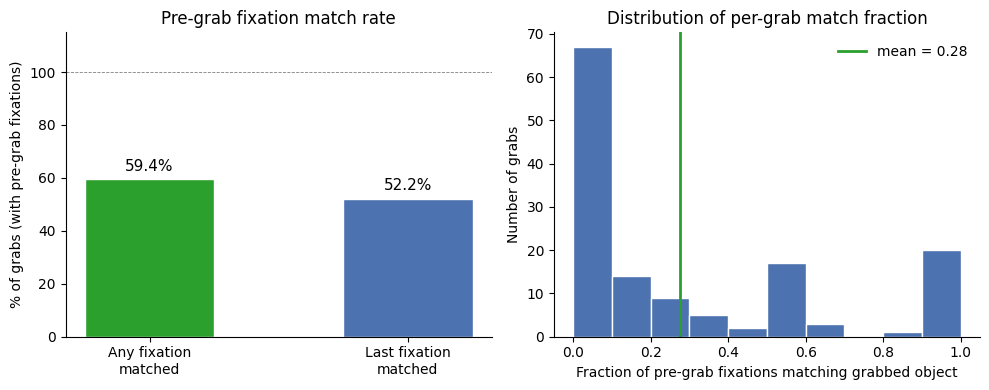

In [55]:
MATCH_COLOR   = "#2ca02c"
NOMATCH_COLOR = "#d62728"

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: any-match vs last-match rate
ax = axes[0]
labels = ["Any fixation\nmatched", "Last fixation\nmatched"]
values = [100 * n_any_match / n_has_fix, 100 * n_last_match / n_has_fix]
bars   = ax.bar(labels, values, color=[MATCH_COLOR, "#4C72B0"], width=0.5, edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=11)
ax.set_ylabel("% of grabs (with pre-grab fixations)")
ax.set_title("Pre-grab fixation match rate")
ax.set_ylim(0, 115)
ax.axhline(y=100, color="grey", linewidth=0.6, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

# Right: distribution of per-grab match fraction
ax = axes[1]
ax.hist(
    has_fix["match_fraction"].dropna(),
    bins=np.linspace(0, 1, 11),
    color="#4C72B0", edgecolor="white"
)
ax.axvline(mean_match_frac, color=MATCH_COLOR, linewidth=2,
           label=f"mean = {mean_match_frac:.2f}")
ax.set_xlabel("Fraction of pre-grab fixations matching grabbed object")
ax.set_ylabel("Number of grabs")
ax.set_title("Distribution of per-grab match fraction")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("match_rate_summary.png", dpi=150, bbox_inches="tight")
plt.show()

### 7b. Timeline plots: fixated objects before each grab (green = match, red = no match)

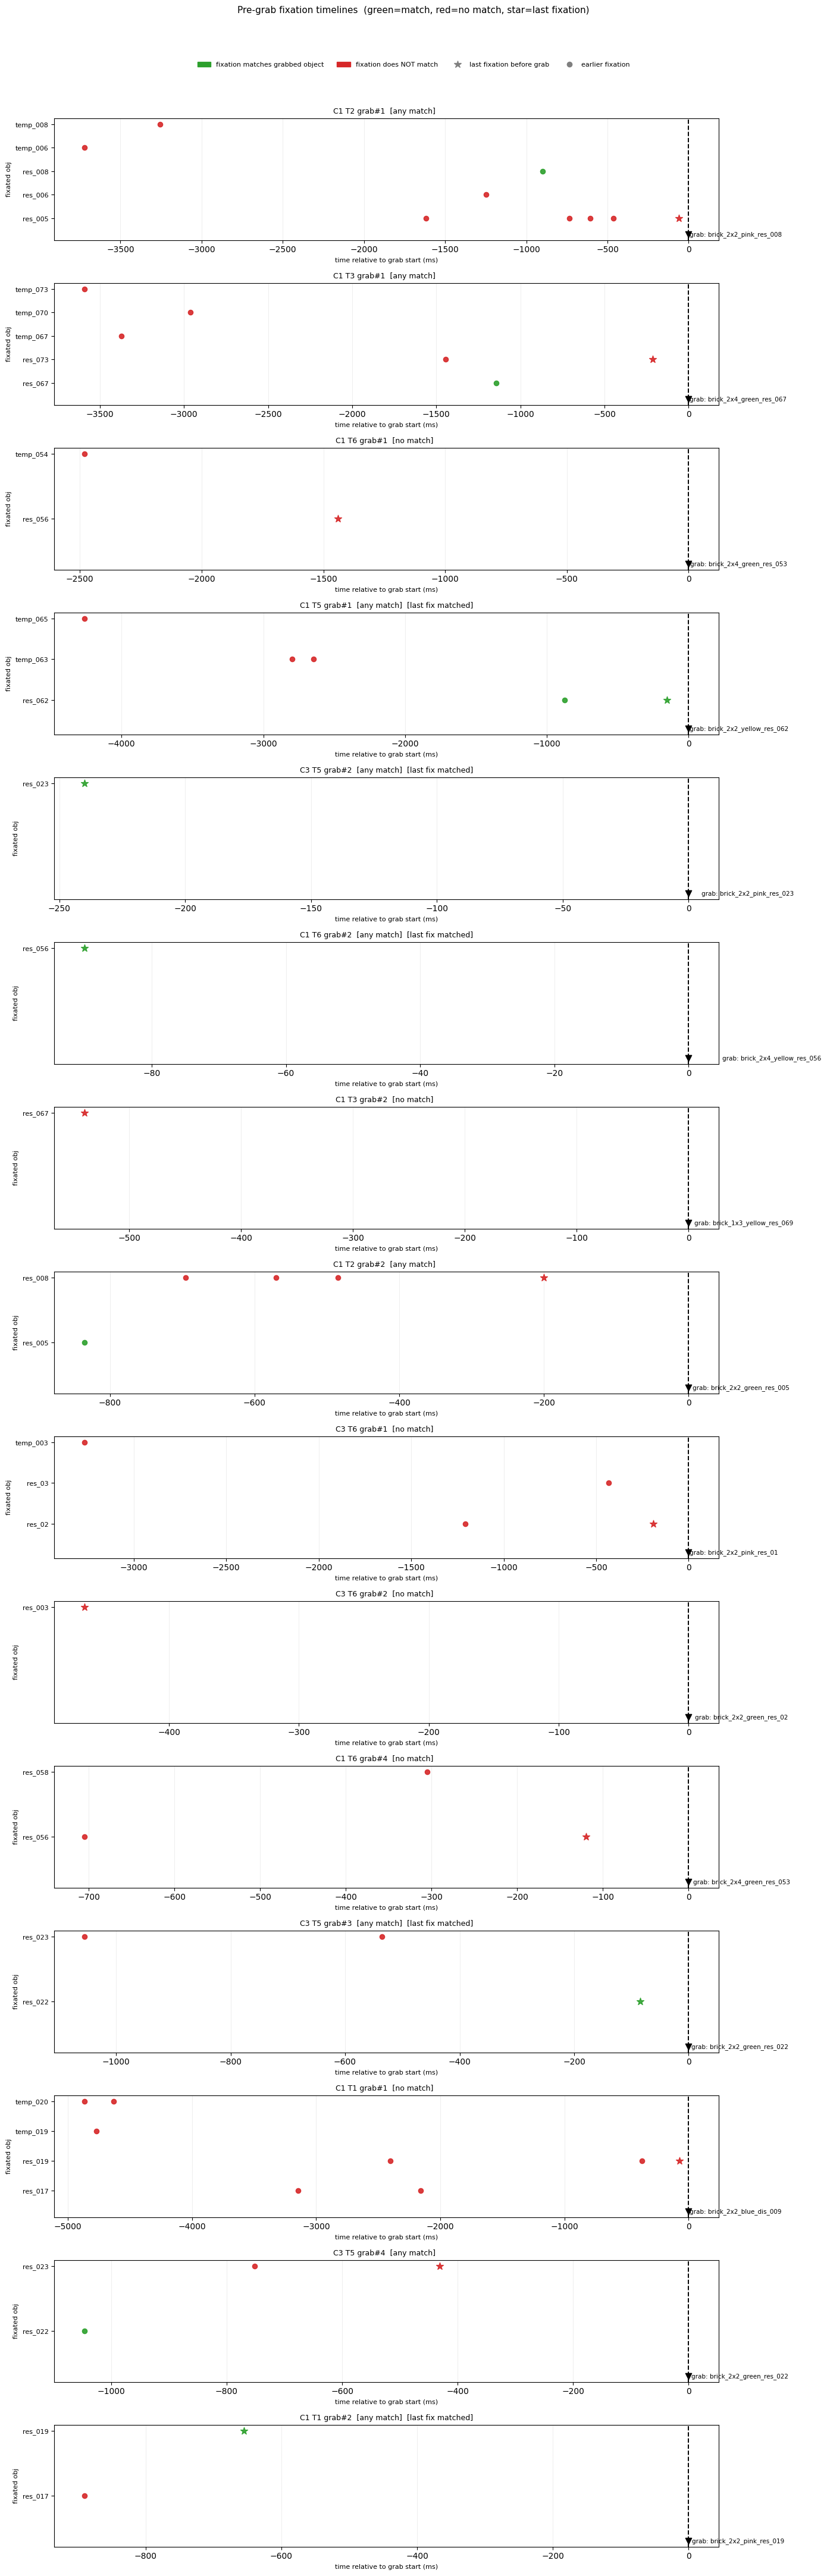

In [56]:
if events_df.empty:
    print("No events to plot.")
else:
    # First 15 grabs that have fixations, in chronological order
    plot_keys = (
        summary[summary["n_fix_total"] > 0]
        .sort_values("grab_start_time_ms")
        .head(15)
        [["participant_id", "condition_number", "trial_number", "grab_idx_in_trial",
          "grabbed_name", "grabbed_group", "any_match", "last_fix_matches"]]
        .reset_index(drop=True)
    )

    n = len(plot_keys)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.8 * n), sharex=False)
    if n == 1: axes = [axes]

    for ax, (_, row) in zip(axes, plot_keys.iterrows()):
        mask = (
            (events_df["participant_id"]    == row["participant_id"]) &
            (events_df["condition_number"]  == row["condition_number"]) &
            (events_df["trial_number"]      == row["trial_number"]) &
            (events_df["grab_idx_in_trial"] == row["grab_idx_in_trial"])
        )
        ev = events_df[mask].copy()
        ev["t_rel_ms"] = ev["fixation_end_time_ms"] - ev["grab_start_time_ms"]

        y_labels = sorted(ev["dominant_group"].dropna().unique())
        y_map    = {name: i for i, name in enumerate(y_labels)}

        for _, fx in ev.iterrows():
            color  = MATCH_COLOR if fx["fixation_matches_grab"] else NOMATCH_COLOR
            marker = "*" if fx["is_last_fixation"] else "o"
            ax.scatter(
                fx["t_rel_ms"], y_map[fx["dominant_group"]],
                color=color, s=80 if marker == "*" else 35,
                marker=marker, zorder=3, alpha=0.9
            )

        ax.axvline(0, color="black", linewidth=1.4, linestyle="--")
        ax.scatter([0], [-0.7], marker="v", color="black", s=55, zorder=4)
        ax.text(5, -0.7, f"grab: {row['grabbed_name']}", fontsize=7.5, va="center")

        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels, fontsize=8)
        ax.set_ylabel("fixated obj", fontsize=8)
        ax.set_xlabel("time relative to grab start (ms)", fontsize=8)
        ax.set_title(
            f"C{int(row['condition_number'])} T{int(row['trial_number'])} "
            f"grab#{int(row['grab_idx_in_trial'])}  "
            f"{'[any match]' if row['any_match'] else '[no match]'}  "
            f"{'[last fix matched]' if row['last_fix_matches'] else ''}",
            fontsize=9
        )
        ax.grid(axis="x", alpha=0.2)

    legend_handles = [
        mpatches.Patch(color=MATCH_COLOR,   label="fixation matches grabbed object"),
        mpatches.Patch(color=NOMATCH_COLOR, label="fixation does NOT match"),
        plt.Line2D([0],[0], marker="*", color="grey", markersize=9,
                   linestyle="none", label="last fixation before grab"),
        plt.Line2D([0],[0], marker="o", color="grey", markersize=6,
                   linestyle="none", label="earlier fixation"),
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=4,
               fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.01))
    fig.suptitle("Pre-grab fixation timelines  (green=match, red=no match, star=last fixation)",
                 fontsize=11, y=1.03)
    plt.tight_layout()
    plt.savefig("fixation_timelines.png", dpi=150, bbox_inches="tight")
    plt.show()

In [57]:
# Pick one late grab and count how many temp fixations exist before it
# (self-contained diagnostic: derives its own filtered grabs + temp fixations
#  so it does not depend on later cells)

# temp fixations = stable fixation runs whose dominant object is a temp_* brick
_diag_temp_fix = all_fix_runs[
    all_fix_runs["stable"] &
    all_fix_runs["dominant_group"].str.startswith("temp_", na=False)
].copy()

# resource/template grabs only (skip dis_*)
def _diag_grabbed_type(name):
    if pd.isna(name): return None
    m = re.search(r"_(res|temp|dis)_\d+$", str(name))
    return m.group(1) if m else None

_diag_grabs = grab_events[
    grab_events["grabbed_name"].apply(_diag_grabbed_type).isin(["res", "temp"])
].copy()

test_grab = _diag_grabs.sort_values("grab_start_time_ms").iloc[20]
print(f"Grab: {test_grab['grabbed_name']}  at {test_grab['grab_start_time_ms']:.0f}ms")
print(f"Trial: C{test_grab['condition_number']} T{test_grab['trial_number']}")

prior = _diag_temp_fix[
    (_diag_temp_fix["participant_id"]   == test_grab["participant_id"]) &
    (_diag_temp_fix["condition_number"] == test_grab["condition_number"]) &
    (_diag_temp_fix["trial_number"]     == test_grab["trial_number"]) &
    (_diag_temp_fix["end_time_ms"]      <= test_grab["grab_start_time_ms"])
]
print(f"Prior temp fixations in same trial: {len(prior)}")
print(prior[["dominant_group", "start_time_ms", "end_time_ms", "duration_ms"]])


Grab: brick_2x2_pink_res_019  at 9199ms
Trial: C1 T1
Prior temp fixations in same trial: 3
  dominant_group  start_time_ms  end_time_ms  duration_ms
6       temp_020      2376.3152    2956.3819     580.0667
7       temp_019      2981.3849    3051.3988      70.0139
8       temp_020      3101.3997    3191.4131      90.0134


In [58]:
print("All temp fixations in C1 T1:")
trial_temp = all_temp_fixations[
    (all_temp_fixations["participant_id"]   == "001") &
    (all_temp_fixations["condition_number"] == 1) &
    (all_temp_fixations["trial_number"]     == 1)
]
print(f"Total: {len(trial_temp)}")
print(trial_temp[["dominant_group", "start_time_ms", "end_time_ms"]].to_string(index=False))

print("\nTrial time range:")
trial_data = prepared[
    (prepared["participant_id"]   == "001") &
    (prepared["condition_number"] == 1) &
    (prepared["trial_number"]     == 1)
]
print(f"Start: {trial_data['time_ms'].min():.0f}ms")
print(f"End:   {trial_data['time_ms'].max():.0f}ms")
print(f"Duration: {(trial_data['time_ms'].max() - trial_data['time_ms'].min())/1000:.1f}s")

All temp fixations in C1 T1:
Total: 6
dominant_group  start_time_ms  end_time_ms
      temp_020      2376.3152    2956.3819
      temp_019      2981.3849    3051.3988
      temp_020      3101.3997    3191.4131
      temp_018     11444.4755   11514.4810
      temp_020     11574.4906   11729.5098
      temp_019     33198.2747   33303.2835

Trial time range:
Start: 0ms
End:   35655ms
Duration: 35.7s


In [59]:
all_temp_fixations = all_fix_runs[
    all_fix_runs["stable"] & 
    all_fix_runs["dominant_group"].str.startswith("temp_", na=False)
].copy()

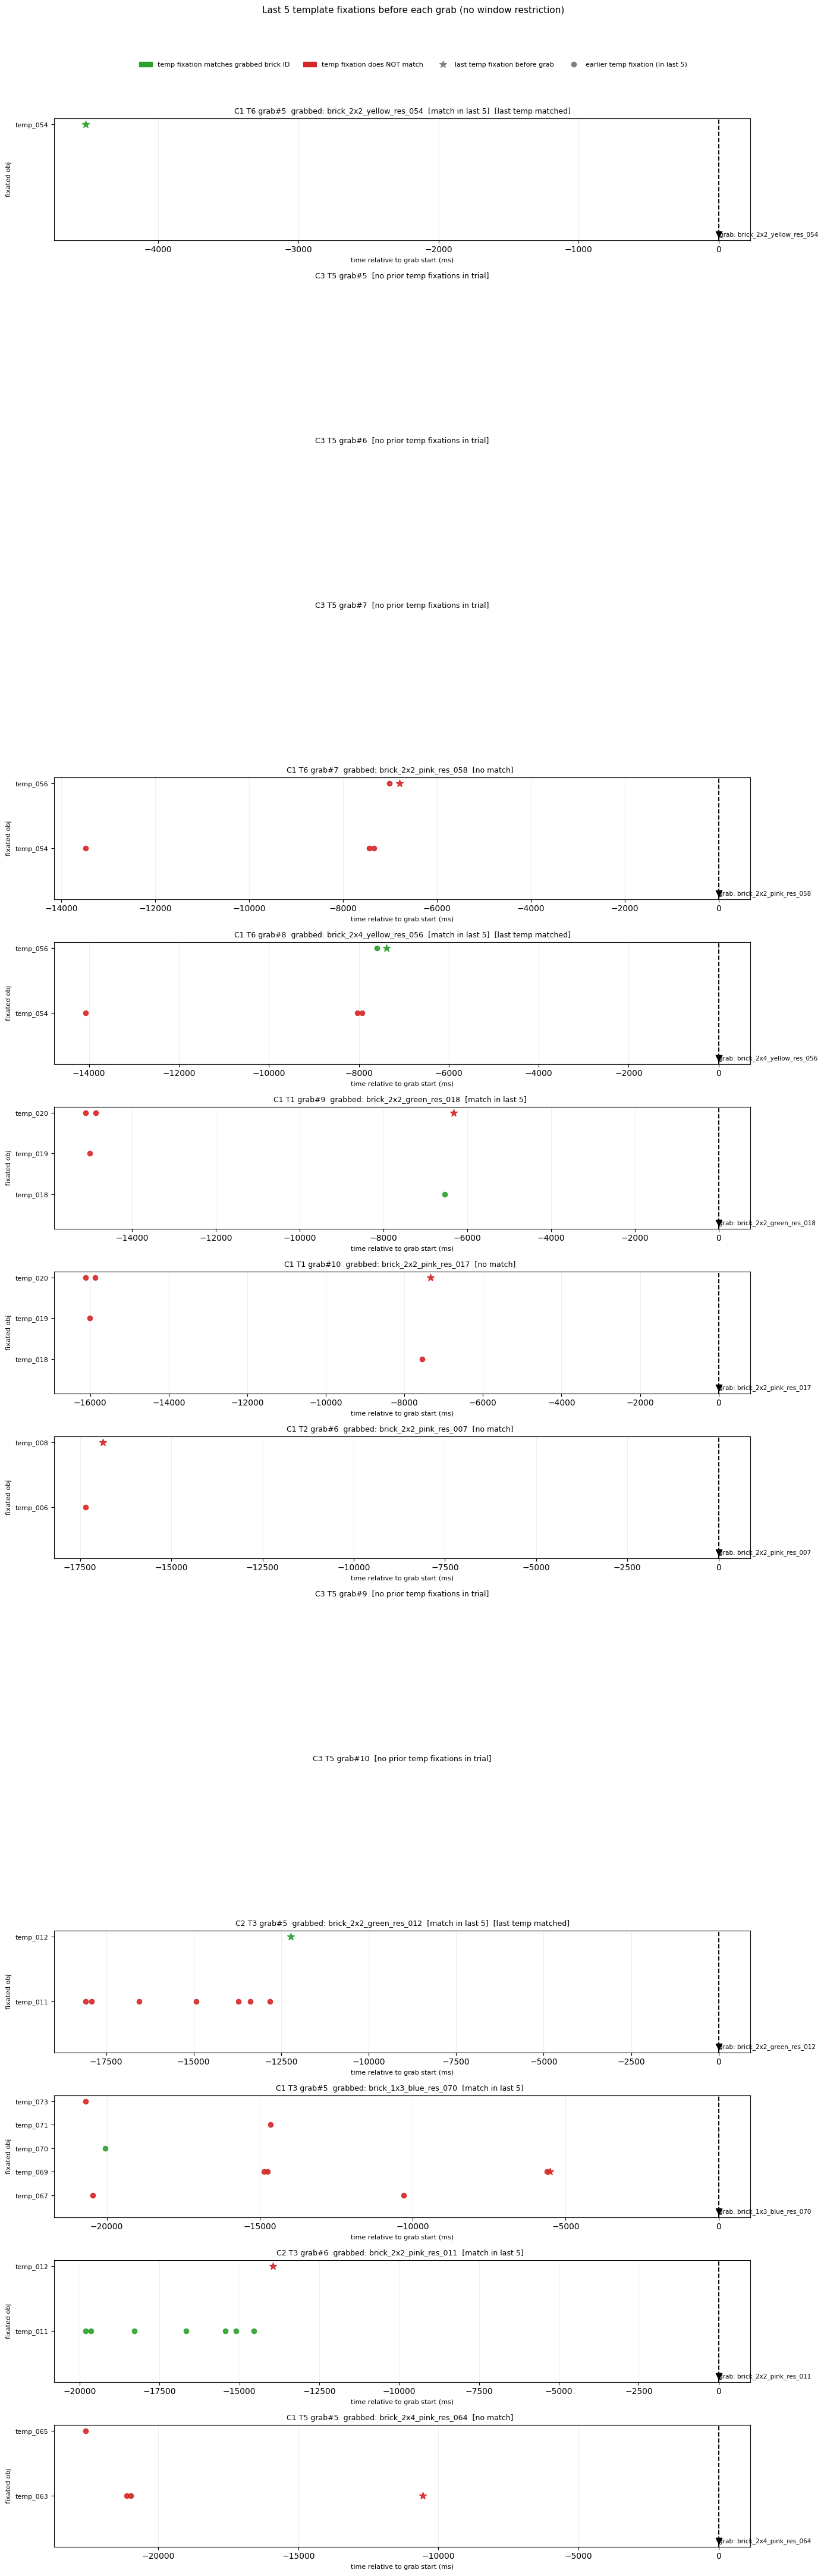

In [60]:
if grab_events_filtered.empty:
    print("No grabs to plot.")
else:
    plot_keys = (
        grab_events_filtered[grab_events_filtered["grab_idx_in_trial"] >= 5]
        .sort_values("grab_start_time_ms")
        .head(15)
        .reset_index(drop=True)
    )
    n = len(plot_keys)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.8 * n), sharex=False)
    if n == 1: axes = [axes]
    for ax, (_, row) in zip(axes, plot_keys.iterrows()):
        pid      = row["participant_id"]
        cond     = row["condition_number"]
        trial    = row["trial_number"]
        grab_t   = row["grab_start_time_ms"]
        brick_id = row["grabbed_brick_id"]           # e.g. "068"
        target   = f"temp_{brick_id}"                # e.g. "temp_068"
        # All temp fixations in this trial before this grab — no window limit
        prior_temp = all_temp_fixations[
            (all_temp_fixations["participant_id"]   == pid) &
            (all_temp_fixations["condition_number"] == cond) &
            (all_temp_fixations["trial_number"]     == trial) &
            (all_temp_fixations["end_time_ms"]      <= grab_t)
        ].sort_values("end_time_ms", ascending=False)
        last5 = prior_temp.head(25).copy()
        if last5.empty:
            ax.set_title(
                f"C{int(cond)} T{int(trial)} grab#{int(row['grab_idx_in_trial'])}  "
                f"[no prior temp fixations in trial]",
                fontsize=9
            )
            ax.axis("off")
            continue
        last5["t_rel_ms"]             = last5["end_time_ms"] - grab_t
        last5["fixation_matches_grab"] = last5["dominant_group"] == target
        last5["is_last_temp_fixation"] = last5["end_time_ms"] == last5["end_time_ms"].max()
        any_match  = last5["fixation_matches_grab"].any()
        last_match = last5.loc[last5["is_last_temp_fixation"], "fixation_matches_grab"].any()
        y_labels = sorted(last5["dominant_group"].dropna().unique())
        y_map    = {name: i for i, name in enumerate(y_labels)}
        for _, fx in last5.iterrows():
            color  = MATCH_COLOR if fx["fixation_matches_grab"] else NOMATCH_COLOR
            marker = "*" if fx["is_last_temp_fixation"] else "o"
            ax.scatter(
                fx["t_rel_ms"], y_map[fx["dominant_group"]],
                color=color, s=80 if marker == "*" else 35,
                marker=marker, zorder=3, alpha=0.9
            )
        ax.axvline(0, color="black", linewidth=1.4, linestyle="--")
        ax.scatter([0], [-0.7], marker="v", color="black", s=55, zorder=4)
        ax.text(5, -0.7, f"grab: {row['grabbed_name']}", fontsize=7.5, va="center")
        ax.set_yticks(range(len(y_labels)))
        ax.set_yticklabels(y_labels, fontsize=8)
        ax.set_ylabel("fixated obj", fontsize=8)
        ax.set_xlabel("time relative to grab start (ms)", fontsize=8)
        ax.set_title(
            f"C{int(cond)} T{int(trial)} grab#{int(row['grab_idx_in_trial'])}  "
            f"grabbed: {row['grabbed_name']}  "
            f"{'[match in last 5]' if any_match else '[no match]'}  "
            f"{'[last temp matched]' if last_match else ''}",
            fontsize=9
        )
        ax.grid(axis="x", alpha=0.2)
    legend_handles = [
        mpatches.Patch(color=MATCH_COLOR,   label="temp fixation matches grabbed brick ID"),
        mpatches.Patch(color=NOMATCH_COLOR, label="temp fixation does NOT match"),
        plt.Line2D([0],[0], marker="*", color="grey", markersize=9,
                   linestyle="none", label="last temp fixation before grab"),
        plt.Line2D([0],[0], marker="o", color="grey", markersize=6,
                   linestyle="none", label="earlier temp fixation (in last 5)"),
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=4,
               fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.01))
    fig.suptitle("Last 5 template fixations before each grab (no window restriction)",
                 fontsize=11, y=1.03)
    plt.tight_layout()
    plt.savefig("last5_temp_fixations_per_grab.png", dpi=150, bbox_inches="tight")
    plt.show()

In [61]:
# ── CELL 1: Build last-5 template fixation match ─────────────────────────────
#
# For each resource grab of res_XXX:
#   - find the last 5 fixations where a temp_* brick was dominant, before grab start
#   - check whether temp_XXX is among those 5
#
# dis_* grabs are skipped entirely.

def extract_brick_id(group_str):
    """res_068 -> '068',  temp_068 -> '068',  anything else -> None"""
    if pd.isna(group_str): return None
    m = re.match(r"^(res|temp)_(\d+)$", str(group_str))
    return m.group(2) if m else None


# Only temp_* fixation candidates (stable, >=50ms, dominant group is temp_*)
temp_fixations = fixation_candidates[
    fixation_candidates["fixation_group_type"] == "temp"
].copy()

# Only grabs of res_* or temp_* bricks (skip dis_*)
def grabbed_type(name):
    if pd.isna(name): return None
    m = re.search(r"_(res|temp|dis)_\d+$", str(name))
    return m.group(1) if m else None

grab_events_filtered = grab_events[
    grab_events["grabbed_name"].apply(grabbed_type).isin(["res", "temp"])
].copy()
grab_events_filtered["grabbed_group"] = grab_events_filtered["grabbed_name"].apply(group_from_grabbed_name)
grab_events_filtered["grabbed_brick_id"] = grab_events_filtered["grabbed_group"].apply(extract_brick_id)

print(f"Total resource grabs (res+temp only, dis skipped): {len(grab_events_filtered)}")
print(f"Total stable temp_* fixation candidates:           {len(temp_fixations)}")


Total resource grabs (res+temp only, dis skipped): 159
Total stable temp_* fixation candidates:           1007


In [62]:

# ── CELL 2: Core matching loop ────────────────────────────────────────────────

N_LAST = 5   # how many last template fixations to look back

results = []

for _, grab in grab_events_filtered.iterrows():
    pid   = grab["participant_id"]
    cond  = grab["condition_number"]
    trial = grab["trial_number"]
    t     = grab["grab_start_time_ms"]
    brick_id = grab["grabbed_brick_id"]          # e.g. "068"
    target_temp_group = f"temp_{brick_id}"       # e.g. "temp_068"

    # All temp fixations in this trial that ended BEFORE this grab
    trial_temp_fix = temp_fixations[
        (temp_fixations["participant_id"]   == pid)  &
        (temp_fixations["condition_number"] == cond) &
        (temp_fixations["trial_number"]     == trial) &
        (temp_fixations["end_time_ms"]      <= t)
    ].sort_values("end_time_ms", ascending=False)   # most recent first

    last_n = trial_temp_fix.head(N_LAST)
    n_available = len(last_n)

    # Which temp bricks were in those last N fixations?
    consulted_groups = last_n["dominant_group"].tolist()
    consulted_ids    = [extract_brick_id(g) for g in consulted_groups]

    matched = (brick_id is not None) and (brick_id in consulted_ids)

    # How many fixations back was the matching one (1 = most recent)?
    rank = None
    if matched:
        for i, cid in enumerate(consulted_ids):
            if cid == brick_id:
                rank = i + 1
                break

    # Time since last template consultation of this specific brick
    matching_rows = last_n[last_n["dominant_group"] == target_temp_group]
    if not matching_rows.empty:
        lag_ms = t - matching_rows.iloc[0]["end_time_ms"]
    else:
        # Check further back (not in last N, but did they ever look at it in this trial?)
        all_prior = trial_temp_fix[trial_temp_fix["dominant_group"] == target_temp_group]
        lag_ms = (t - all_prior.iloc[0]["end_time_ms"]) if not all_prior.empty else np.nan

    results.append({
        "participant_id":        pid,
        "condition_number":      cond,
        "trial_number":          trial,
        "grab_idx_in_trial":     grab["grab_idx_in_trial"],
        "hand":                  grab["hand"],
        "grabbed_name":          grab["grabbed_name"],
        "grabbed_group":         grab["grabbed_group"],
        "grabbed_brick_id":      brick_id,
        "target_temp_group":     target_temp_group,
        "grab_start_time_ms":    t,
        "n_temp_fix_available":  n_available,        # how many temp fixations existed before this grab
        "last_5_temp_groups":    consulted_groups,   # list of the up-to-5 groups
        "last_5_temp_ids":       consulted_ids,      # list of IDs e.g. ['068','031','012',...]
        "temp_match_in_last_5":  matched,            # KEY COLUMN: True/False
        "match_rank":            rank,               # which position (1=most recent)
        "lag_to_last_temp_ms":   lag_ms,             # ms since they last looked at temp_XXX
    })

last5_df = pd.DataFrame(results)
print(f"\nTotal grabs analyzed: {len(last5_df)}")
print(f"Match (temp_XXX in last 5 temp fixations): {last5_df['temp_match_in_last_5'].sum()}  "
      f"({100 * last5_df['temp_match_in_last_5'].mean():.1f}%)")
last5_df.head(10)



Total grabs analyzed: 159
Match (temp_XXX in last 5 temp fixations): 63  (39.6%)


,participant_id,condition_number,trial_number,grab_idx_in_trial,hand,grabbed_name,grabbed_group,grabbed_brick_id,target_temp_group,grab_start_time_ms,n_temp_fix_available,last_5_temp_groups,last_5_temp_ids,temp_match_in_last_5,match_rank,lag_to_last_temp_ms
0,001,1,1,2,Right,brick_2x2_pink_res_019,res_019,019,temp_019,9199.1880,3,"[temp_020, temp_019, temp_020]","[020, 019, 020]",True,2.0,6147.7892
1,001,1,1,3,Left,brick_2x2_green_res_020,res_020,020,temp_020,9699.2499,3,"[temp_020, temp_019, temp_020]","[020, 019, 020]",True,1.0,6507.8368
2,001,1,1,9,Right,brick_2x2_green_res_018,res_018,018,temp_018,18057.3225,5,"[temp_020, temp_018, temp_020, temp_019, temp_020]","[020, 018, 020, 019, 020]",True,2.0,6542.8415
3,001,1,1,10,Left,brick_2x2_pink_res_017,res_017,017,temp_017,19067.4513,5,"[temp_020, temp_018, temp_020, temp_019, temp_020]","[020, 018, 020, 019, 020]",False,NaN,NaN
4,001,1,2,1,Left,brick_2x2_pink_res_008,res_008,008,temp_008,5567.7146,2,"[temp_008, temp_006]","[008, 006]",True,1.0,3256.4202
5,001,1,2,2,Right,brick_2x2_green_res_005,res_005,005,temp_005,6597.8477,2,"[temp_008, temp_006]","[008, 006]",False,NaN,NaN
6,001,1,2,3,Right,brick_2x2_green_res_006,res_006,006,temp_006,15866.0429,2,"[temp_008, temp_006]","[008, 006]",True,2.0,14019.8081
7,001,1,2,6,Left,brick_2x2_pink_res_007,res_007,007,temp_007,19187.4701,2,"[temp_008, temp_006]","[008, 006]",False,NaN,NaN
8,001,1,3,1,Right,brick_2x4_green_res_067,res_067,067,temp_067,5677.7260,3,"[temp_070, temp_067, temp_073]","[070, 067, 073]",True,2.0,3371.4266
9,001,1,3,2,Left,brick_1x3_yellow_res_069,res_069,069,temp_069,6302.8134,3,"[temp_070, temp_067, temp_073]","[070, 067, 073]",False,NaN,NaN


In [63]:
# ── CELL 3: Summary stats per condition ──────────────────────────────────────

# Only grabs where at least 1 temp fixation existed before (otherwise trivially no-match)
has_temp = last5_df[last5_df["n_temp_fix_available"] > 0].copy()

cond_summary = (
    has_temp
    .groupby("condition_number")
    .agg(
        n_grabs          = ("grabbed_name",           "count"),
        n_match          = ("temp_match_in_last_5",   "sum"),
        match_rate       = ("temp_match_in_last_5",   "mean"),
        mean_lag_ms      = ("lag_to_last_temp_ms",    "mean"),
        median_lag_ms    = ("lag_to_last_temp_ms",    "median"),
    )
    .round(3)
    .reset_index()
)
cond_summary["match_pct"] = (cond_summary["match_rate"] * 100).round(1)

print("\nPer-condition summary (grabs with >=1 prior temp fixation):")
print(cond_summary.to_string(index=False))



Per-condition summary (grabs with >=1 prior temp fixation):
 condition_number  n_grabs  n_match  match_rate  mean_lag_ms  median_lag_ms  match_pct
                1       48       21       0.438    13462.631       7965.524       43.8
                2       60       25       0.417    21111.595      16246.088       41.7
                3       42       17       0.405    17131.788      15656.014       40.5


In [64]:
# ── SETUP: temp fixations and resource grabs ──────────────────────────────────

# All stable fixations where dominant object is a temp_* brick
all_temp_fixations = all_fix_runs[
    all_fix_runs["stable"] &
    all_fix_runs["dominant_group"].str.startswith("temp_", na=False)
].copy()

# Resource grabs, res_* only (skip dis_*)
res_grabs = grab_events[
    grab_events["grabbed_name"].apply(
        lambda x: bool(re.search(r"_res_\d+$", str(x)))
    )
].copy()
res_grabs["grabbed_id"] = res_grabs["grabbed_name"].apply(
    lambda x: re.search(r"_res_(\d+)$", str(x)).group(1)
)

print(f"Temp fixation runs:  {len(all_temp_fixations)}")
print(f"Resource grabs:      {len(res_grabs)}")


# ── ANALYSIS 1: Last temp fixation before each grab ───────────────────────────

last_temp_results = []

for _, grab in res_grabs.iterrows():
    pid, cond, trial = grab["participant_id"], grab["condition_number"], grab["trial_number"]
    grab_t    = grab["grab_start_time_ms"]
    target_id = grab["grabbed_id"]           # e.g. "068"
    target    = f"temp_{target_id}"          # e.g. "temp_068"

    # All temp fixations in this trial that ended before this grab
    prior = all_temp_fixations[
        (all_temp_fixations["participant_id"]   == pid)  &
        (all_temp_fixations["condition_number"] == cond) &
        (all_temp_fixations["trial_number"]     == trial) &
        (all_temp_fixations["end_time_ms"]      <  grab_t)
    ].sort_values("end_time_ms", ascending=False)

    if prior.empty:
        last_temp_results.append({
            "participant_id":      pid,
            "condition_number":    cond,
            "trial_number":        trial,
            "grab_idx_in_trial":   grab["grab_idx_in_trial"],
            "grabbed_name":        grab["grabbed_name"],
            "grabbed_id":          target_id,
            "target_temp":         target,
            "grab_start_time_ms":  grab_t,
            "last_temp_group":     None,
            "last_temp_end_ms":    None,
            "lag_ms":              None,
            "last_temp_matches":   False,
            "had_any_temp_fix":    False,
        })
        continue

    last = prior.iloc[0]
    last_temp_results.append({
        "participant_id":      pid,
        "condition_number":    cond,
        "trial_number":        trial,
        "grab_idx_in_trial":   grab["grab_idx_in_trial"],
        "grabbed_name":        grab["grabbed_name"],
        "grabbed_id":          target_id,
        "target_temp":         target,
        "grab_start_time_ms":  grab_t,
        "last_temp_group":     last["dominant_group"],
        "last_temp_end_ms":    last["end_time_ms"],
        "lag_ms":              grab_t - last["end_time_ms"],
        "last_temp_matches":   last["dominant_group"] == target,
        "had_any_temp_fix":    True,
    })

last_temp_df = pd.DataFrame(last_temp_results)

# Summary
has_prior = last_temp_df[last_temp_df["had_any_temp_fix"]]
n_total   = len(last_temp_df)
n_prior   = len(has_prior)
n_match   = has_prior["last_temp_matches"].sum()

print("\n── ANALYSIS 1: Last temp fixation match ──────────────────────────")
print(f"Total res grabs:                        {n_total}")
print(f"Grabs with at least 1 prior temp fix:   {n_prior}")
print(f"Last temp fixation matched grabbed obj: {n_match} / {n_prior}  ({100*n_match/n_prior:.1f}%)")
print()
print("Per condition:")
print(
    has_prior.groupby("condition_number")["last_temp_matches"]
    .agg(n_grabs="count", n_match="sum", match_rate="mean")
    .assign(match_pct=lambda x: (x["match_rate"]*100).round(1))
    .drop(columns="match_rate")
)


# ── ANALYSIS 2: Match in last 5 temp fixations ────────────────────────────────

N = 5
last5_results = []

for _, grab in res_grabs.iterrows():
    pid, cond, trial = grab["participant_id"], grab["condition_number"], grab["trial_number"]
    grab_t    = grab["grab_start_time_ms"]
    target_id = grab["grabbed_id"]
    target    = f"temp_{target_id}"

    prior = all_temp_fixations[
        (all_temp_fixations["participant_id"]   == pid)  &
        (all_temp_fixations["condition_number"] == cond) &
        (all_temp_fixations["trial_number"]     == trial) &
        (all_temp_fixations["end_time_ms"]      <  grab_t)
    ].sort_values("end_time_ms", ascending=False)

    last_n   = prior.head(N)
    n_avail  = len(last_n)
    ids_seen = [re.search(r"^temp_(\d+)$", str(g)).group(1)
                for g in last_n["dominant_group"] if re.search(r"^temp_(\d+)$", str(g))]
    matched  = target_id in ids_seen
    rank     = (ids_seen.index(target_id) + 1) if matched else None

    last5_results.append({
        "participant_id":      pid,
        "condition_number":    cond,
        "trial_number":        trial,
        "grab_idx_in_trial":   grab["grab_idx_in_trial"],
        "grabbed_name":        grab["grabbed_name"],
        "grabbed_id":          target_id,
        "target_temp":         target,
        "grab_start_time_ms":  grab_t,
        "n_temp_fix_available": n_avail,
        "last5_temp_groups":   last_n["dominant_group"].tolist(),
        "match_in_last5":      matched,
        "match_rank":          rank,       # 1 = most recent, 5 = oldest
    })

last5_df = pd.DataFrame(last5_results)

# Summary
has_prior5 = last5_df[last5_df["n_temp_fix_available"] > 0]
n5_total   = len(last5_df)
n5_prior   = len(has_prior5)
n5_match   = has_prior5["match_in_last5"].sum()

print("\n── ANALYSIS 2: Match in last 5 temp fixations ────────────────────")
print(f"Total res grabs:                          {n5_total}")
print(f"Grabs with at least 1 prior temp fix:     {n5_prior}")
print(f"Target in last 5 temp fixations:          {n5_match} / {n5_prior}  ({100*n5_match/n5_prior:.1f}%)")
print()
print("Per condition:")
print(
    has_prior5.groupby("condition_number")["match_in_last5"]
    .agg(n_grabs="count", n_match="sum", match_rate="mean")
    .assign(match_pct=lambda x: (x["match_rate"]*100).round(1))
    .drop(columns="match_rate")
)
print()
print("Match rank distribution (1=most recent):")
print(last5_df["match_rank"].value_counts().sort_index())

Temp fixation runs:  1007
Resource grabs:      159

── ANALYSIS 1: Last temp fixation match ──────────────────────────
Total res grabs:                        159
Grabs with at least 1 prior temp fix:   150
Last temp fixation matched grabbed obj: 25 / 150  (16.7%)

Per condition:
                  n_grabs  n_match  match_pct
condition_number                             
1                      48       11       22.9
2                      60        7       11.7
3                      42        7       16.7

── ANALYSIS 2: Match in last 5 temp fixations ────────────────────
Total res grabs:                          159
Grabs with at least 1 prior temp fix:     150
Target in last 5 temp fixations:          63 / 150  (42.0%)

Per condition:
                  n_grabs  n_match  match_pct
condition_number                             
1                      48       21       43.8
2                      60       25       41.7
3                      42       17       40.5

Match rank distributio

In [65]:
# Which grabs had no prior temp fixations at all?
no_temp = last5_df[last5_df["n_temp_fix_available"] == 0].copy()

print(f"Grabs with no prior temp fixations: {len(no_temp)}")
print()
print(no_temp[[
    "participant_id", "condition_number", "trial_number",
    "grab_idx_in_trial", "grabbed_name", "grab_start_time_ms"
]].to_string(index=False))

Grabs with no prior temp fixations: 9

participant_id  condition_number  trial_number  grab_idx_in_trial            grabbed_name  grab_start_time_ms
           001                 3             5                  1  brick_2x2_pink_res_023           5817.7764
           001                 3             5                  2  brick_2x2_pink_res_023           6152.7923
           001                 3             5                  3 brick_2x2_green_res_022           7342.9508
           001                 3             5                  4 brick_2x2_green_res_022           8524.1056
           001                 3             5                  5  brick_2x2_pink_res_023           8549.1083
           001                 3             5                  6 brick_2x2_green_res_022           9019.1602
           001                 3             5                  7  brick_2x2_pink_res_023           9019.1602
           001                 3             5                  9 brick_2x2_green

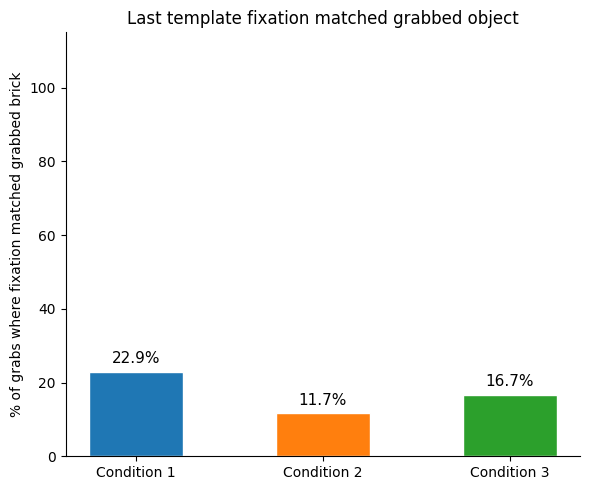

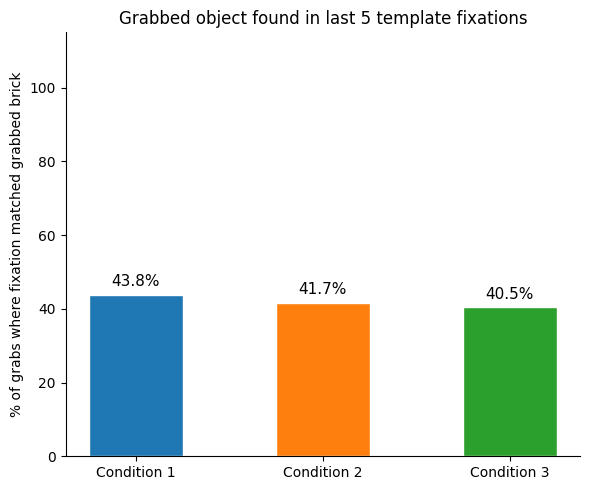

In [66]:
# ── FIGURE 1: Last temp fixation match rate per condition ─────────────────────

# Define the condition list and a color palette (these were previously undefined)
conditions = sorted(
    set(has_prior["condition_number"].dropna().unique())
    | set(has_prior5["condition_number"].dropna().unique())
)
colors = plt.cm.tab10.colors  # 10 distinct colors; indexed below

fig, ax = plt.subplots(figsize=(6, 5))
match_rates_1 = [
    has_prior[has_prior["condition_number"] == c]["last_temp_matches"].mean() * 100
    for c in conditions
]
bars = ax.bar([f"Condition {int(c)}" for c in conditions], match_rates_1,
              color=colors[:len(conditions)], edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=11)
ax.set_ylabel("% of grabs where fixation matched grabbed brick")
ax.set_title("Last template fixation matched grabbed object")
ax.set_ylim(0, 115)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("plot1_last_fix_match.png", dpi=150, bbox_inches="tight")
plt.show()


# ── FIGURE 2: Last-5 temp fix match rate per condition ───────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
match_rates_5 = [
    has_prior5[has_prior5["condition_number"] == c]["match_in_last5"].mean() * 100
    for c in conditions
]
bars = ax.bar([f"Condition {int(c)}" for c in conditions], match_rates_5,
              color=colors[:len(conditions)], edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=11)
ax.set_ylabel("% of grabs where fixation matched grabbed brick")
ax.set_title("Grabbed object found in last 5 template fixations")
ax.set_ylim(0, 115)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("plot2_last5_match.png", dpi=150, bbox_inches="tight")
plt.show()


In [67]:
print(f"grab_events (raw from detect_grab_events): {len(grab_events)}")
print(f"grab_events_filtered (res+temp only, dis skipped): {len(grab_events_filtered)}")
print()
print("grabbed types in grab_events:")
grab_events["grabbed_name"].apply(grabbed_type).value_counts()

grab_events (raw from detect_grab_events): 174
grab_events_filtered (res+temp only, dis skipped): 159

grabbed types in grab_events:


grabbed_name
res    159
dis     15
Name: count, dtype: int64

In [68]:
print(len(grab_events[grab_events["grabbed_name"].apply(grabbed_type).isin(["res", "temp"])]))

# Also check if grab_events_filtered was accidentally recomputed somewhere
# with an old version of grab_events (before the foot area fix)
print(grab_events_filtered["grabbed_name"].apply(grabbed_type).value_counts())
print(grab_events_filtered[["condition_number", "trial_number"]].value_counts().sort_index())

159
grabbed_name
res    159
Name: count, dtype: int64
condition_number  trial_number
1                 1                4
                  2                4
                  3               11
                  4               11
                  5                8
                  6               10
2                 1                9
                  2               19
                  3                5
                  4               10
                  5               13
                  6                4
3                 1                9
                  2               10
                  3                7
                  4               12
                  5                9
                  6                4
Name: count, dtype: int64


In [69]:
!pip install scikit-learn

You should consider upgrading via the 'C:\Users\LENOVO\PycharmProjects\pythonProject\venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [70]:
from sklearn.cluster import KMeans

In [71]:
# ── Separate the three ROIs directly from the three fixation-type clusters ──

pos_x, pos_z = "object_position_x", "object_position_z"
df = prepared.dropna(subset=[pos_x, pos_z])

is_temp = df["hit_obj_name"].str.contains("temp", case=False, na=False)
is_res  = df["hit_obj_name"].str.contains(r"_res_\d+$", na=False, regex=True)

# "working" = res_* fixations that are NOT on the resource desk cluster.
# Use KMeans (2 clusters) on res_* points to split them into "resource desk" vs "working area"
from sklearn.cluster import KMeans

res_pts = df.loc[is_res, [pos_x, pos_z]].dropna()
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(res_pts)
res_pts = res_pts.copy()
res_pts["cluster"] = km.labels_

# the cluster with smaller z (more negative) is the tilted resource desk;
# the one near z=0 is the working area
cluster_z_means = res_pts.groupby("cluster")[pos_z].mean()
resource_cluster_id = cluster_z_means.idxmin()
working_cluster_id  = cluster_z_means.idxmax()

resource_pts = res_pts[res_pts["cluster"] == resource_cluster_id][[pos_x, pos_z]]
working_pts  = res_pts[res_pts["cluster"] == working_cluster_id][[pos_x, pos_z]]
model_pts    = df.loc[is_temp, [pos_x, pos_z]].dropna()

print(f"model    n={len(model_pts)}")
print(f"resource n={len(resource_pts)}")
print(f"working  n={len(working_pts)}")


def fit_axis_aligned_bbox(pts, q_low=0.01, q_high=0.99, margin=0.1):
    x_lo, x_hi = pts[pos_x].quantile([q_low, q_high])
    z_lo, z_hi = pts[pos_z].quantile([q_low, q_high])
    return {"type": "aligned", "x_min": x_lo-margin, "x_max": x_hi+margin,
            "z_min": z_lo-margin, "z_max": z_hi+margin, "n_points": len(pts)}

def fit_rotated_bbox(pts, q_low=0.01, q_high=0.99, margin=0.1):
    xy = pts.to_numpy()
    center = xy.mean(axis=0)
    centered = xy - center
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    rotated = centered @ vt.T
    u_lo, u_hi = np.quantile(rotated[:, 0], [q_low, q_high])
    v_lo, v_hi = np.quantile(rotated[:, 1], [q_low, q_high])
    return {"type": "rotated", "center": center, "axes": vt,
            "u_min": u_lo-margin, "u_max": u_hi+margin,
            "v_min": v_lo-margin, "v_max": v_hi+margin, "n_points": len(pts)}

def point_in_rotated_bbox(x, z, bb):
    centered = np.array([x, z]) - bb["center"]
    u, v = bb["axes"] @ centered
    return bb["u_min"] <= u <= bb["u_max"] and bb["v_min"] <= v <= bb["v_max"]

def point_in_aligned_bbox(x, z, bb):
    return bb["x_min"] <= x <= bb["x_max"] and bb["z_min"] <= z <= bb["z_max"]


zone_bboxes = {
    "model":    fit_axis_aligned_bbox(model_pts),
    "resource": fit_rotated_bbox(resource_pts),   # tilted desk
    "working":  fit_axis_aligned_bbox(working_pts),
}

def classify_zone(x, z, bboxes):
    if point_in_aligned_bbox(x, z, bboxes["model"]):
        return "model"
    if point_in_rotated_bbox(x, z, bboxes["resource"]):
        return "resource"
    if point_in_aligned_bbox(x, z, bboxes["working"]):
        return "working"
    return "unknown"

model    n=83457
resource n=32382
working  n=125454


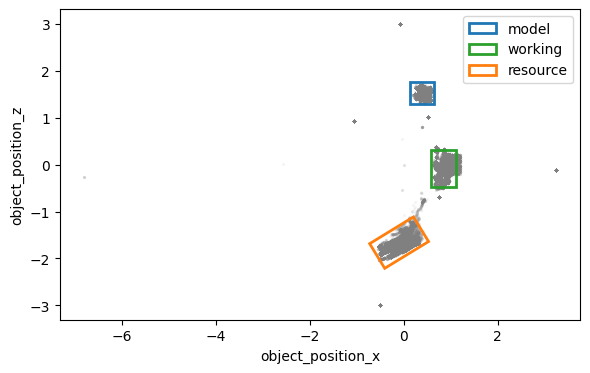

In [72]:
# sanity plot
fig, ax = plt.subplots(figsize=(6, 6))
sample = df
ax.scatter(sample[pos_x], sample[pos_z], s=2, alpha=0.05, color="grey")

for zone, color in [("model", "#1f77b4"), ("working", "#2ca02c")]:
    bb = zone_bboxes[zone]
    rect = mpatches.Rectangle((bb["x_min"], bb["z_min"]), bb["x_max"]-bb["x_min"], bb["z_max"]-bb["z_min"],
                               fill=False, edgecolor=color, linewidth=2, label=zone)
    ax.add_patch(rect)

bb = zone_bboxes["resource"]
corners_uv = np.array([[bb["u_min"], bb["v_min"]], [bb["u_max"], bb["v_min"]],
                       [bb["u_max"], bb["v_max"]], [bb["u_min"], bb["v_max"]]])
corners_xz = corners_uv @ bb["axes"] + bb["center"]
ax.add_patch(mpatches.Polygon(corners_xz, fill=False, edgecolor="#ff7f0e", linewidth=2, label="resource"))

ax.set_xlabel(pos_x); ax.set_ylabel(pos_z)
ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

model    n=83457
resource n=32382
working  n=125454


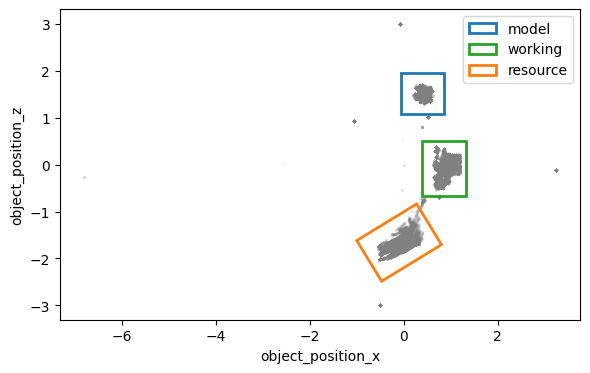

In [99]:
# ── Separate the three ROIs directly from the three fixation-type clusters ──

pos_x, pos_z = "object_position_x", "object_position_z"
df = prepared.dropna(subset=[pos_x, pos_z])

is_temp = df["hit_obj_name"].str.contains("temp", case=False, na=False)
is_res  = df["hit_obj_name"].str.contains(r"_res_\d+$", na=False, regex=True)

from sklearn.cluster import KMeans

res_pts = df.loc[is_res, [pos_x, pos_z]].dropna()
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(res_pts)
res_pts = res_pts.copy()
res_pts["cluster"] = km.labels_

cluster_z_means = res_pts.groupby("cluster")[pos_z].mean()
resource_cluster_id = cluster_z_means.idxmin()
working_cluster_id  = cluster_z_means.idxmax()

resource_pts = res_pts[res_pts["cluster"] == resource_cluster_id][[pos_x, pos_z]]
working_pts  = res_pts[res_pts["cluster"] == working_cluster_id][[pos_x, pos_z]]
model_pts    = df.loc[is_temp, [pos_x, pos_z]].dropna()

print(f"model    n={len(model_pts)}")
print(f"resource n={len(resource_pts)}")
print(f"working  n={len(working_pts)}")

ZONE_MARGIN = 0.3   # <- increased from 0.1
Q_LOW, Q_HIGH = 0.01, 0.99  # <- widened from 0.01/0.99 to include all points

def fit_axis_aligned_bbox(pts, q_low=Q_LOW, q_high=Q_HIGH, margin=ZONE_MARGIN):
    x_lo, x_hi = pts[pos_x].quantile([q_low, q_high])
    z_lo, z_hi = pts[pos_z].quantile([q_low, q_high])
    return {"type": "aligned", "x_min": x_lo-margin, "x_max": x_hi+margin,
            "z_min": z_lo-margin, "z_max": z_hi+margin, "n_points": len(pts)}

def fit_rotated_bbox(pts, q_low=Q_LOW, q_high=Q_HIGH, margin=ZONE_MARGIN):
    xy = pts.to_numpy()
    center = xy.mean(axis=0)
    centered = xy - center
    _, _, vt = np.linalg.svd(centered, full_matrices=False)
    rotated = centered @ vt.T
    u_lo, u_hi = np.quantile(rotated[:, 0], [q_low, q_high])
    v_lo, v_hi = np.quantile(rotated[:, 1], [q_low, q_high])
    return {"type": "rotated", "center": center, "axes": vt,
            "u_min": u_lo-margin, "u_max": u_hi+margin,
            "v_min": v_lo-margin, "v_max": v_hi+margin, "n_points": len(pts)}

def point_in_rotated_bbox(x, z, bb):
    centered = np.array([x, z]) - bb["center"]
    u, v = bb["axes"] @ centered
    return bb["u_min"] <= u <= bb["u_max"] and bb["v_min"] <= v <= bb["v_max"]

def point_in_aligned_bbox(x, z, bb):
    return bb["x_min"] <= x <= bb["x_max"] and bb["z_min"] <= z <= bb["z_max"]

zone_bboxes = {
    "model":    fit_axis_aligned_bbox(model_pts),
    "resource": fit_rotated_bbox(resource_pts),   # tilted desk
    "working":  fit_axis_aligned_bbox(working_pts),
}

def classify_zone(x, z, bboxes):
    if point_in_aligned_bbox(x, z, bboxes["model"]):
        return "model"
    if point_in_rotated_bbox(x, z, bboxes["resource"]):
        return "resource"
    if point_in_aligned_bbox(x, z, bboxes["working"]):
        return "working"
    return "unknown"

# sanity plot
fig, ax = plt.subplots(figsize=(6, 6))
sample = df
ax.scatter(sample[pos_x], sample[pos_z], s=2, alpha=0.05, color="grey")
for zone, color in [("model", "#1f77b4"), ("working", "#2ca02c")]:
    bb = zone_bboxes[zone]
    rect = mpatches.Rectangle((bb["x_min"], bb["z_min"]), bb["x_max"]-bb["x_min"], bb["z_max"]-bb["z_min"],
                               fill=False, edgecolor=color, linewidth=2, label=zone)
    ax.add_patch(rect)
bb = zone_bboxes["resource"]
corners_uv = np.array([[bb["u_min"], bb["v_min"]], [bb["u_max"], bb["v_min"]],
                       [bb["u_max"], bb["v_max"]], [bb["u_min"], bb["v_max"]]])
corners_xz = corners_uv @ bb["axes"] + bb["center"]
ax.add_patch(mpatches.Polygon(corners_xz, fill=False, edgecolor="#ff7f0e", linewidth=2, label="resource"))
ax.set_xlabel(pos_x); ax.set_ylabel(pos_z)
ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

In [73]:
# ── Step 2: classify every fixation by zone + identity ────────────────────
#
# We need the mean object_position (x, z) of the raw samples that make up each
# fixation run, so we can decide which zone (model / resource / working) the
# fixation physically landed in.
#
# NOTE: `run_id` only exists on the local copy created INSIDE detect_fixation_runs,
# not on `prepared`. So instead of matching on run_id, we match each fixation run
# to its raw samples by (participant, condition, trial) + the run's [start, end]
# time window. This is robust and needs no run_id on the raw frame.

def add_fixation_position_and_zone(fix_df, raw_df,
                                     group_cols=("participant_id", "condition_number", "trial_number"),
                                     pos_x="object_position_x", pos_z="object_position_z",
                                     time_col="time_ms"):
    fix_df = fix_df.reset_index(drop=True).copy()
    mean_x = np.full(len(fix_df), np.nan)
    mean_z = np.full(len(fix_df), np.nan)

    # Pre-group raw rows for fast lookup
    raw_grouped = {key: g for key, g in raw_df.groupby(list(group_cols))}

    for i, row in fix_df.iterrows():
        key = tuple(row[c] for c in group_cols)
        g = raw_grouped.get(key)
        if g is None:
            continue
        # raw samples that fall within this fixation run's time window
        run_rows = g[
            (g[time_col] >= row["start_time_ms"]) &
            (g[time_col] <= row["end_time_ms"])
        ]
        if run_rows.empty:
            continue
        mean_x[i] = run_rows[pos_x].mean()
        mean_z[i] = run_rows[pos_z].mean()

    fix_df["mean_pos_x"] = mean_x
    fix_df["mean_pos_z"] = mean_z
    fix_df["fixation_area"] = [
        classify_zone(x, z, zone_bboxes) if pd.notna(x) else "unknown"
        for x, z in zip(fix_df["mean_pos_x"], fix_df["mean_pos_z"])
    ]
    return fix_df


# Apply to ALL stable fixation runs (not just res_*/temp_*), so working-area
# fixations on other objects also get included
all_fix_runs_z = add_fixation_position_and_zone(all_fix_runs[all_fix_runs["stable"]], prepared)

all_fix_runs_z["y_label"] = (
    all_fix_runs_z["dominant_group"].astype(str) + " (" + all_fix_runs_z["fixation_area"] + ")"
)

print(all_fix_runs_z["fixation_area"].value_counts())


fixation_area
working     1776
model       1198
resource     792
unknown      325
Name: count, dtype: int64


## 8. Segment plot: grabs + pre-grab fixations by zone

For a chosen trial, plot a sequence of resource grabs. Each panel = one grab.
Y-axis lanes = fixation zone (template / resource / working). Each fixation dot
is labelled with its short object group (e.g. `temp_068`); the grabbed object's
full name is printed at the grab marker (t=0). Green = the fixated object's brick
ID matches the grabbed brick; grey = no match.


Auto-picked trial with most grabs: P001 C2 T2 (19 grabs)


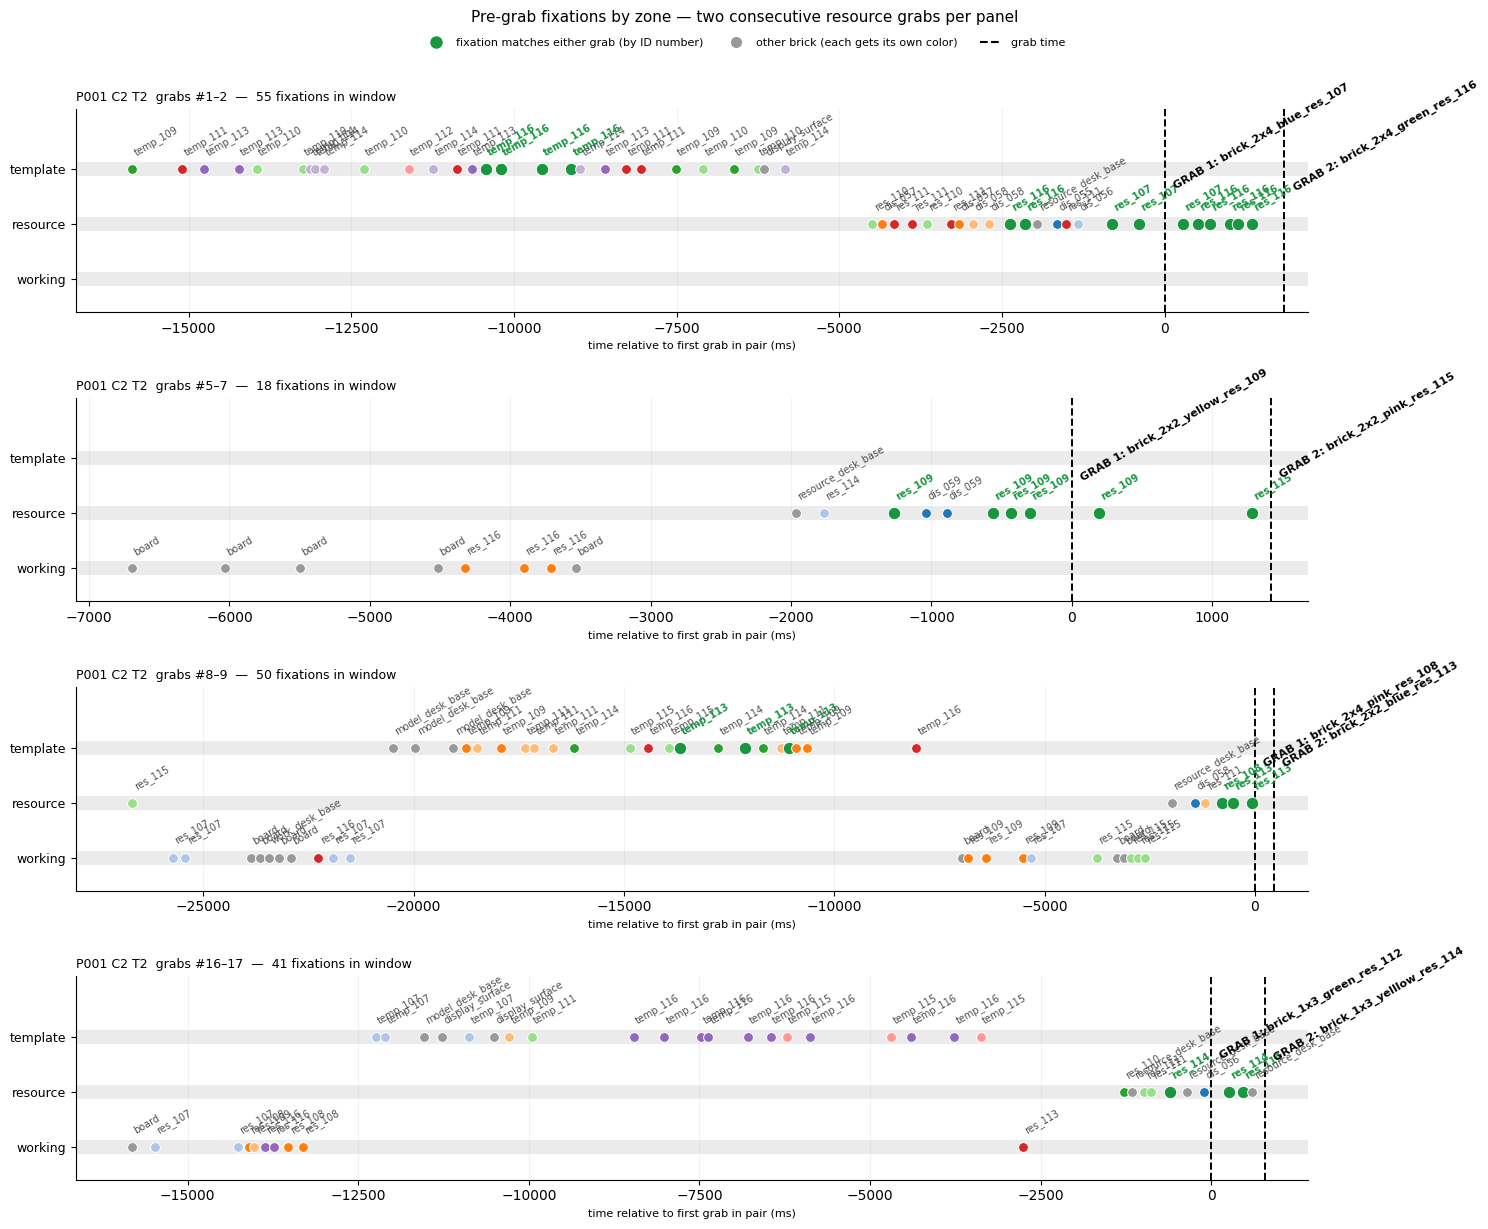

In [74]:
# ── Segment plot: PAIRS of consecutive resource grabs + pre-grab fixations ────
#
# Requires: grab_events, all_fix_runs_z (zone-classification cell),
#           plus re / np / pd / plt already imported.
#
# Each panel shows TWO consecutive resource-area grabs sharing one timeline.
# Matching is by ID NUMBER only: res_18 and temp_18 both match a grab of brick 18.
# A fixation that matches EITHER grab in the panel -> bold green.
# Every other distinct brick ID -> its own color (track it across fixations).

# ---- choose what to plot --------------------------------------------------
PID, COND, TRIAL = None, None, None   # None -> auto-pick trial with most grabs
MAX_PAIRS        = 4                  # how many 2-grab panels to show
ZONE_LANES       = ["template", "resource", "working"]
ZONE_ALIAS       = {"model": "template", "resource": "resource", "working": "working"}
LABEL_ROTATION   = 30                 # degrees, tilted brick names
# ---------------------------------------------------------------------------

def _short_id(name_or_group):
    """brick_..._res_018 / res_018 / temp_018 -> '018' (else None). ID-only match."""
    if pd.isna(name_or_group):
        return None
    s = str(name_or_group)
    m = re.search(r"_(res|temp|dis)_(\d+)$", s) or re.match(r"^(res|temp|dis)_(\d+)$", s)
    return m.group(2) if m else None

def _gtype(name):
    if pd.isna(name): return None
    m = re.search(r"_(res|temp|dis)_\d+$", str(name))
    return m.group(1) if m else None

# resource/template grabs only (skip dis_*)
seg_grabs = grab_events[
    grab_events["grabbed_name"].apply(_gtype).isin(["res", "temp"])
].copy()

# pick trial
if PID is None or COND is None or TRIAL is None:
    counts = (seg_grabs.groupby(["participant_id", "condition_number", "trial_number"])
                       .size().sort_values(ascending=False))
    PID, COND, TRIAL = counts.index[0]
    print(f"Auto-picked trial with most grabs: P{PID} C{COND} T{TRIAL} ({counts.iloc[0]} grabs)")

trial_grabs = (seg_grabs[
        (seg_grabs["participant_id"]   == PID)  &
        (seg_grabs["condition_number"] == COND) &
        (seg_grabs["trial_number"]     == TRIAL)
    ].sort_values("grab_start_time_ms").reset_index(drop=True))

# group grabs into NON-overlapping consecutive pairs: (0,1), (2,3), ...
pairs = [trial_grabs.iloc[i:i+2] for i in range(0, len(trial_grabs), 2)]
pairs = [p for p in pairs if len(p) == 2][:MAX_PAIRS]   # keep full pairs only

# stable fixations in this trial, zone-classified
trial_fix = all_fix_runs_z[
    (all_fix_runs_z["participant_id"]   == PID)  &
    (all_fix_runs_z["condition_number"] == COND) &
    (all_fix_runs_z["trial_number"]     == TRIAL)
].copy()
trial_fix["zone_lane"] = trial_fix["fixation_area"].map(ZONE_ALIAS)

MATCH_COLOR = "#1a9641"   # bold green for matches
lane_y = {z: i for i, z in enumerate(reversed(ZONE_LANES))}   # template top, working bottom
palette = plt.cm.tab20.colors   # distinct colors for non-matching bricks

n = len(pairs)
if n == 0:
    print("Not enough grabs to form a pair in this trial.")
else:
    fig, axes = plt.subplots(n, 1, figsize=(15, 3.0 * n), sharex=False)
    if n == 1:
        axes = [axes]

    for ax, pair in zip(axes, pairs):
        gA, gB   = pair.iloc[0], pair.iloc[1]
        tA, tB   = gA["grab_start_time_ms"], gB["grab_start_time_ms"]
        idA, idB = _short_id(gA["grabbed_name"]), _short_id(gB["grabbed_name"])
        match_ids = {i for i in (idA, idB) if i is not None}

        # window: from the grab BEFORE this pair, up to the 2nd grab
        prevA = gA["prev_grab_start_time_ms"]
        lo = -np.inf if pd.isna(prevA) else prevA
        win = trial_fix[(trial_fix["end_time_ms"] > lo) &
                        (trial_fix["end_time_ms"] <= tB)].sort_values("end_time_ms")

        # assign each NON-matching brick id a stable color
        nonmatch_ids = [i for i in win["dominant_group"].map(_short_id).dropna().unique()
                        if i not in match_ids]
        color_for = {bid: palette[k % len(palette)] for k, bid in enumerate(sorted(nonmatch_ids))}

        # lane guides
        for z in ZONE_LANES:
            ax.axhline(lane_y[z], color="0.92", linewidth=10, zorder=0)

        for _, fx in win.iterrows():
            zone = fx["zone_lane"]
            if zone not in lane_y:
                continue
            t_rel = fx["end_time_ms"] - tA
            fid   = _short_id(fx["dominant_group"])
            is_match = fid in match_ids
            color = MATCH_COLOR if is_match else color_for.get(fid, "0.6")
            ax.scatter(t_rel, lane_y[zone], color=color,
                       s=80 if is_match else 50, zorder=3,
                       edgecolor="white", linewidth=0.7)
            ax.annotate(str(fx["dominant_group"]),
                        (t_rel, lane_y[zone]),
                        textcoords="offset points", xytext=(0, 8),
                        ha="left", va="bottom", rotation=LABEL_ROTATION,
                        fontsize=7,
                        fontweight="bold" if is_match else "normal",
                        color=MATCH_COLOR if is_match else "0.3")

        # two grab markers (relative to tA)
        for g, t, lbl in [(gA, tA, "GRAB 1"), (gB, tB, "GRAB 2")]:
            ax.axvline(t - tA, color="black", linewidth=1.4, linestyle="--", zorder=2)
            ax.annotate(f"{lbl}: {g['grabbed_name']}",
                        (t - tA, len(ZONE_LANES) - 0.4),
                        textcoords="offset points", xytext=(5, 0),
                        ha="left", va="center", rotation=LABEL_ROTATION,
                        fontsize=8, fontweight="bold")

        ax.set_yticks([lane_y[z] for z in ZONE_LANES])
        ax.set_yticklabels(ZONE_LANES, fontsize=9)
        ax.set_ylim(-0.6, len(ZONE_LANES) + 0.1)
        ax.set_xlabel("time relative to first grab in pair (ms)", fontsize=8)
        ax.set_title(f"P{PID} C{int(COND)} T{int(TRIAL)}  "
                     f"grabs #{int(gA['grab_idx_in_trial'])}–{int(gB['grab_idx_in_trial'])}  —  "
                     f"{len(win)} fixations in window",
                     fontsize=9, loc="left")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="x", alpha=0.15)

    legend_handles = [
        plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=MATCH_COLOR,
                   markersize=10, label="fixation matches either grab (by ID number)"),
        plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="0.6",
                   markersize=9, label="other brick (each gets its own color)"),
        plt.Line2D([0],[0], color="black", linestyle="--", label="grab time"),
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=3,
               fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.005))
    fig.suptitle("Pre-grab fixations by zone — two consecutive resource grabs per panel",
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(f"segment_grabpairs_P{PID}_C{int(COND)}_T{int(TRIAL)}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

Auto-picked: P001  C2  T2


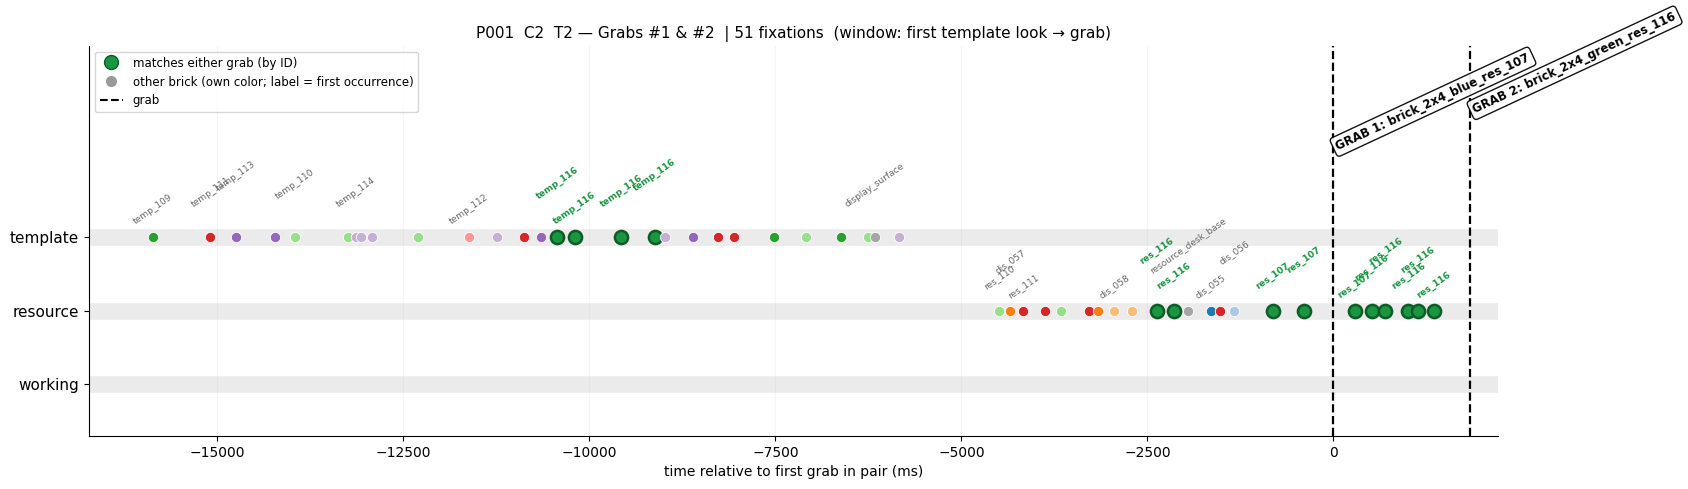

In [75]:
# ══════════════════════════════════════════════════════════════════════════════
# Section 8B — Two clean plots for a selected grab pair
#
# PLOT 1 : Zone-lane timeline  (staggered labels, clean grab annotations)
# PLOT 2 : Fixation sequence strip  (left-to-right, zone shown by background color)
#
# Requires: grab_events, all_fix_runs_z, re, np, pd, plt
# ══════════════════════════════════════════════════════════════════════════════

# ── settings ──────────────────────────────────────────────────────────────────
PID, COND, TRIAL = None, None, None   # None = auto-pick busiest trial
PAIR_INDEX       = 0                  # 0 = grabs 1&2, 1 = grabs 3&4, …
ZONE_LANES       = ["template", "resource", "working"]
ZONE_ALIAS       = {"model": "template", "resource": "resource", "working": "working"}
ZONE_COLORS_BG   = {"template": "#d0e4f7", "resource": "#fde8c8", "working": "#d4edda"}
MATCH_COLOR      = "#1a9641"
MATCH_EDGE      = "#0d5c28"
# ──────────────────────────────────────────────────────────────────────────────

def _short_id(s):
    if pd.isna(s): return None
    m = re.search(r"_(res|temp|dis)_(\d+)$", str(s)) or \
        re.match(r"^(res|temp|dis)_(\d+)$", str(s))
    return m.group(2) if m else None

def _gtype(name):
    if pd.isna(name): return None
    m = re.search(r"_(res|temp|dis)_\d+$", str(name))
    return m.group(1) if m else None

palette = plt.cm.tab20.colors

# ── build trial data ──────────────────────────────────────────────────────────
seg_grabs = grab_events[grab_events["grabbed_name"].apply(_gtype).isin(["res","temp"])].copy()

if PID is None or COND is None or TRIAL is None:
    counts = (seg_grabs.groupby(["participant_id","condition_number","trial_number"])
                       .size().sort_values(ascending=False))
    PID, COND, TRIAL = counts.index[0]
    print(f"Auto-picked: P{PID}  C{COND}  T{TRIAL}")

trial_grabs = (seg_grabs[
    (seg_grabs["participant_id"]   == PID) &
    (seg_grabs["condition_number"] == COND) &
    (seg_grabs["trial_number"]     == TRIAL)
].sort_values("grab_start_time_ms").reset_index(drop=True))

trial_fix = all_fix_runs_z[
    (all_fix_runs_z["participant_id"]   == PID) &
    (all_fix_runs_z["condition_number"] == COND) &
    (all_fix_runs_z["trial_number"]     == TRIAL)
].copy()
trial_fix["zone_lane"] = trial_fix["fixation_area"].map(ZONE_ALIAS)

pairs = [trial_grabs.iloc[i:i+2]
         for i in range(0, len(trial_grabs)-1, 2)
         if i+1 < len(trial_grabs)]

if PAIR_INDEX >= len(pairs):
    print(f"Only {len(pairs)} pairs available. Set PAIR_INDEX 0–{len(pairs)-1}.")
else:
    pair      = pairs[PAIR_INDEX]
    gA, gB    = pair.iloc[0], pair.iloc[1]
    tA, tB    = gA["grab_start_time_ms"], gB["grab_start_time_ms"]
    idA, idB  = _short_id(gA["grabbed_name"]), _short_id(gB["grabbed_name"])
    match_ids = {i for i in (idA, idB) if i is not None}

    # ── window: from first template fixation (before this pair) → grab B ─────
    prevA = gA["prev_grab_start_time_ms"]
    lo    = prevA if pd.notna(prevA) else -np.inf

    pre_fix = trial_fix[(trial_fix["end_time_ms"] > lo) &
                        (trial_fix["end_time_ms"] <= tB)].sort_values("end_time_ms")
    temp_hits = pre_fix[pre_fix["zone_lane"] == "template"]
    t_start   = temp_hits.iloc[0]["start_time_ms"] if not temp_hits.empty else lo

    win = trial_fix[
        (trial_fix["end_time_ms"] >= t_start) &
        (trial_fix["end_time_ms"] <= tB)
    ].sort_values("end_time_ms").reset_index(drop=True)

    # color per non-matching brick id
    nonmatch_ids = sorted({_short_id(x) for x in win["dominant_group"]
                           if _short_id(x) not in match_ids and _short_id(x) is not None})
    color_for    = {bid: palette[k % len(palette)] for k, bid in enumerate(nonmatch_ids)}

    def dot_color(fid):
        return MATCH_COLOR if fid in match_ids else color_for.get(fid, "0.65")

    # ══════════════════════════════════════════════════════════════════════════
    # PLOT 1 — Zone-lane timeline  (staggered labels, clean grab boxes)
    # ══════════════════════════════════════════════════════════════════════════
    lane_y    = {z: i for i, z in enumerate(reversed(ZONE_LANES))}
    # 5 stagger heights that cycle per fixation to spread labels apart
    Y_OFFSETS = [8, 20, 32, 14, 26]
    # label only first occurrence of each non-matching object; always label matches
    labeled   = set()

    fig1, ax = plt.subplots(figsize=(17, 5))

    for z in ZONE_LANES:
        ax.axhline(lane_y[z], color="0.92", linewidth=12, zorder=0)

    for i, (_, fx) in enumerate(win.iterrows()):
        zone  = fx["zone_lane"]
        if zone not in lane_y: continue
        t_rel = fx["end_time_ms"] - tA
        fid   = _short_id(fx["dominant_group"])
        color = dot_color(fid)
        is_match = fid in match_ids

        ax.scatter(t_rel, lane_y[zone], color=color,
                   s=90 if is_match else 55, zorder=3,
                   edgecolor=MATCH_EDGE if is_match else "white",
                   linewidth=1.8 if is_match else 0.6)

        # show label if: match (always) OR first time we see this object
        obj_key = (zone, str(fx["dominant_group"]))
        if is_match or obj_key not in labeled:
            labeled.add(obj_key)
            yoff = Y_OFFSETS[i % len(Y_OFFSETS)]
            ax.annotate(str(fx["dominant_group"]),
                        (t_rel, lane_y[zone]),
                        textcoords="offset points", xytext=(0, yoff),
                        ha="center", va="bottom", rotation=35,
                        fontsize=6.5,
                        fontweight="bold" if is_match else "normal",
                        color=MATCH_COLOR if is_match else "0.4")

    # grab markers — tilted, staggered heights to avoid overlap
    grab_infos = [
        (tA, f"GRAB 1: {gA['grabbed_name']}", len(ZONE_LANES) + 0.15),
        (tB, f"GRAB 2: {gB['grabbed_name']}", len(ZONE_LANES) + 0.65),
    ]
    for t, lbl, y_pos in grab_infos:
        t_rel = t - tA
        ax.axvline(t_rel, color="black", linewidth=1.6, linestyle="--", zorder=2)
        ax.text(t_rel + abs(tB - tA) * 0.004, y_pos, lbl,
                ha="left", va="bottom", fontsize=8.5, fontweight="bold",
                rotation=25,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.92))

    ax.set_yticks([lane_y[z] for z in ZONE_LANES])
    ax.set_yticklabels(ZONE_LANES, fontsize=11)
    ax.set_ylim(-0.7, len(ZONE_LANES) + 1.6)   # extra headroom for staggered labels
    ax.set_xlabel("time relative to first grab in pair (ms)", fontsize=10)
    ax.set_title(f"P{PID}  C{int(COND)}  T{int(TRIAL)} — "
                 f"Grabs #{int(gA['grab_idx_in_trial'])} & #{int(gB['grab_idx_in_trial'])}  "
                 f"| {len(win)} fixations  (window: first template look → grab)",
                 fontsize=11)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="x", alpha=0.12)

    leg = [
        plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=MATCH_COLOR,
                   markeredgecolor=MATCH_EDGE, markersize=10,
                   label="matches either grab (by ID)"),
        plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="0.6",
                   markersize=9, label="other brick (own color; label = first occurrence)"),
        plt.Line2D([0],[0], color="black", linestyle="--", label="grab"),
    ]
    ax.legend(handles=leg, loc="upper left", fontsize=8.5, frameon=True)
    plt.tight_layout()
    plt.savefig(f"plot1_timeline_P{PID}_C{int(COND)}_T{int(TRIAL)}_pair{PAIR_INDEX}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

In [76]:
# ── Cell B: plot grab pair ───────────────────────────────────────────────────
# ── Cell A: list all available trials ────────────────────────────────────────
# Run this first to see what combinations exist and how many grabs each has.

def _gtype(name):
    if pd.isna(name): return None
    m = re.search(r"_(res|temp|dis)_\d+$", str(name))
    return m.group(1) if m else None

_all_grabs = grab_events[grab_events["grabbed_name"].apply(_gtype).isin(["res","temp"])].copy()

summary = (_all_grabs
    .groupby(["participant_id","condition_number","trial_number"])
    .size()
    .reset_index(name="n_grabs")
    .sort_values(["participant_id","condition_number","trial_number"])
)
summary["n_pairs"] = summary["n_grabs"] // 2

print(f"{'PID':>8}  {'COND':>6}  {'TRIAL':>6}  {'GRABS':>6}  {'PAIRS':>6}")
print("-" * 44)
for _, r in summary.iterrows():
    print(f"{str(r.participant_id):>8}  {int(r.condition_number):>6}  "
          f"{int(r.trial_number):>6}  {int(r.n_grabs):>6}  {int(r.n_pairs):>6}")


     PID    COND   TRIAL   GRABS   PAIRS
--------------------------------------------
     001       1       1       4       2
     001       1       2       4       2
     001       1       3      11       5
     001       1       4      11       5
     001       1       5       8       4
     001       1       6      10       5
     001       2       1       9       4
     001       2       2      19       9
     001       2       3       5       2
     001       2       4      10       5
     001       2       5      13       6
     001       2       6       4       2
     001       3       1       9       4
     001       3       2      10       5
     001       3       3       7       3
     001       3       4      12       6
     001       3       5       9       4
     001       3       6       4       2


Auto-filled missing values → P001  C3  T2
Window: last 15,000 ms before grab A  →  42 fixations


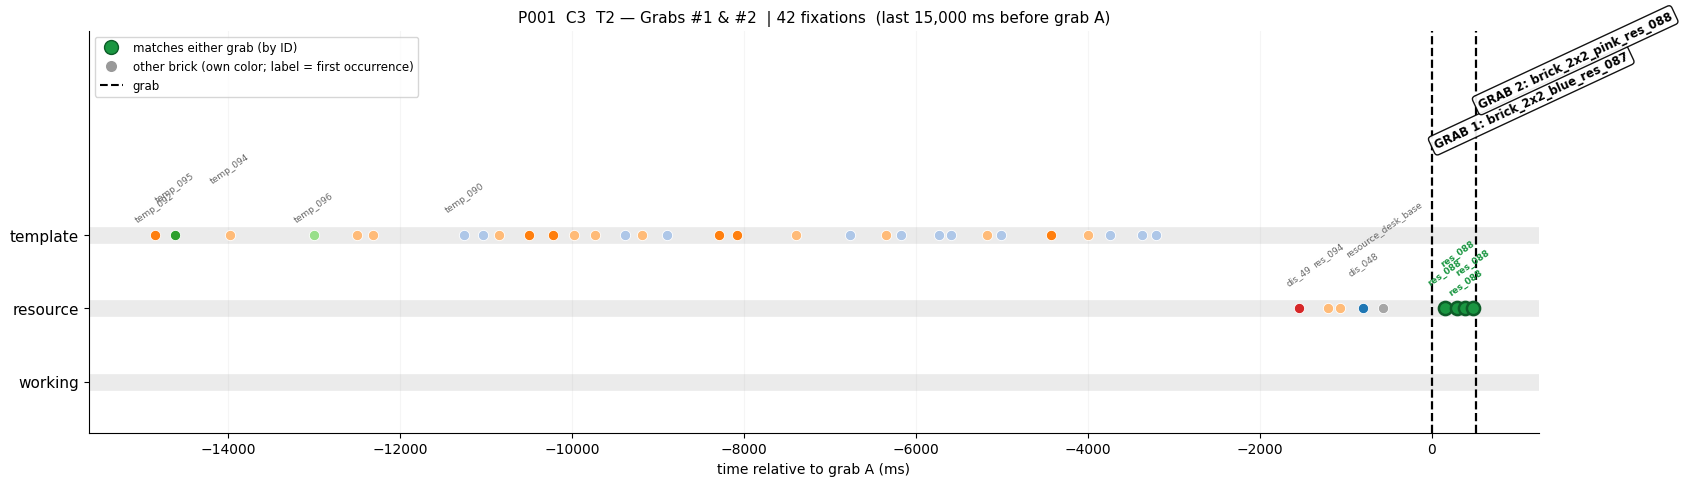

In [77]:
# ── Cell B: plot grab pair ───────────────────────────────────────────────────
# Set PID / COND / TRIAL from Cell A output. PAIR_INDEX 0 = grabs 1&2, 1 = grabs 3&4 …
#
# WINDOW_MODE options:
#   "template"  – from the first template fixation up to grab B  (shows the full decision)
#   "time"      – WINDOW_VALUE ms before grab A  (e.g. 5000 = last 5 sec)
#   "nfix"      – last WINDOW_VALUE fixations before grab B  (e.g. 15)

# ── CHANGE THESE ─────────────────────────────────────────────────────────────
PID          = None          # e.g. "P001"  or None for auto
COND         = 3          # e.g. 2
TRIAL        = 2          # e.g. 2
PAIR_INDEX   = 0             # which pair of consecutive grabs
WINDOW_MODE  = "time"    # "template" | "time" | "nfix"
WINDOW_VALUE = 15000          # used only for "time" (ms) or "nfix" (count)
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.patches as mpatches

ZONE_LANES    = ["template", "resource", "working"]
ZONE_ALIAS    = {"model": "template", "resource": "resource", "working": "working"}
ZONE_COLORS   = {"template": "#d0e4f7", "resource": "#fde8c8", "working": "#d4edda"}
MATCH_COLOR   = "#1a9641"
MATCH_EDGE    = "#0d5c28"
palette       = plt.cm.tab20.colors

def _short_id(s):
    if pd.isna(s): return None
    m = re.search(r"_(res|temp|dis)_(\d+)$", str(s)) or \
        re.match(r"^(res|temp|dis)_(\d+)$", str(s))
    return m.group(2) if m else None

def _gtype(name):
    if pd.isna(name): return None
    m = re.search(r"_(res|temp|dis)_\d+$", str(name))
    return m.group(1) if m else None

# ── pick trial ───────────────────────────────────────────────────────────────
seg_grabs = grab_events[grab_events["grabbed_name"].apply(_gtype).isin(["res","temp"])].copy()

if PID is None or COND is None or TRIAL is None:
    counts = (seg_grabs.groupby(["participant_id","condition_number","trial_number"])
                       .size().sort_values(ascending=False))
    _pid, _cond, _trial = counts.index[0]
    if PID   is None: PID   = _pid
    if COND  is None: COND  = _cond
    if TRIAL is None: TRIAL = _trial
    print(f"Auto-filled missing values → P{PID}  C{COND}  T{TRIAL}")

trial_grabs = (seg_grabs[
    (seg_grabs["participant_id"]   == PID) &
    (seg_grabs["condition_number"] == COND) &
    (seg_grabs["trial_number"]     == TRIAL)
].sort_values("grab_start_time_ms").reset_index(drop=True))

trial_fix = all_fix_runs_z[
    (all_fix_runs_z["participant_id"]   == PID) &
    (all_fix_runs_z["condition_number"] == COND) &
    (all_fix_runs_z["trial_number"]     == TRIAL)
].copy()
trial_fix["zone_lane"] = trial_fix["fixation_area"].map(ZONE_ALIAS)

# ── select pair ──────────────────────────────────────────────────────────────
pairs = [trial_grabs.iloc[i:i+2]
         for i in range(0, len(trial_grabs)-1, 2)
         if i+1 < len(trial_grabs)]

if PAIR_INDEX >= len(pairs):
    raise ValueError(f"Only {len(pairs)} pairs (0–{len(pairs)-1}) for this trial.")

pair     = pairs[PAIR_INDEX]
gA, gB   = pair.iloc[0], pair.iloc[1]
tA, tB   = gA["grab_start_time_ms"], gB["grab_start_time_ms"]
idA, idB = _short_id(gA["grabbed_name"]), _short_id(gB["grabbed_name"])
match_ids = {i for i in (idA, idB) if i is not None}

# ── window ───────────────────────────────────────────────────────────────────
all_before = trial_fix[trial_fix["end_time_ms"] <= tB].sort_values("end_time_ms")

if WINDOW_MODE == "template":
    temp_hits = all_before[all_before["zone_lane"] == "template"]
    prevA     = gA["prev_grab_start_time_ms"]
    lo        = prevA if pd.notna(prevA) else -np.inf
    after_prev = all_before[all_before["end_time_ms"] > lo]
    temp_after = after_prev[after_prev["zone_lane"] == "template"]
    t_start   = temp_after.iloc[0]["start_time_ms"] if not temp_after.empty else lo
    win = trial_fix[(trial_fix["end_time_ms"] >= t_start) &
                    (trial_fix["end_time_ms"] <= tB)].sort_values("end_time_ms").reset_index(drop=True)
    window_desc = "from first template look"

elif WINDOW_MODE == "time":
    win = all_before[all_before["end_time_ms"] >= tA - WINDOW_VALUE].reset_index(drop=True)
    window_desc = f"last {WINDOW_VALUE:,} ms before grab A"

elif WINDOW_MODE == "nfix":
    win = all_before.tail(WINDOW_VALUE).reset_index(drop=True)
    window_desc = f"last {WINDOW_VALUE} fixations"

else:
    raise ValueError("WINDOW_MODE must be 'template', 'time', or 'nfix'")

print(f"Window: {window_desc}  →  {len(win)} fixations")

# ── color helpers ─────────────────────────────────────────────────────────────
nonmatch_ids = sorted({_short_id(x) for x in win["dominant_group"]
                       if _short_id(x) not in match_ids and _short_id(x) is not None})
color_for    = {bid: palette[k % len(palette)] for k, bid in enumerate(nonmatch_ids)}

def dot_color(fid):
    return MATCH_COLOR if fid in match_ids else color_for.get(fid, "0.65")

tag = f"P{PID}_C{int(COND)}_T{int(TRIAL)}_pair{PAIR_INDEX}_{WINDOW_MODE}"

# ════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Zone-lane timeline
# ════════════════════════════════════════════════════════════════════════════
lane_y    = {z: i for i, z in enumerate(reversed(ZONE_LANES))}
Y_OFFSETS = [8, 22, 36, 15, 29]
labeled   = set()

fig1, ax = plt.subplots(figsize=(17, 5))

for z in ZONE_LANES:
    ax.axhline(lane_y[z], color="0.92", linewidth=12, zorder=0)

for i, (_, fx) in enumerate(win.iterrows()):
    zone  = fx["zone_lane"]
    if zone not in lane_y: continue
    t_rel = fx["end_time_ms"] - tA
    fid   = _short_id(fx["dominant_group"])
    color = dot_color(fid)
    is_match = fid in match_ids

    ax.scatter(t_rel, lane_y[zone], color=color,
               s=90 if is_match else 55, zorder=3,
               edgecolor=MATCH_EDGE if is_match else "white",
               linewidth=1.8 if is_match else 0.6)

    obj_key = (zone, str(fx["dominant_group"]))
    if is_match or obj_key not in labeled:
        labeled.add(obj_key)
        yoff = Y_OFFSETS[i % len(Y_OFFSETS)]
        ax.annotate(str(fx["dominant_group"]),
                    (t_rel, lane_y[zone]),
                    textcoords="offset points", xytext=(0, yoff),
                    ha="center", va="bottom", rotation=35,
                    fontsize=6.5,
                    fontweight="bold" if is_match else "normal",
                    color=MATCH_COLOR if is_match else "0.4")

for (g, t, lbl, ypos) in [
        (gA, tA, f"GRAB 1: {gA['grabbed_name']}", len(ZONE_LANES) + 0.15),
        (gB, tB, f"GRAB 2: {gB['grabbed_name']}", len(ZONE_LANES) + 0.70)]:
    t_rel = t - tA
    ax.axvline(t_rel, color="black", linewidth=1.6, linestyle="--", zorder=2)
    ax.text(t_rel + abs(tB - tA) * 0.004, ypos, lbl,
            ha="left", va="bottom", fontsize=8.5, fontweight="bold", rotation=25,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.92))

ax.set_yticks([lane_y[z] for z in ZONE_LANES])
ax.set_yticklabels(ZONE_LANES, fontsize=11)
ax.set_ylim(-0.7, len(ZONE_LANES) + 1.8)
ax.set_xlabel("time relative to grab A (ms)", fontsize=10)
ax.set_title(f"P{PID}  C{int(COND)}  T{int(TRIAL)} — "
             f"Grabs #{int(gA['grab_idx_in_trial'])} & #{int(gB['grab_idx_in_trial'])}  "
             f"| {len(win)} fixations  ({window_desc})",
             fontsize=11)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="x", alpha=0.12)
ax.legend(handles=[
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=MATCH_COLOR,
               markeredgecolor=MATCH_EDGE, markersize=10, label="matches either grab (by ID)"),
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="0.6",
               markersize=9, label="other brick (own color; label = first occurrence)"),
    plt.Line2D([0],[0], color="black", linestyle="--", label="grab"),
], loc="upper left", fontsize=8.5, frameon=True)
plt.tight_layout()
plt.savefig(f"plot1_timeline_{tag}.png", dpi=150, bbox_inches="tight")
plt.show()




In [78]:
# ── detect_grab_events_all: same as detect_grab_events but keeps EVERYTHING ──

def detect_grab_events_all(df):
    block_cols = ["participant_id", "condition_number", "trial_number"]
    events = []

    for _, grp in df.groupby(block_cols, sort=True, dropna=False):
        grp = grp.sort_values("gaze_capture_time").reset_index(drop=True)

        for hand in ("Left", "Right"):
            grab_col = f"bt_{hand}Hand_grabbed_name"
            xc, yc, zc = _get_grab_pos_cols(hand)
            has_pos = all(c in grp.columns for c in (xc, yc, zc))

            vals      = grp[grab_col].astype(object).to_numpy()
            t_ms      = grp["time_ms"].to_numpy()
            t_ns      = grp["gaze_capture_time"].to_numpy()
            pos_x     = grp[xc].to_numpy() if has_pos else np.full(len(grp), np.nan)
            pos_y     = grp[yc].to_numpy() if has_pos else np.full(len(grp), np.nan)
            pos_z     = grp[zc].to_numpy() if has_pos else np.full(len(grp), np.nan)
            left_foot  = grp["bt_LeftFootArea"].to_numpy()
            right_foot = grp["bt_RightFootArea"].to_numpy()

            i = 0
            while i < len(grp):
                name = vals[i]
                if not is_brick_name(name):
                    i += 1; continue
                start_i = i
                while i + 1 < len(grp) and vals[i + 1] == name:
                    i += 1
                end_i = i

                lf = left_foot[start_i]
                rf = right_foot[start_i]
                area = "Resource" if (lf == "Resource" or rf == "Resource") else "NonResource"

                events.append({
                    "participant_id":      grp["participant_id"].iloc[0],
                    "condition_number":    grp["condition_number"].iloc[0],
                    "trial_number":        grp["trial_number"].iloc[0],
                    "hand":                hand,
                    "grabbed_name":        name,
                    "grab_start_time_ms":  t_ms[start_i],
                    "grab_start_time_ns":  t_ns[start_i],
                    "grab_end_time_ms":    t_ms[end_i],
                    "grab_start_pos_x":    pos_x[start_i],
                    "grab_start_pos_y":    pos_y[start_i],
                    "grab_start_pos_z":    pos_z[start_i],
                    "grab_start_area":     area,   # "Resource" or "NonResource" (working etc.)
                })
                i += 1

    if not events:
        return pd.DataFrame()

    out = (
        pd.DataFrame(events)
        .sort_values(["participant_id", "condition_number", "trial_number", "grab_start_time_ns"])
        .reset_index(drop=True)
    )
    bc = ["participant_id", "condition_number", "trial_number"]
    out["grab_idx_in_trial"]       = out.groupby(bc).cumcount() + 1
    out["prev_grab_start_time_ms"] = out.groupby(bc)["grab_start_time_ms"].shift(1)

    return out


# ── build the unfiltered grab table with type + group annotations ───────────

def grabbed_type(name):
    if pd.isna(name): return None
    m = re.search(r"_(res|temp|dis)_\d+$", str(name))
    return m.group(1) if m else None

grab_events_all = detect_grab_events_all(prepared)
grab_events_all["grabbed_type"]     = grab_events_all["grabbed_name"].apply(grabbed_type)
grab_events_all["grabbed_group"]    = grab_events_all["grabbed_name"].apply(group_from_grabbed_name)
grab_events_all["grabbed_brick_id"] = grab_events_all["grabbed_group"].apply(extract_brick_id)

print(f"Total grabs (all types, all areas): {len(grab_events_all)}")
print(grab_events_all["grab_start_area"].value_counts())
print(grab_events_all["grabbed_type"].value_counts(dropna=False))

Total grabs (all types, all areas): 503
grab_start_area
NonResource    329
Resource       174
Name: count, dtype: int64
grabbed_type
res    481
dis     22
Name: count, dtype: int64


Top 3 pairs (all_three_zones, transitions, has_match):
  #1  P001 C1 T4 pair_idx=1  score=(1, 11, 1)  fixations=46
  #2  P001 C1 T3 pair_idx=3  score=(1, 10, 1)  fixations=146
  #3  P001 C3 T2 pair_idx=1  score=(1, 6, 1)  fixations=114


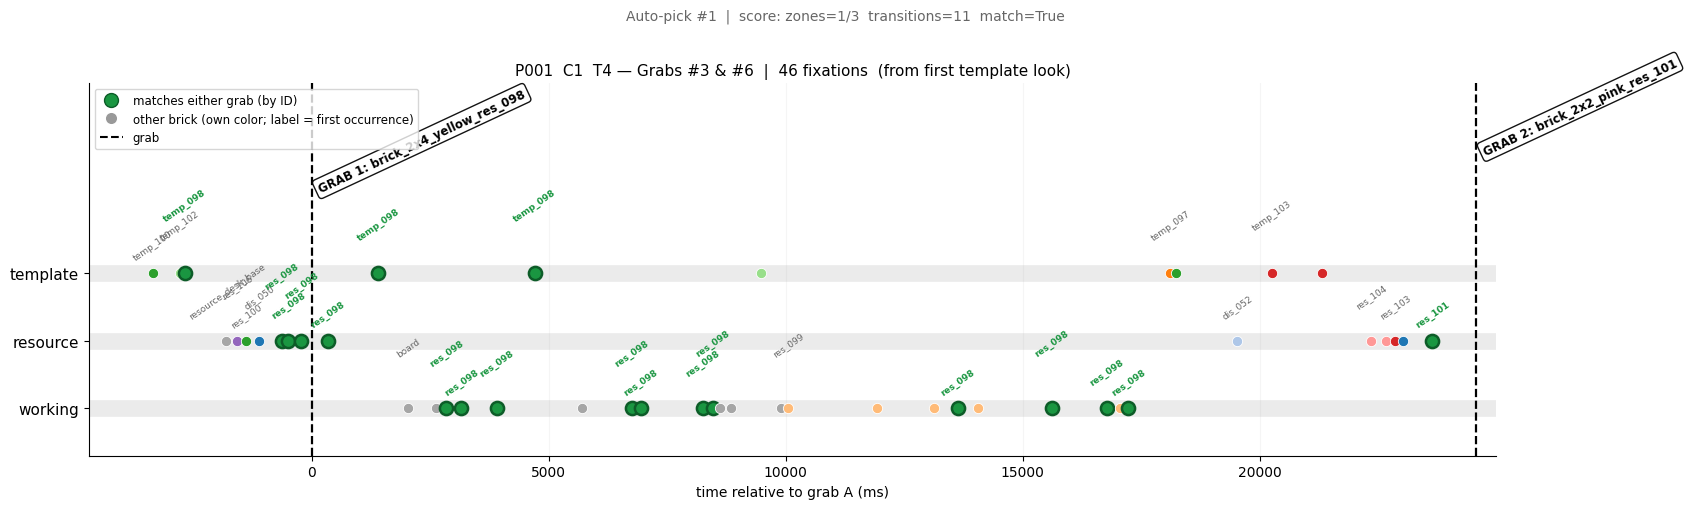

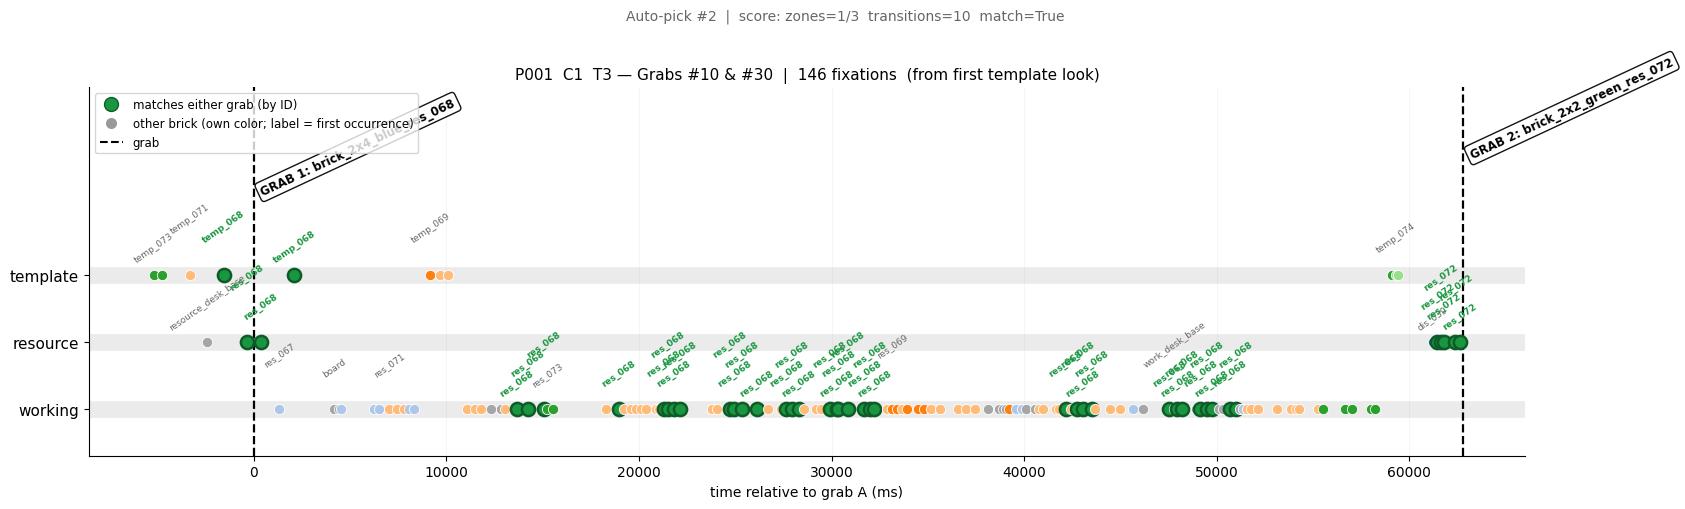

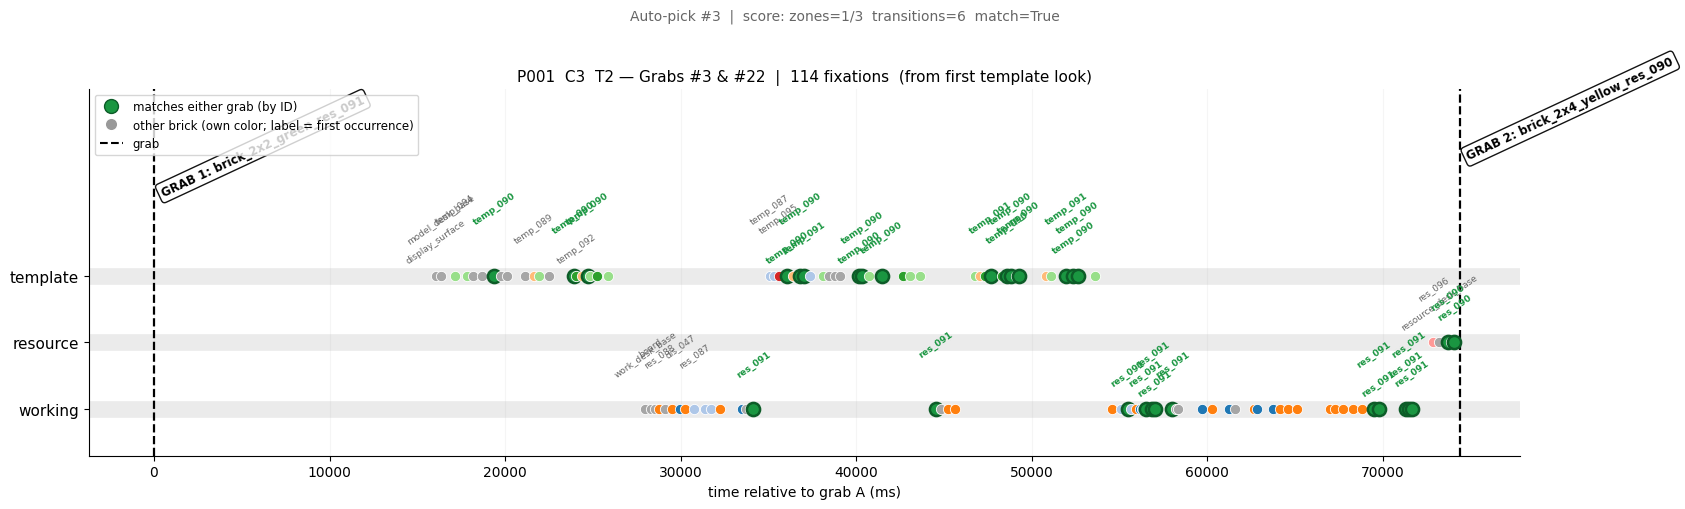

In [79]:
# ── Cell C: auto-pick & plot the most "zone-rich" grab pairs ─────────────────
#
# Finds pairs where the participant visits ALL THREE zones (template, resource,
# working) before the two grabs — i.e. the most complete behavioural episodes.
# Ranks by: (1) all 3 zones present, (2) number of zone transitions, (3) match
# in at least one grab. Plots Plot 1 + Plot 2 for the top N_PLOTS pairs.

# ── settings ─────────────────────────────────────────────────────────────────
N_PLOTS      = 3          # how many pairs to plot
WINDOW_MODE  = "template" # "template" | "time" | "nfix"
WINDOW_VALUE = 15000       # only used for "time" (ms) or "nfix" (count)
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.patches as mpatches

ZONE_LANES  = ["template", "resource", "working"]
ZONE_ALIAS  = {"model": "template", "resource": "resource", "working": "working"}
ZONE_COLORS = {"template": "#d0e4f7", "resource": "#fde8c8", "working": "#d4edda"}
MATCH_COLOR = "#1a9641"
MATCH_EDGE  = "#0d5c28"
palette     = plt.cm.tab20.colors

def _short_id(s):
    if pd.isna(s): return None
    m = re.search(r"_(res|temp|dis)_(\d+)$", str(s)) or \
        re.match(r"^(res|temp|dis)_(\d+)$", str(s))
    return m.group(2) if m else None

def _gtype(name):
    if pd.isna(name): return None
    m = re.search(r"_(res|temp|dis)_\d+$", str(name))
    return m.group(1) if m else None

def get_window(trial_fix, gA, gB, mode, value):
    tA, tB = gA["grab_start_time_ms"], gB["grab_start_time_ms"]
    all_before = trial_fix[trial_fix["end_time_ms"] <= tB].sort_values("end_time_ms")
    if mode == "template":
        prevA      = gA["prev_grab_start_time_ms"]
        lo         = prevA if pd.notna(prevA) else -np.inf
        after_prev = all_before[all_before["end_time_ms"] > lo]
        temp_after = after_prev[after_prev["zone_lane"] == "template"]
        t_start    = temp_after.iloc[0]["start_time_ms"] if not temp_after.empty else lo
        win = trial_fix[(trial_fix["end_time_ms"] >= t_start) &
                        (trial_fix["end_time_ms"] <= tB)].sort_values("end_time_ms").reset_index(drop=True)
        desc = "from first template look"
    elif mode == "time":
        win  = all_before[all_before["end_time_ms"] >= tA - value].reset_index(drop=True)
        desc = f"last {value:,} ms"
    elif mode == "nfix":
        win  = all_before.tail(value).reset_index(drop=True)
        desc = f"last {value} fixations"
    return win, desc

def score_pair(win, match_ids):
    zones      = set(win["zone_lane"].dropna())
    n_zones    = len(zones & {"template","resource","working"})
    all_three  = int(n_zones == 3)
    lane_seq   = win["zone_lane"].dropna().tolist()
    transitions = sum(1 for a,b in zip(lane_seq, lane_seq[1:]) if a != b)
    has_match  = int(any(_short_id(x) in match_ids for x in win["dominant_group"]))
    return (all_three, transitions, has_match)

# ── scan every pair in every trial ───────────────────────────────────────────
seg_grabs = grab_events[grab_events["grabbed_name"].apply(_gtype).isin(["res","temp"])].copy()

candidates = []
for (pid, cond, trial), tg in seg_grabs.groupby(["participant_id","condition_number","trial_number"]):
    tg = tg.sort_values("grab_start_time_ms").reset_index(drop=True)
    tf = all_fix_runs_z[
        (all_fix_runs_z["participant_id"]   == pid) &
        (all_fix_runs_z["condition_number"] == cond) &
        (all_fix_runs_z["trial_number"]     == trial)
    ].copy()
    tf["zone_lane"] = tf["fixation_area"].map(ZONE_ALIAS)

    for i in range(0, len(tg)-1, 2):
        gA_, gB_    = tg.iloc[i], tg.iloc[i+1]
        idA_, idB_  = _short_id(gA_["grabbed_name"]), _short_id(gB_["grabbed_name"])
        mids        = {x for x in (idA_, idB_) if x}
        win_, _     = get_window(tf, gA_, gB_, WINDOW_MODE, WINDOW_VALUE)
        if len(win_) < 3: continue
        s = score_pair(win_, mids)
        candidates.append((s, pid, cond, trial, i, gA_, gB_, tf, win_))

candidates.sort(key=lambda x: x[0], reverse=True)
top = candidates[:N_PLOTS]

if not top:
    print("No valid pairs found — try loosening WINDOW_MODE or check all_fix_runs_z.")
else:
    print(f"Top {len(top)} pairs (all_three_zones, transitions, has_match):")
    for rank, (s, pid, cond, trial, pi, gA_, gB_, tf_, win_) in enumerate(top):
        print(f"  #{rank+1}  P{pid} C{int(cond)} T{int(trial)} "
              f"pair_idx={pi//2}  score={s}  fixations={len(win_)}")

    for rank, (s, pid, cond, trial, pi, gA_, gB_, tf_, win_) in enumerate(top):
        tA, tB    = gA_["grab_start_time_ms"], gB_["grab_start_time_ms"]
        idA_, idB_= _short_id(gA_["grabbed_name"]), _short_id(gB_["grabbed_name"])
        match_ids = {x for x in (idA_, idB_) if x}
        win, desc = get_window(tf_, gA_, gB_, WINDOW_MODE, WINDOW_VALUE)

        nonmatch_ids = sorted({_short_id(x) for x in win["dominant_group"]
                               if _short_id(x) not in match_ids and _short_id(x) is not None})
        color_for    = {bid: palette[k % len(palette)] for k, bid in enumerate(nonmatch_ids)}

        def dot_color(fid):
            return MATCH_COLOR if fid in match_ids else color_for.get(fid, "0.65")

        tag = f"auto{rank+1}_P{pid}_C{int(cond)}_T{int(trial)}_pi{pi//2}_{WINDOW_MODE}"

        # ── Plot 1: timeline ─────────────────────────────────────────────────
        lane_y    = {z: i for i, z in enumerate(reversed(ZONE_LANES))}
        Y_OFFSETS = [8, 22, 36, 15, 29]
        labeled   = set()

        fig1, ax = plt.subplots(figsize=(17, 5))
        fig1.suptitle(f"Auto-pick #{rank+1}  |  score: zones={s[0]}/3  transitions={s[1]}  match={bool(s[2])}",
                      fontsize=10, color="0.4", y=1.01)

        for z in ZONE_LANES:
            ax.axhline(lane_y[z], color="0.92", linewidth=12, zorder=0)

        for i, (_, fx) in enumerate(win.iterrows()):
            zone = fx["zone_lane"]
            if zone not in lane_y: continue
            t_rel    = fx["end_time_ms"] - tA
            fid      = _short_id(fx["dominant_group"])
            color    = dot_color(fid)
            is_match = fid in match_ids

            ax.scatter(t_rel, lane_y[zone], color=color,
                       s=90 if is_match else 55, zorder=3,
                       edgecolor=MATCH_EDGE if is_match else "white",
                       linewidth=1.8 if is_match else 0.6)

            obj_key = (zone, str(fx["dominant_group"]))
            if is_match or obj_key not in labeled:
                labeled.add(obj_key)
                yoff = Y_OFFSETS[i % len(Y_OFFSETS)]
                ax.annotate(str(fx["dominant_group"]),
                            (t_rel, lane_y[zone]),
                            textcoords="offset points", xytext=(0, yoff),
                            ha="center", va="bottom", rotation=35, fontsize=6.5,
                            fontweight="bold" if is_match else "normal",
                            color=MATCH_COLOR if is_match else "0.4")

        for (g_, t_, lbl_, ypos_) in [
                (gA_, tA, f"GRAB 1: {gA_['grabbed_name']}", len(ZONE_LANES) + 0.15),
                (gB_, tB, f"GRAB 2: {gB_['grabbed_name']}", len(ZONE_LANES) + 0.70)]:
            t_rel = t_ - tA
            ax.axvline(t_rel, color="black", linewidth=1.6, linestyle="--", zorder=2)
            ax.text(t_rel + abs(tB - tA) * 0.004, ypos_, lbl_,
                    ha="left", va="bottom", fontsize=8.5, fontweight="bold", rotation=25,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.92))

        ax.set_yticks([lane_y[z] for z in ZONE_LANES])
        ax.set_yticklabels(ZONE_LANES, fontsize=11)
        ax.set_ylim(-0.7, len(ZONE_LANES) + 1.8)
        ax.set_xlabel("time relative to grab A (ms)", fontsize=10)
        ax.set_title(f"P{pid}  C{int(cond)}  T{int(trial)} — "
                     f"Grabs #{int(gA_['grab_idx_in_trial'])} & #{int(gB_['grab_idx_in_trial'])}"
                     f"  |  {len(win)} fixations  ({desc})", fontsize=11)
        ax.spines[["top","right"]].set_visible(False)
        ax.grid(axis="x", alpha=0.12)
        ax.legend(handles=[
            plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=MATCH_COLOR,
                       markeredgecolor=MATCH_EDGE, markersize=10, label="matches either grab (by ID)"),
            plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="0.6",
                       markersize=9, label="other brick (own color; label = first occurrence)"),
            plt.Line2D([0],[0], color="black", linestyle="--", label="grab"),
        ], loc="upper left", fontsize=8.5, frameon=True)
        plt.tight_layout()
        plt.savefig(f"plot1_timeline_{tag}.png", dpi=150, bbox_inches="tight")
        plt.show()

       

Top 10 pairs (all_three_zones, transitions, has_match):
  #1  P001 C2 T2 grabs 29&30  score=(1, 10, 1)  fixations=75  [NonResource,res] -> [NonResource,res]
  #2  P001 C2 T2 grabs 30&31  score=(1, 10, 1)  fixations=76  [NonResource,res] -> [NonResource,res]
  #3  P001 C1 T3 grabs 3&4  score=(1, 6, 1)  fixations=33  [NonResource,res] -> [Resource,res]
  #4  P001 C1 T3 grabs 10&11  score=(1, 6, 1)  fixations=14  [Resource,res] -> [NonResource,res]
  #5  P001 C1 T4 grabs 3&4  score=(1, 5, 1)  fixations=20  [Resource,res] -> [NonResource,res]
  #6  P001 C1 T4 grabs 5&6  score=(1, 5, 1)  fixations=21  [NonResource,res] -> [Resource,res]
  #7  P001 C3 T2 grabs 26&27  score=(1, 5, 1)  fixations=51  [Resource,res] -> [NonResource,res]
  #8  P001 C1 T4 grabs 12&13  score=(1, 4, 1)  fixations=24  [Resource,res] -> [Resource,res]
  #9  P001 C1 T4 grabs 13&14  score=(1, 4, 1)  fixations=25  [Resource,res] -> [Resource,res]
  #10  P001 C1 T6 grabs 11&12  score=(1, 4, 1)  fixations=40  [Resource,res

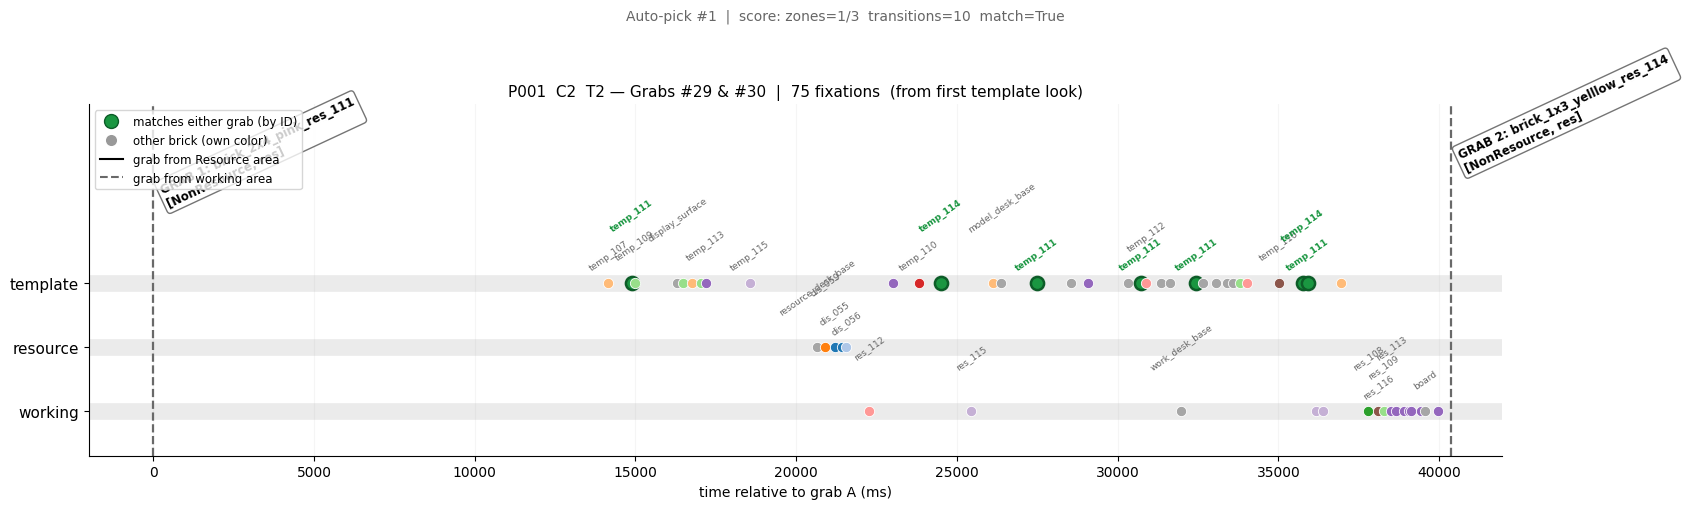

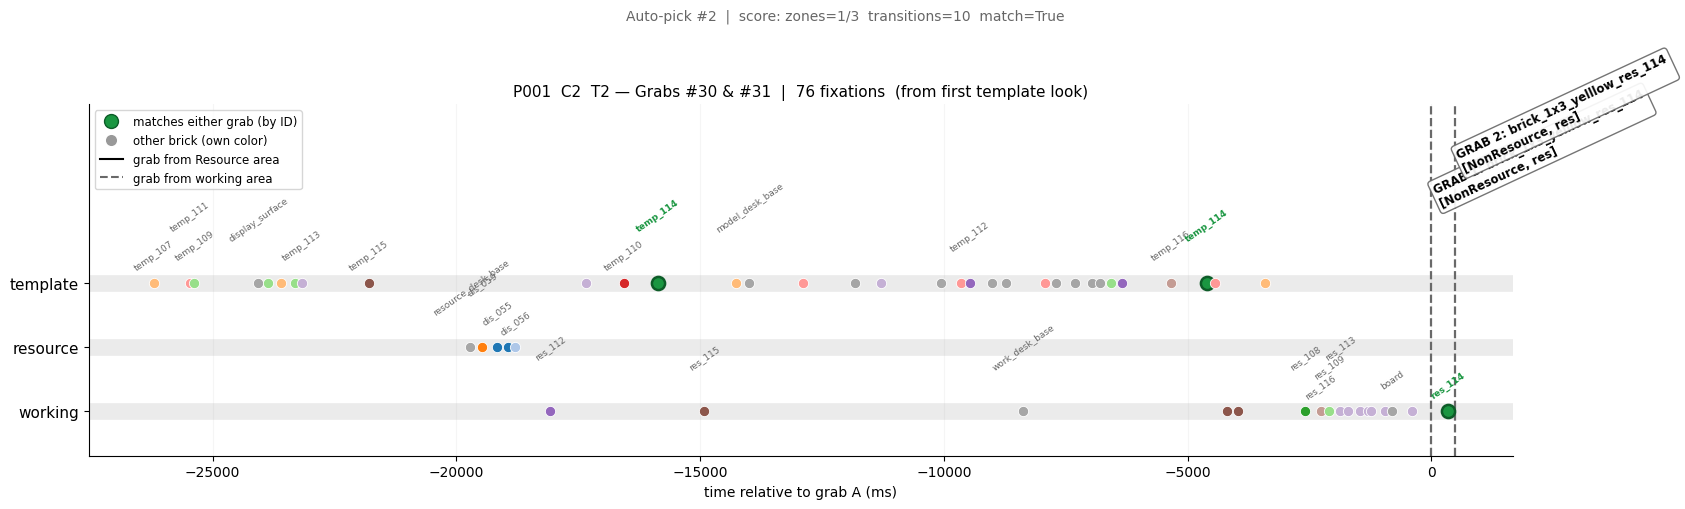

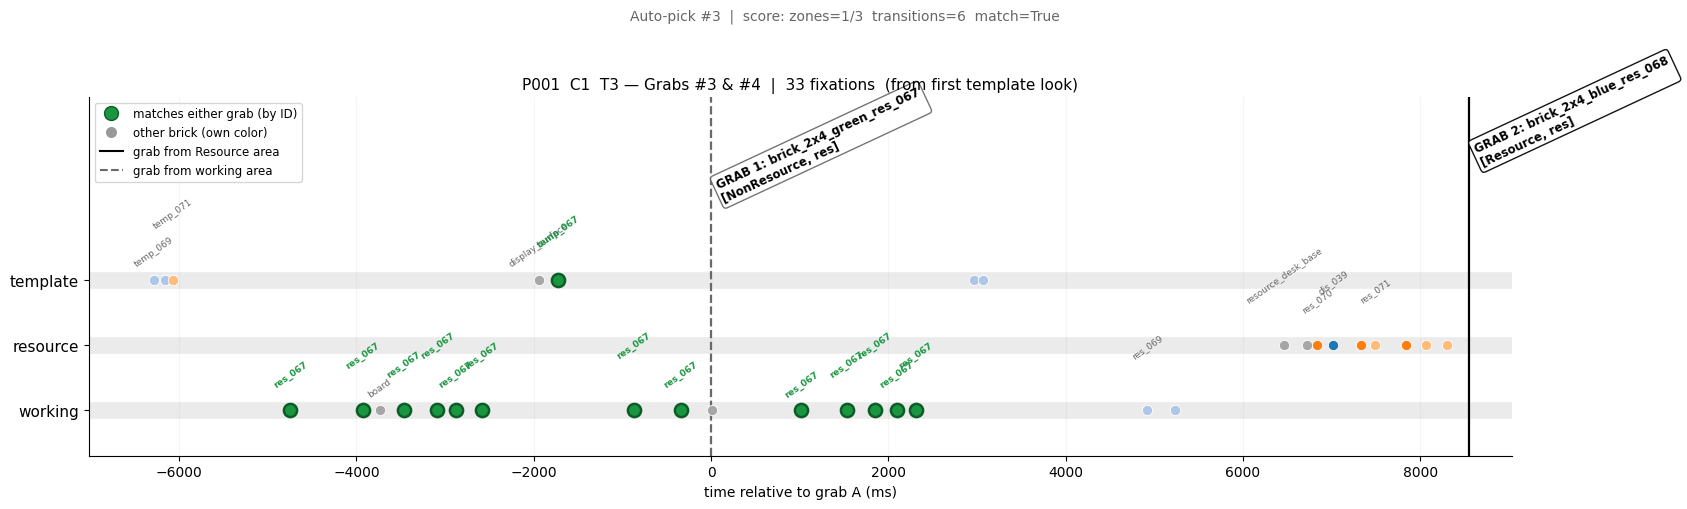

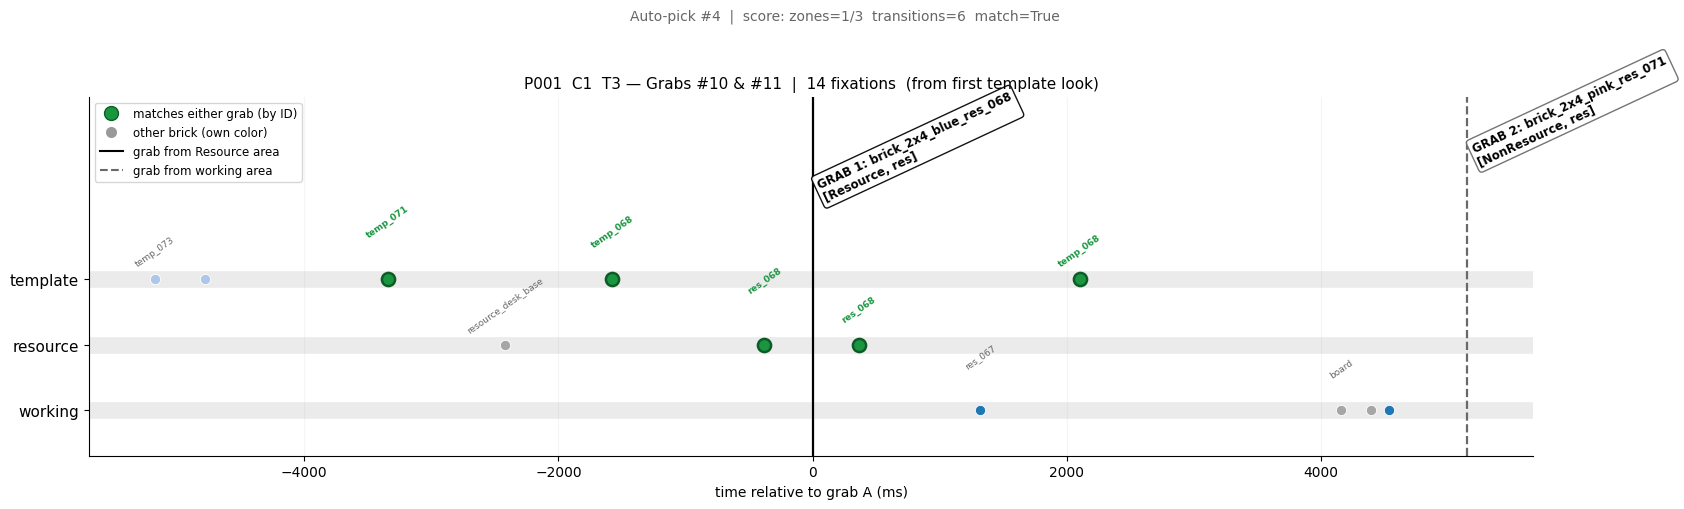

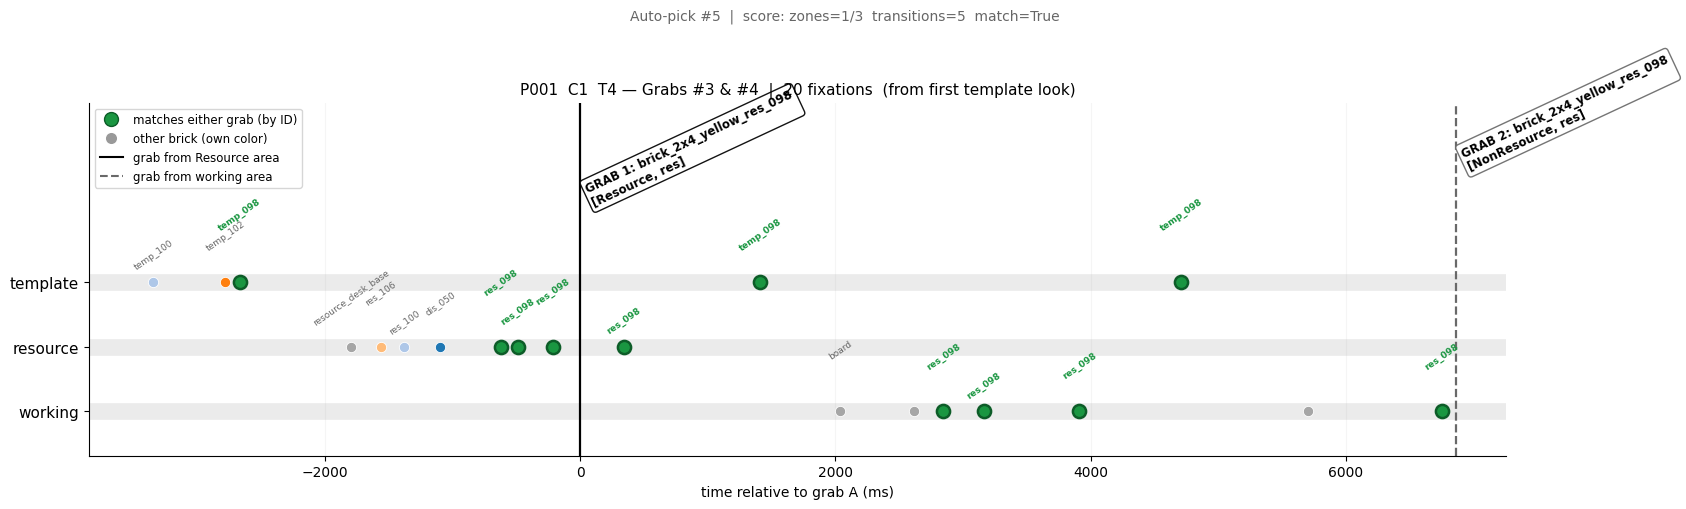

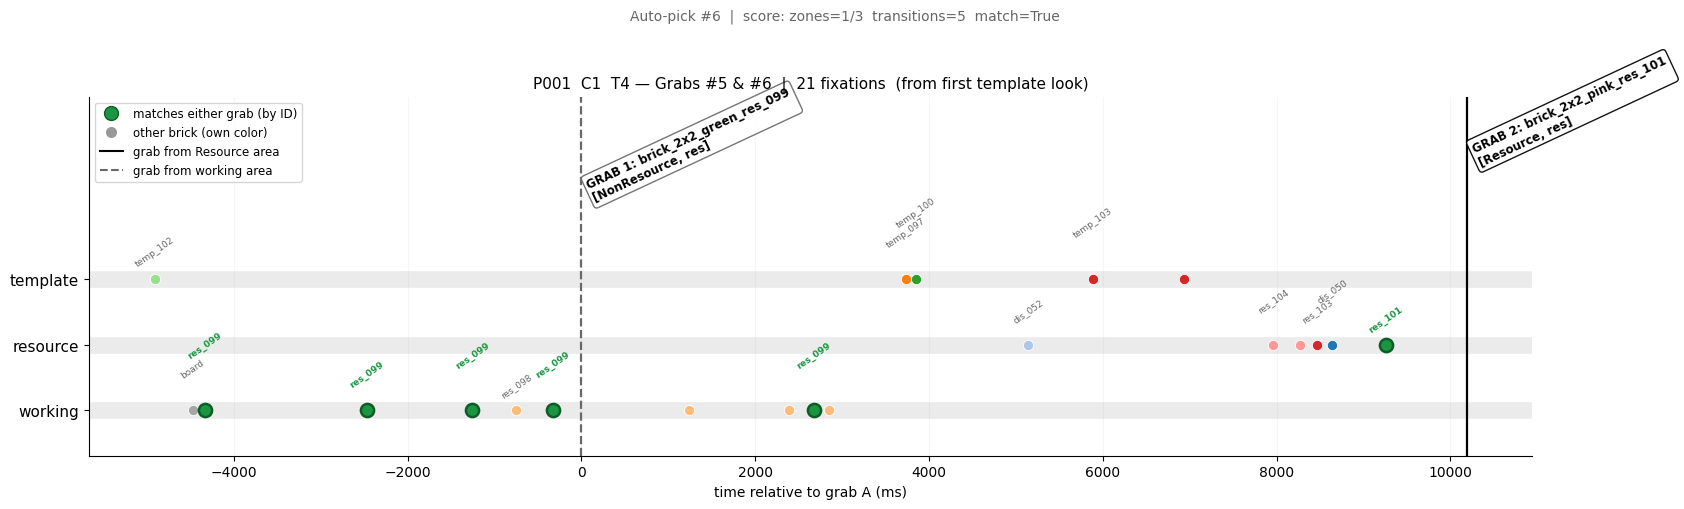

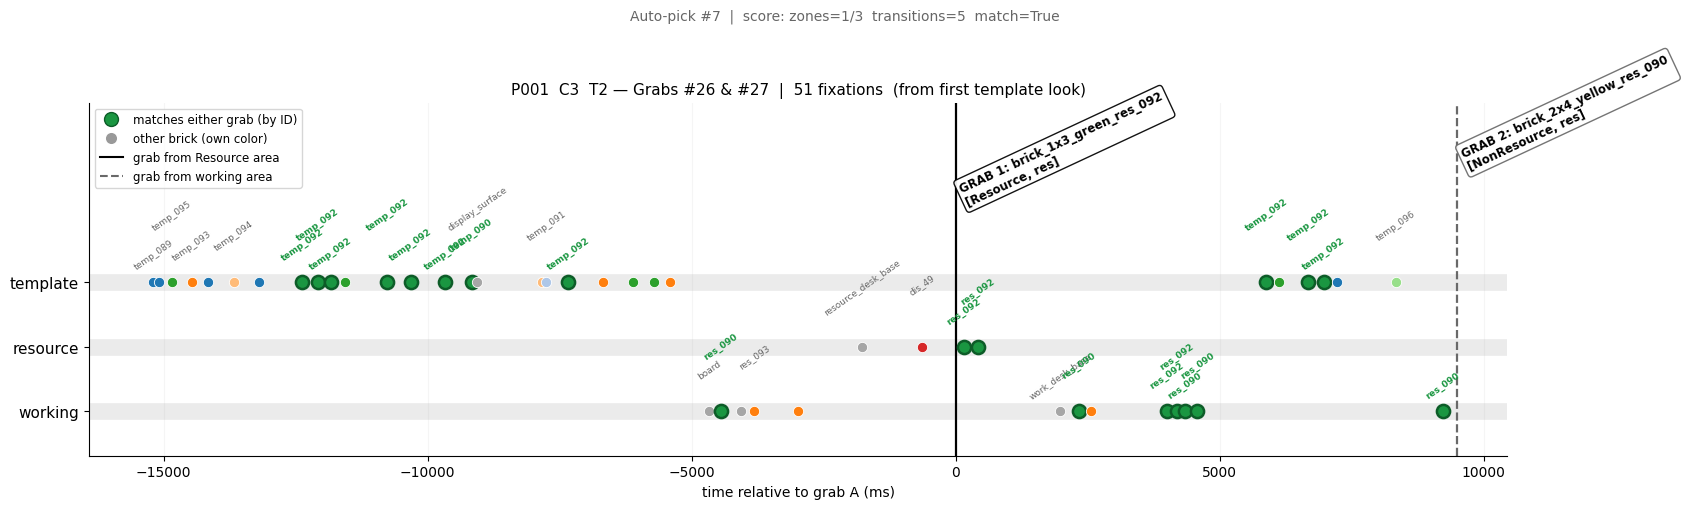

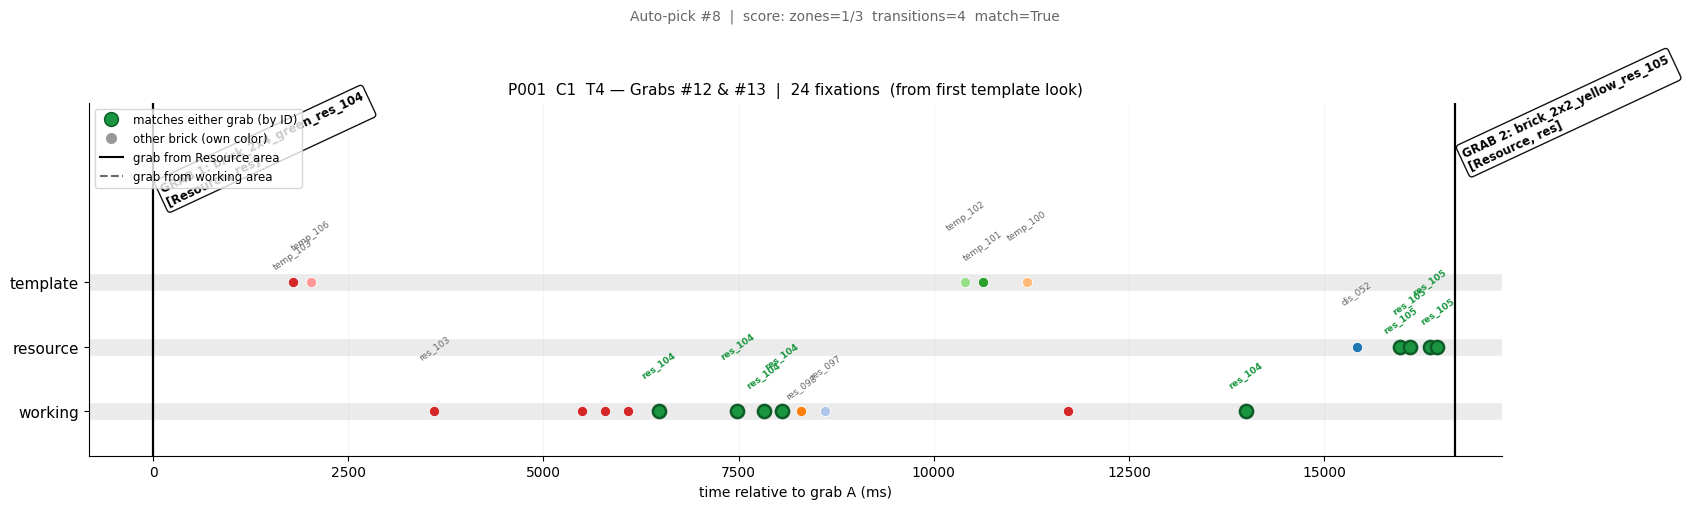

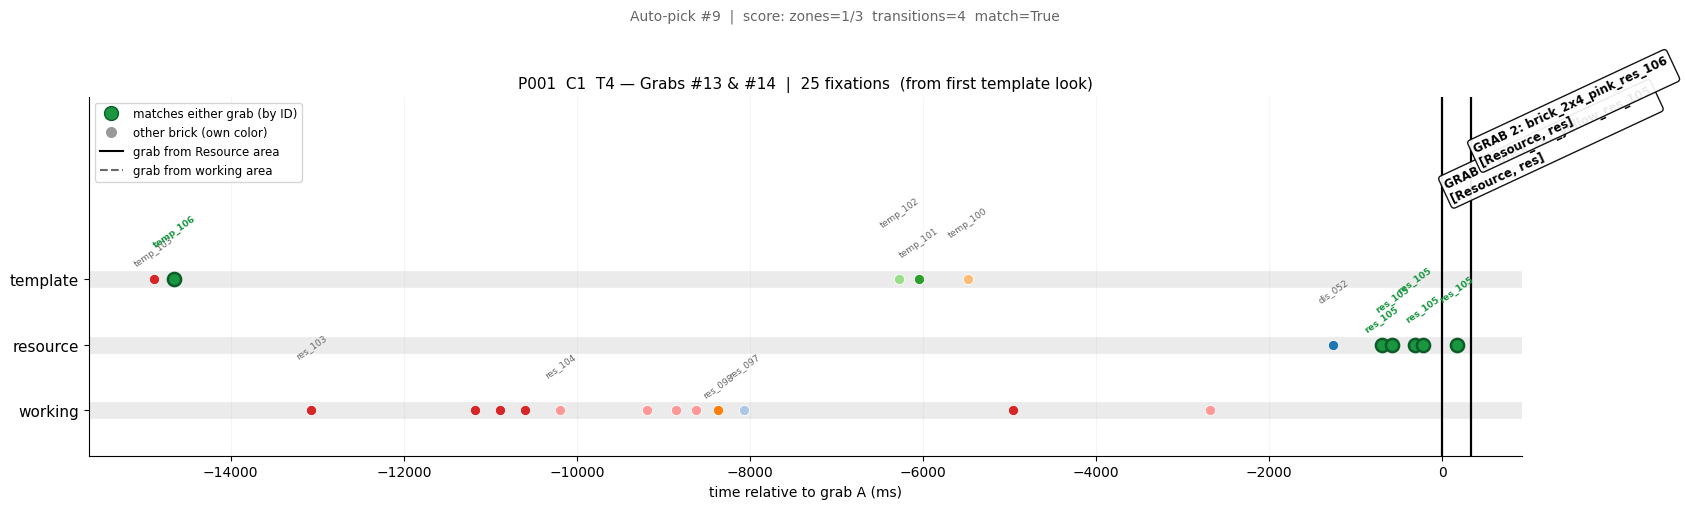

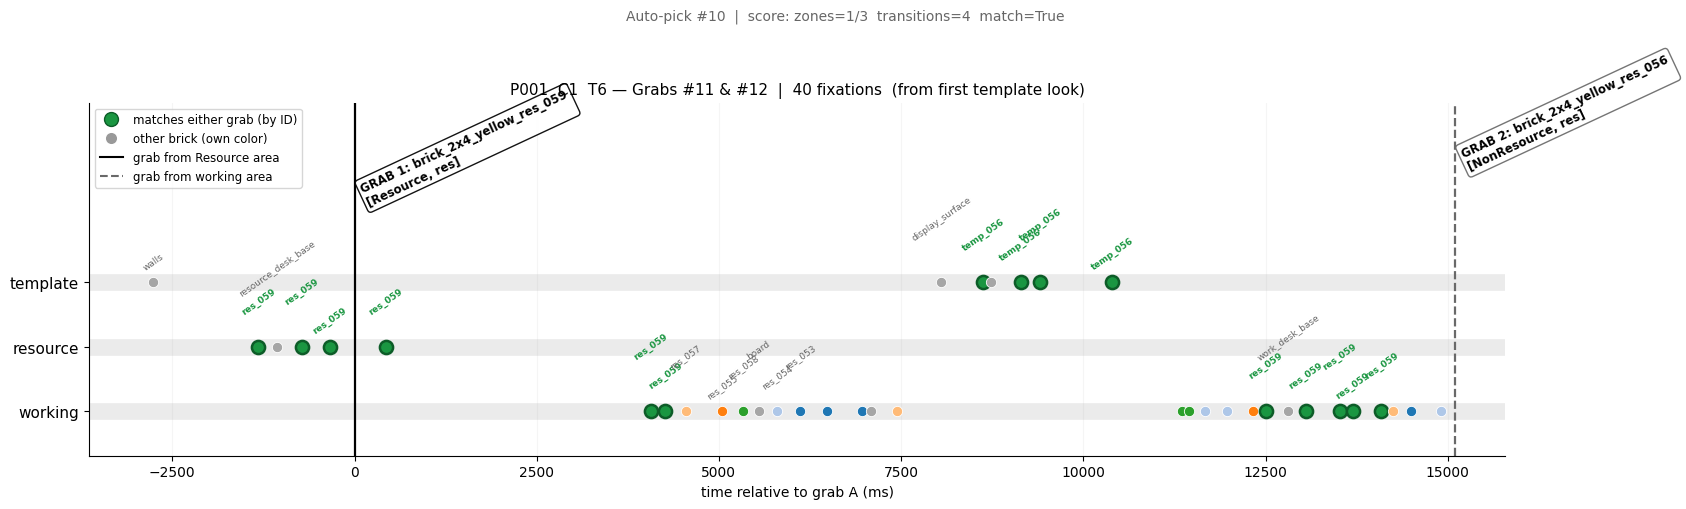

In [81]:
# ── Cell C2: auto-pick & plot zone-rich pairs from ALL grabs (any type/area) ──

N_PLOTS      = 10
WINDOW_MODE  = "template"
WINDOW_VALUE = 15000

import matplotlib.patches as mpatches

ZONE_LANES   = ["template", "resource", "working"]
ZONE_ALIAS   = {"model": "template", "resource": "resource", "working": "working"}
MATCH_COLOR  = "#1a9641"
MATCH_EDGE   = "#0d5c28"
palette      = plt.cm.tab20.colors

AREA_STYLE = {"Resource": ("black", "-"), "NonResource": ("dimgray", "--")}

def _short_id(s):
    if pd.isna(s): return None
    m = re.search(r"_(res|temp|dis)_(\d+)$", str(s)) or \
        re.match(r"^(res|temp|dis)_(\d+)$", str(s))
    return m.group(2) if m else None

def _gtype(name):
    if pd.isna(name): return None
    m = re.search(r"_(res|temp|dis)_\d+$", str(name))
    return m.group(1) if m else None

def get_window(trial_fix, gA, gB, mode, value):
    tA, tB = gA["grab_start_time_ms"], gB["grab_start_time_ms"]
    all_before = trial_fix[trial_fix["end_time_ms"] <= tB].sort_values("end_time_ms")
    if mode == "template":
        prevA      = gA["prev_grab_start_time_ms"]
        lo         = prevA if pd.notna(prevA) else -np.inf
        after_prev = all_before[all_before["end_time_ms"] > lo]
        temp_after = after_prev[after_prev["zone_lane"] == "template"]
        t_start    = temp_after.iloc[0]["start_time_ms"] if not temp_after.empty else lo
        win = trial_fix[(trial_fix["end_time_ms"] >= t_start) &
                        (trial_fix["end_time_ms"] <= tB)].sort_values("end_time_ms").reset_index(drop=True)
        desc = "from first template look"
    elif mode == "time":
        win  = all_before[all_before["end_time_ms"] >= tA - value].reset_index(drop=True)
        desc = f"last {value:,} ms"
    elif mode == "nfix":
        win  = all_before.tail(value).reset_index(drop=True)
        desc = f"last {value} fixations"
    return win, desc

def score_pair(win, match_ids):
    zones      = set(win["zone_lane"].dropna())
    n_zones    = len(zones & {"template","resource","working"})
    all_three  = int(n_zones == 3)
    lane_seq   = win["zone_lane"].dropna().tolist()
    transitions = sum(1 for a,b in zip(lane_seq, lane_seq[1:]) if a != b)
    has_match  = int(any(_short_id(x) in match_ids for x in win["dominant_group"]))
    return (all_three, transitions, has_match)

# ── scan EVERY consecutive pair of grabs in every trial (all types/areas) ────
seg_grabs = grab_events_all.copy()

candidates = []
for (pid, cond, trial), tg in seg_grabs.groupby(["participant_id","condition_number","trial_number"]):
    tg = tg.sort_values("grab_start_time_ms").reset_index(drop=True)
    tf = all_fix_runs_z[
        (all_fix_runs_z["participant_id"]   == pid) &
        (all_fix_runs_z["condition_number"] == cond) &
        (all_fix_runs_z["trial_number"]     == trial)
    ].copy()
    tf["zone_lane"] = tf["fixation_area"].map(ZONE_ALIAS)

    # every consecutive pair (i, i+1) — overlapping, not skipping by 2
    for i in range(len(tg) - 1):
        gA_, gB_    = tg.iloc[i], tg.iloc[i+1]
        idA_, idB_  = _short_id(gA_["grabbed_name"]), _short_id(gB_["grabbed_name"])
        mids        = {x for x in (idA_, idB_) if x}
        win_, _     = get_window(tf, gA_, gB_, WINDOW_MODE, WINDOW_VALUE)
        if len(win_) < 3: continue
        s = score_pair(win_, mids)
        candidates.append((s, pid, cond, trial, i, gA_, gB_, tf, win_))

candidates.sort(key=lambda x: x[0], reverse=True)
top = candidates[:N_PLOTS]

if not top:
    print("No valid pairs found — try loosening WINDOW_MODE or check all_fix_runs_z.")
else:
    print(f"Top {len(top)} pairs (all_three_zones, transitions, has_match):")
    for rank, (s, pid, cond, trial, pi, gA_, gB_, tf_, win_) in enumerate(top):
        print(f"  #{rank+1}  P{pid} C{int(cond)} T{int(trial)} "
              f"grabs {int(gA_['grab_idx_in_trial'])}&{int(gB_['grab_idx_in_trial'])}  "
              f"score={s}  fixations={len(win_)}  "
              f"[{gA_['grab_start_area']},{gA_['grabbed_type']}] -> "
              f"[{gB_['grab_start_area']},{gB_['grabbed_type']}]")

    for rank, (s, pid, cond, trial, pi, gA_, gB_, tf_, win_) in enumerate(top):
        tA, tB    = gA_["grab_start_time_ms"], gB_["grab_start_time_ms"]
        idA_, idB_= _short_id(gA_["grabbed_name"]), _short_id(gB_["grabbed_name"])
        match_ids = {x for x in (idA_, idB_) if x}
        win, desc = get_window(tf_, gA_, gB_, WINDOW_MODE, WINDOW_VALUE)

        nonmatch_ids = sorted({_short_id(x) for x in win["dominant_group"]
                               if _short_id(x) not in match_ids and _short_id(x) is not None})
        color_for    = {bid: palette[k % len(palette)] for k, bid in enumerate(nonmatch_ids)}

        def dot_color(fid):
            return MATCH_COLOR if fid in match_ids else color_for.get(fid, "0.65")

        tag = f"auto{rank+1}_P{pid}_C{int(cond)}_T{int(trial)}_g{int(gA_['grab_idx_in_trial'])}-{int(gB_['grab_idx_in_trial'])}_{WINDOW_MODE}"

        # ── Plot 1: timeline ─────────────────────────────────────────────────
        lane_y    = {z: i for i, z in enumerate(reversed(ZONE_LANES))}
        Y_OFFSETS = [8, 22, 36, 15, 29]
        labeled   = set()

        fig1, ax = plt.subplots(figsize=(17, 5))
        fig1.suptitle(f"Auto-pick #{rank+1}  |  score: zones={s[0]}/3  transitions={s[1]}  match={bool(s[2])}",
                      fontsize=10, color="0.4", y=1.01)

        for z in ZONE_LANES:
            ax.axhline(lane_y[z], color="0.92", linewidth=12, zorder=0)

        for i, (_, fx) in enumerate(win.iterrows()):
            zone = fx["zone_lane"]
            if zone not in lane_y: continue
            t_rel    = fx["end_time_ms"] - tA
            fid      = _short_id(fx["dominant_group"])
            color    = dot_color(fid)
            is_match = fid in match_ids

            ax.scatter(t_rel, lane_y[zone], color=color,
                       s=90 if is_match else 55, zorder=3,
                       edgecolor=MATCH_EDGE if is_match else "white",
                       linewidth=1.8 if is_match else 0.6)

            obj_key = (zone, str(fx["dominant_group"]))
            if is_match or obj_key not in labeled:
                labeled.add(obj_key)
                yoff = Y_OFFSETS[i % len(Y_OFFSETS)]
                ax.annotate(str(fx["dominant_group"]),
                            (t_rel, lane_y[zone]),
                            textcoords="offset points", xytext=(0, yoff),
                            ha="center", va="bottom", rotation=35, fontsize=6.5,
                            fontweight="bold" if is_match else "normal",
                            color=MATCH_COLOR if is_match else "0.4")

        # ── grab lines: styled by area, labeled with [area, type] ────────────
        for (g_, t_, lbl_num, ypos_) in [
                (gA_, tA, 1, len(ZONE_LANES) + 0.15),
                (gB_, tB, 2, len(ZONE_LANES) + 0.70)]:
            t_rel = t_ - tA
            color, ls = AREA_STYLE.get(g_["grab_start_area"], ("gray", ":"))
            lbl = f"GRAB {lbl_num}: {g_['grabbed_name']}\n[{g_['grab_start_area']}, {g_['grabbed_type']}]"
            ax.axvline(t_rel, color=color, linewidth=1.6, linestyle=ls, zorder=2)
            ax.text(t_rel + abs(tB - tA) * 0.004, ypos_, lbl,
                    ha="left", va="bottom", fontsize=8.5, fontweight="bold", rotation=25,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.92))

        ax.set_yticks([lane_y[z] for z in ZONE_LANES])
        ax.set_yticklabels(ZONE_LANES, fontsize=11)
        ax.set_ylim(-0.7, len(ZONE_LANES) + 1.8)
        ax.set_xlabel("time relative to grab A (ms)", fontsize=10)
        ax.set_title(f"P{pid}  C{int(cond)}  T{int(trial)} — "
                     f"Grabs #{int(gA_['grab_idx_in_trial'])} & #{int(gB_['grab_idx_in_trial'])}"
                     f"  |  {len(win)} fixations  ({desc})", fontsize=11)
        ax.spines[["top","right"]].set_visible(False)
        ax.grid(axis="x", alpha=0.12)
        ax.legend(handles=[
            plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=MATCH_COLOR,
                       markeredgecolor=MATCH_EDGE, markersize=10, label="matches either grab (by ID)"),
            plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="0.6",
                       markersize=9, label="other brick (own color)"),
            plt.Line2D([0],[0], color="black", linestyle="-", label="grab from Resource area"),
            plt.Line2D([0],[0], color="dimgray", linestyle="--", label="grab from working area"),
        ], loc="upper left", fontsize=8.5, frameon=True)
        plt.tight_layout()
        plt.savefig(f"plot1_timeline_{tag}.png", dpi=150, bbox_inches="tight")
        plt.show()

Top 10 pairs (all_three_zones, transitions, has_match):
  #1  P001 C1 T4 grabs 12&13  score=(1, 4, 1)  fixations=24  [Resource,res] -> [Resource,res]
  #2  P001 C1 T4 grabs 13&14  score=(1, 4, 1)  fixations=25  [Resource,res] -> [Resource,res]
  #3  P001 C2 T5 grabs 18&19  score=(1, 4, 1)  fixations=51  [Resource,res] -> [Resource,res]
  #4  P001 C3 T4 grabs 9&10  score=(1, 4, 1)  fixations=67  [Resource,res] -> [Resource,res]
  #5  P001 C1 T3 grabs 7&8  score=(1, 3, 1)  fixations=27  [Resource,dis] -> [Resource,res]
  #6  P001 C3 T2 grabs 35&36  score=(1, 3, 1)  fixations=30  [Resource,res] -> [Resource,res]
  #7  P001 C1 T3 grabs 4&5  score=(1, 2, 1)  fixations=13  [Resource,res] -> [Resource,res]
  #8  P001 C1 T3 grabs 6&7  score=(1, 2, 1)  fixations=23  [Resource,res] -> [Resource,dis]
  #9  P001 C1 T6 grabs 5&6  score=(1, 2, 1)  fixations=16  [Resource,res] -> [Resource,dis]
  #10  P001 C2 T2 grabs 7&8  score=(1, 2, 1)  fixations=39  [Resource,res] -> [Resource,res]


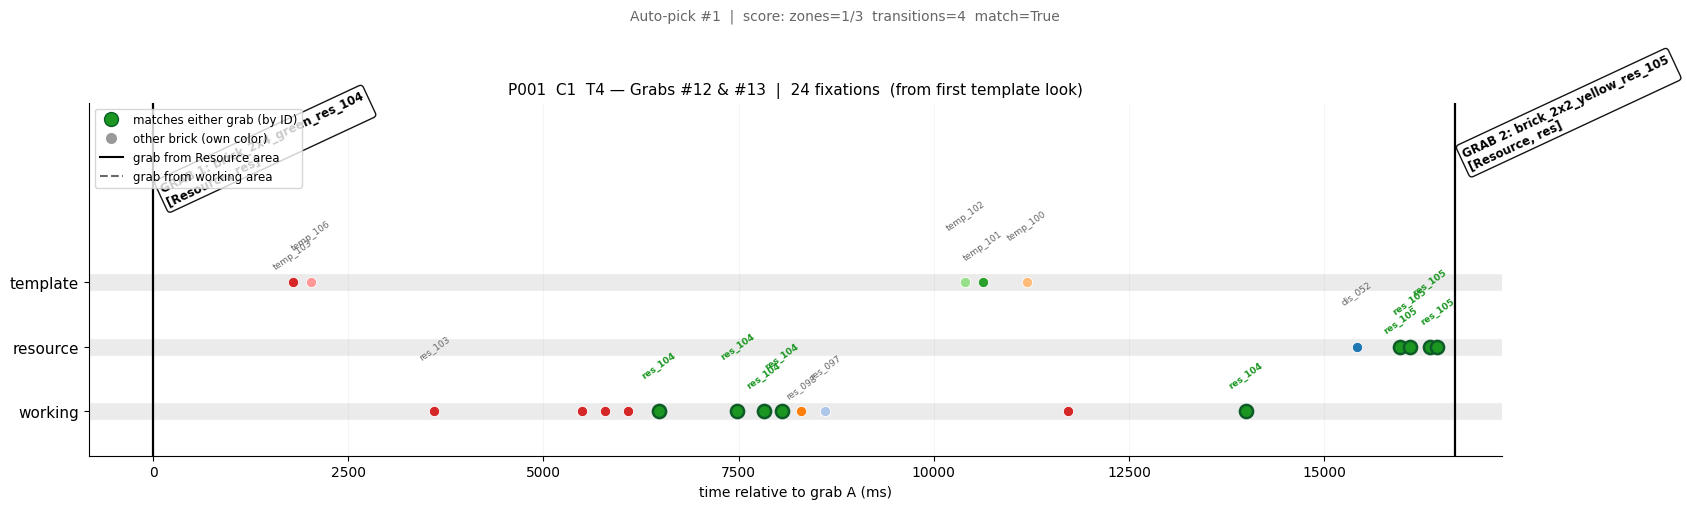

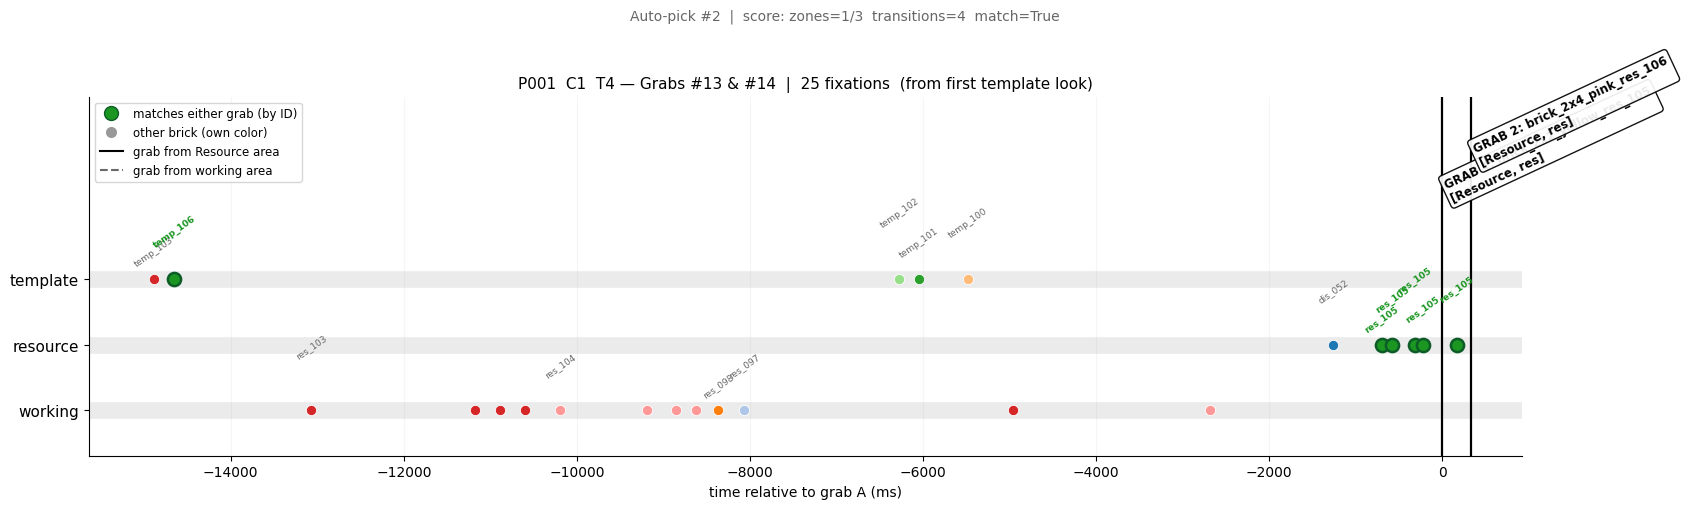

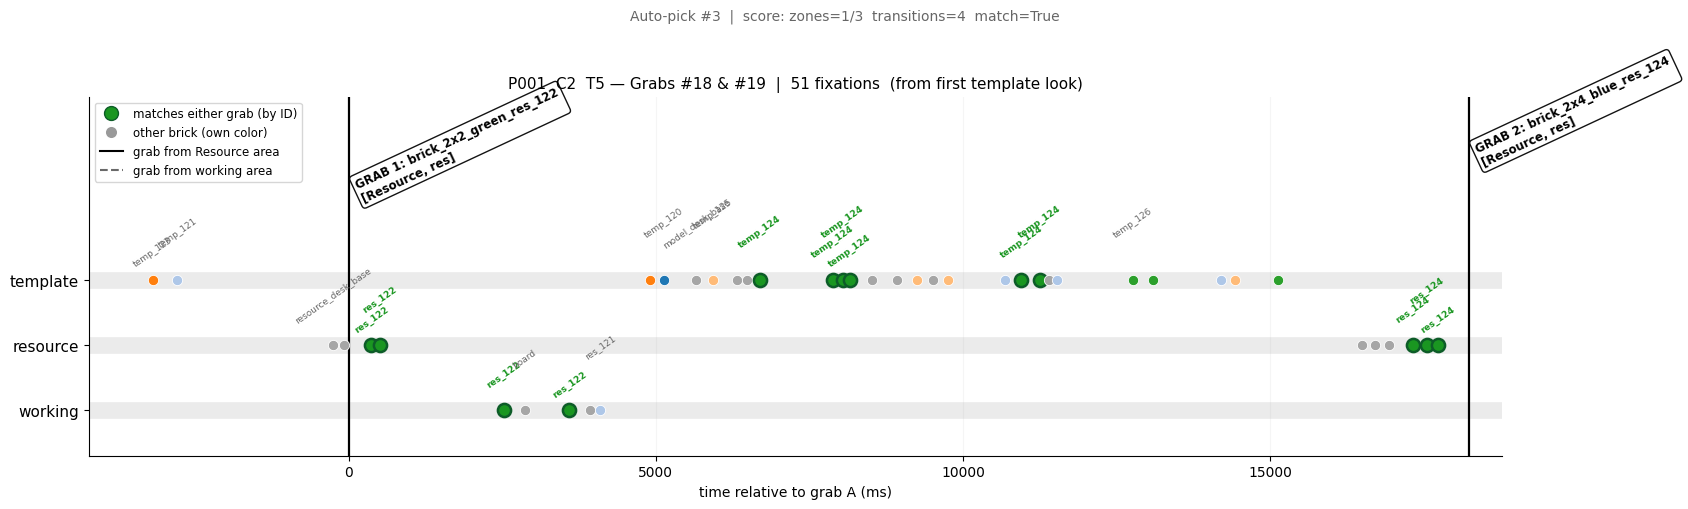

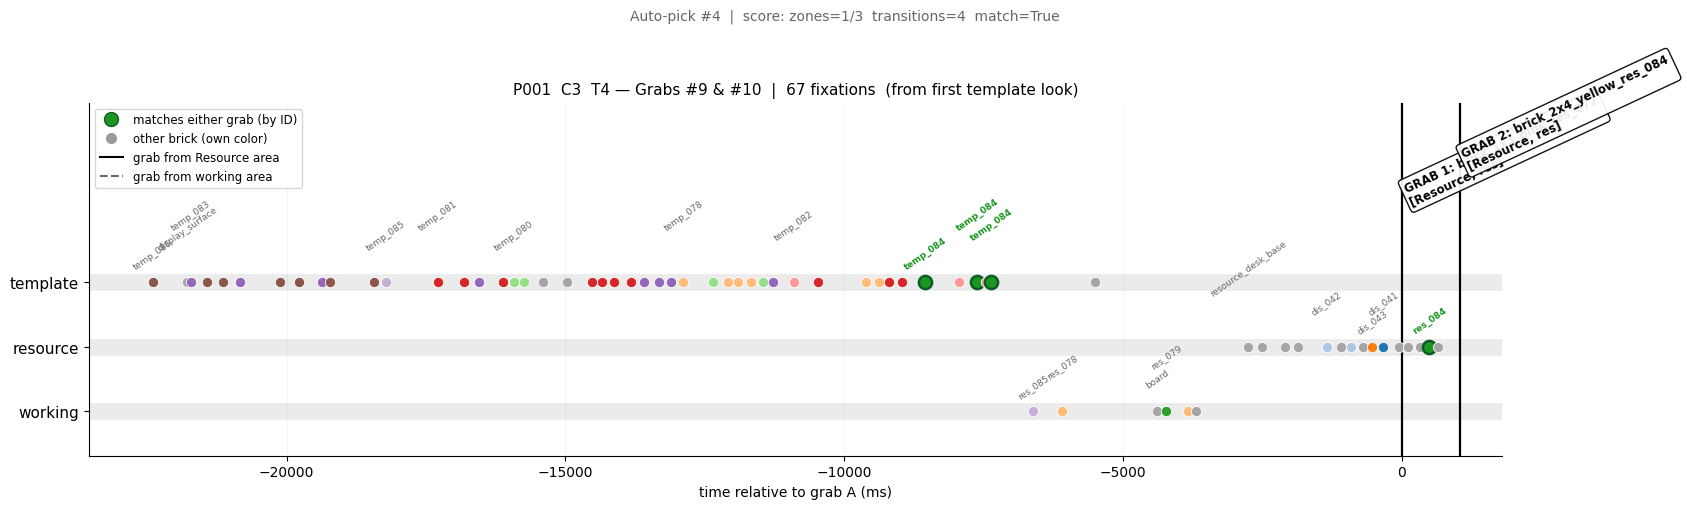

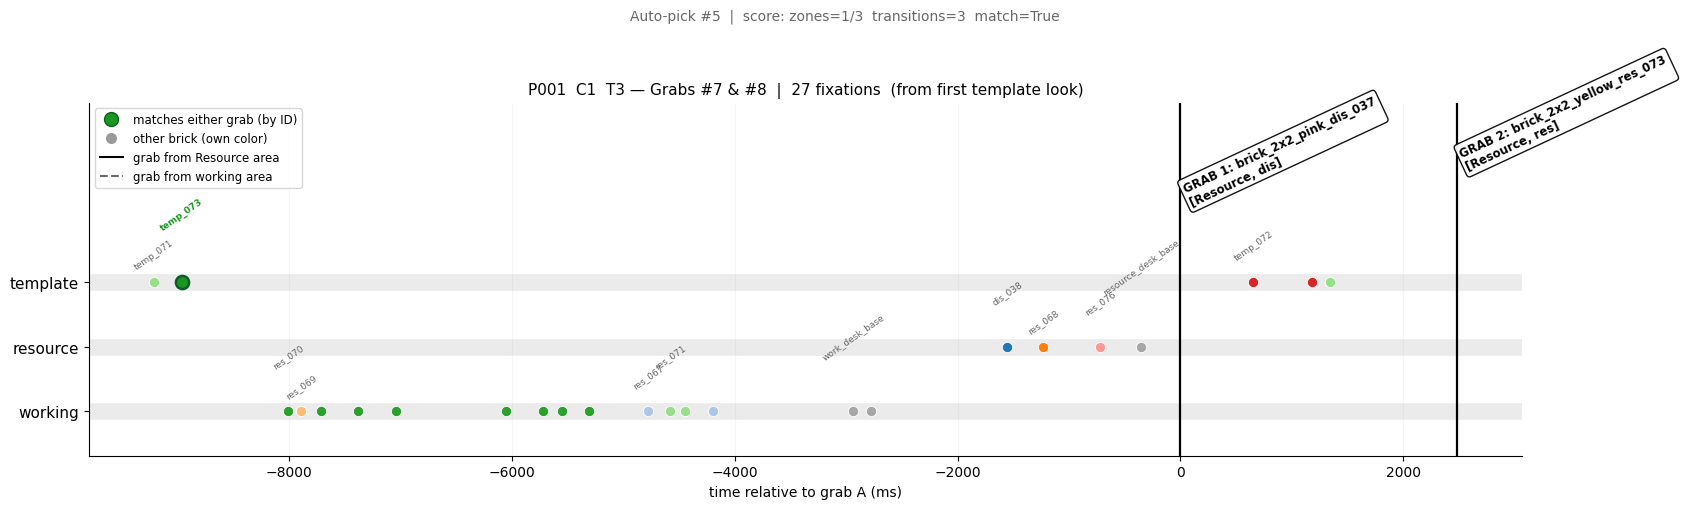

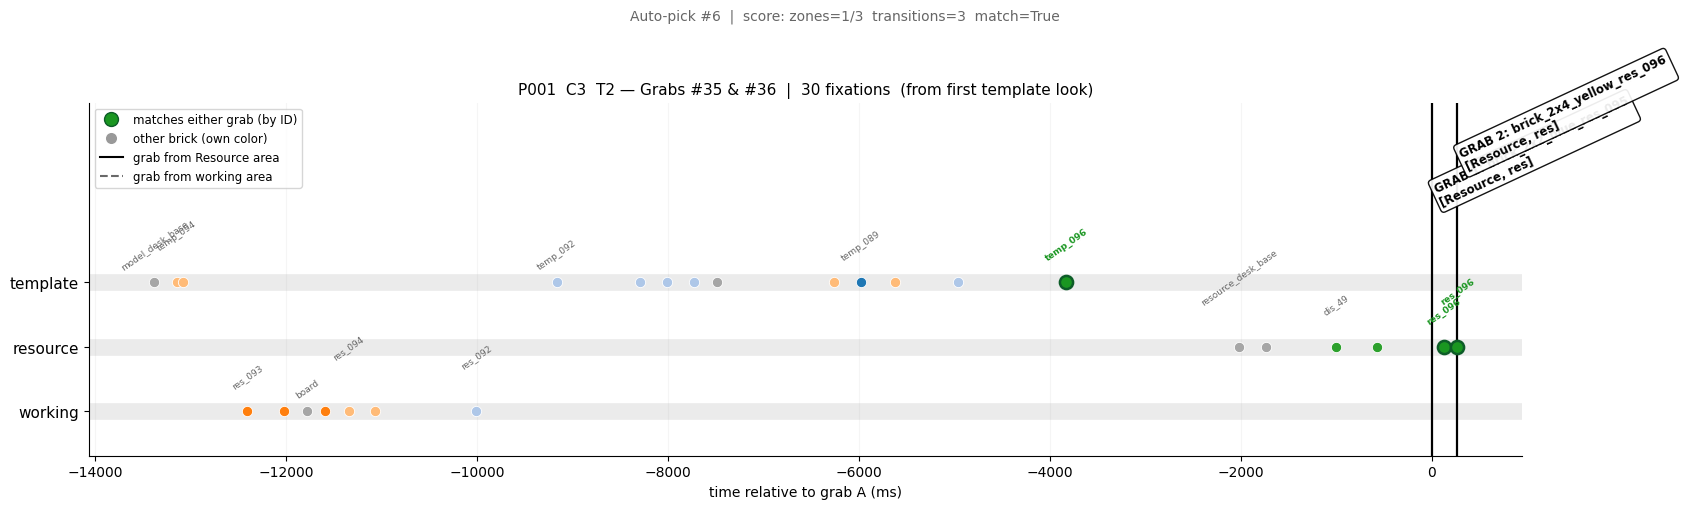

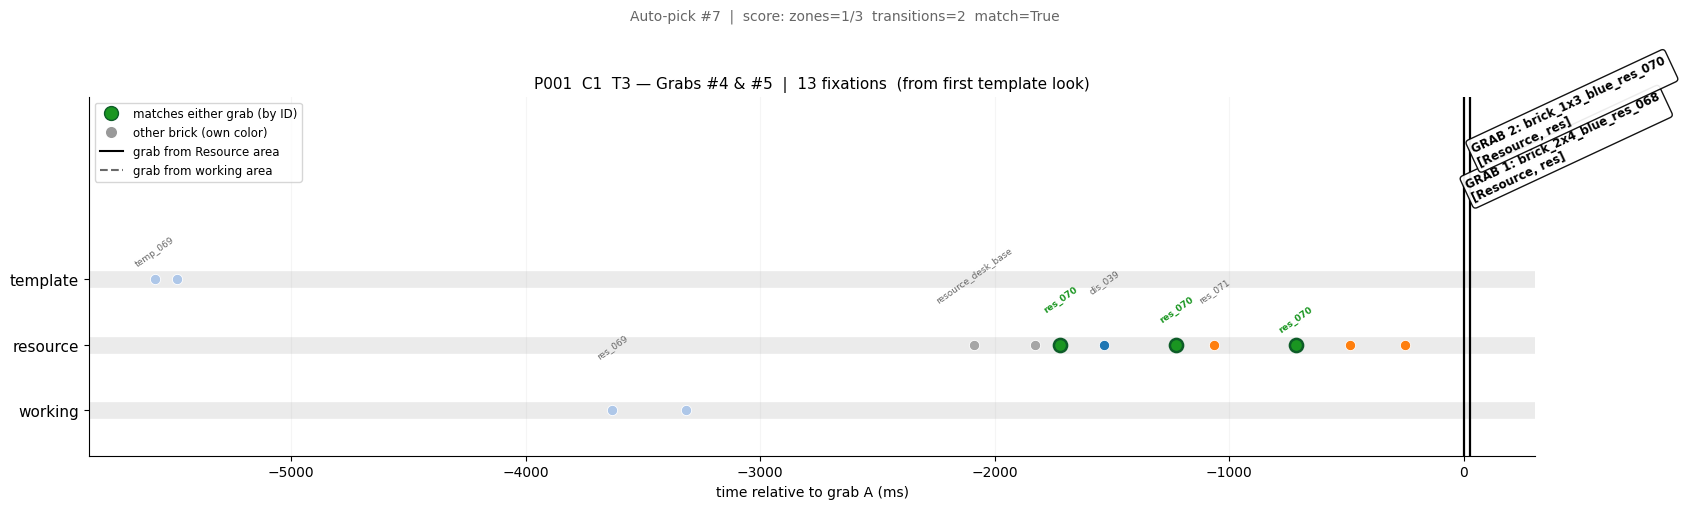

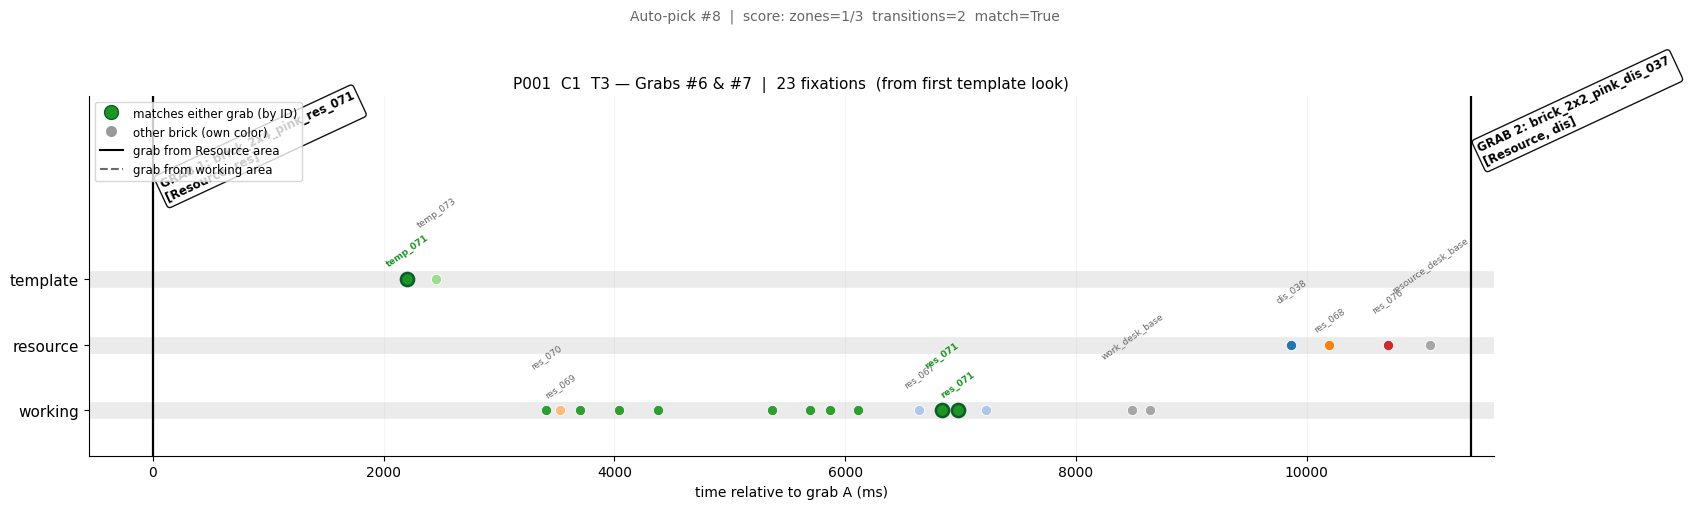

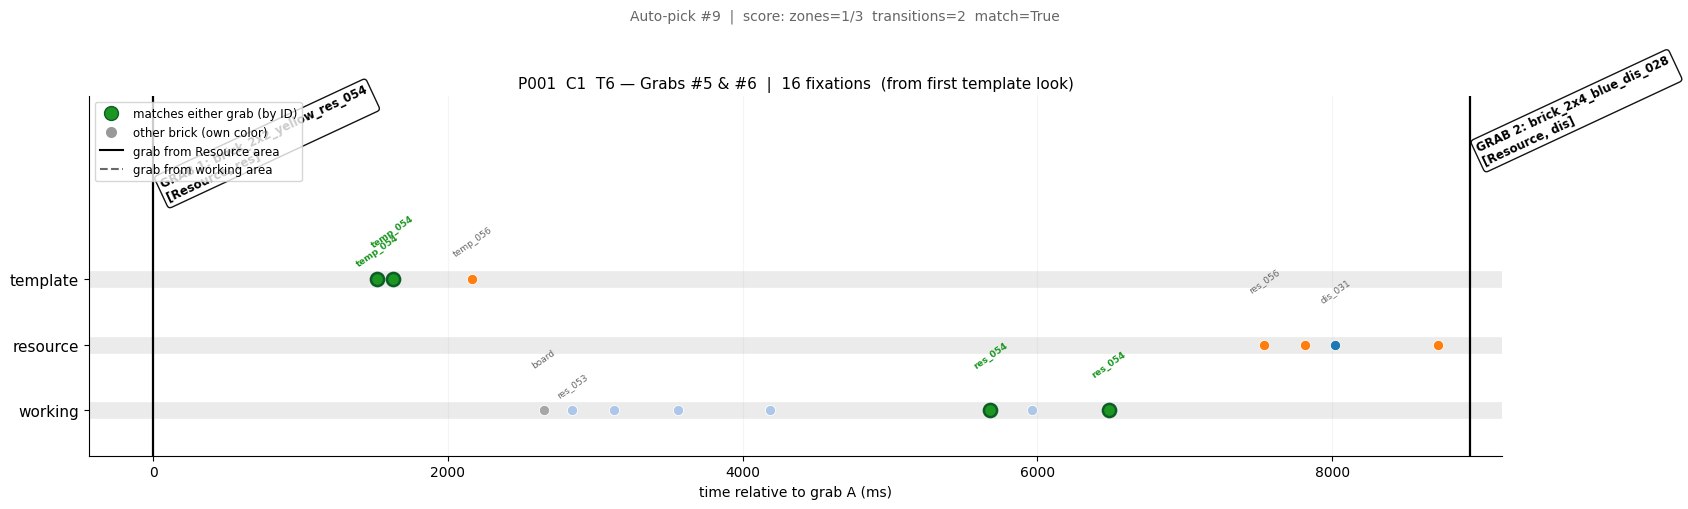

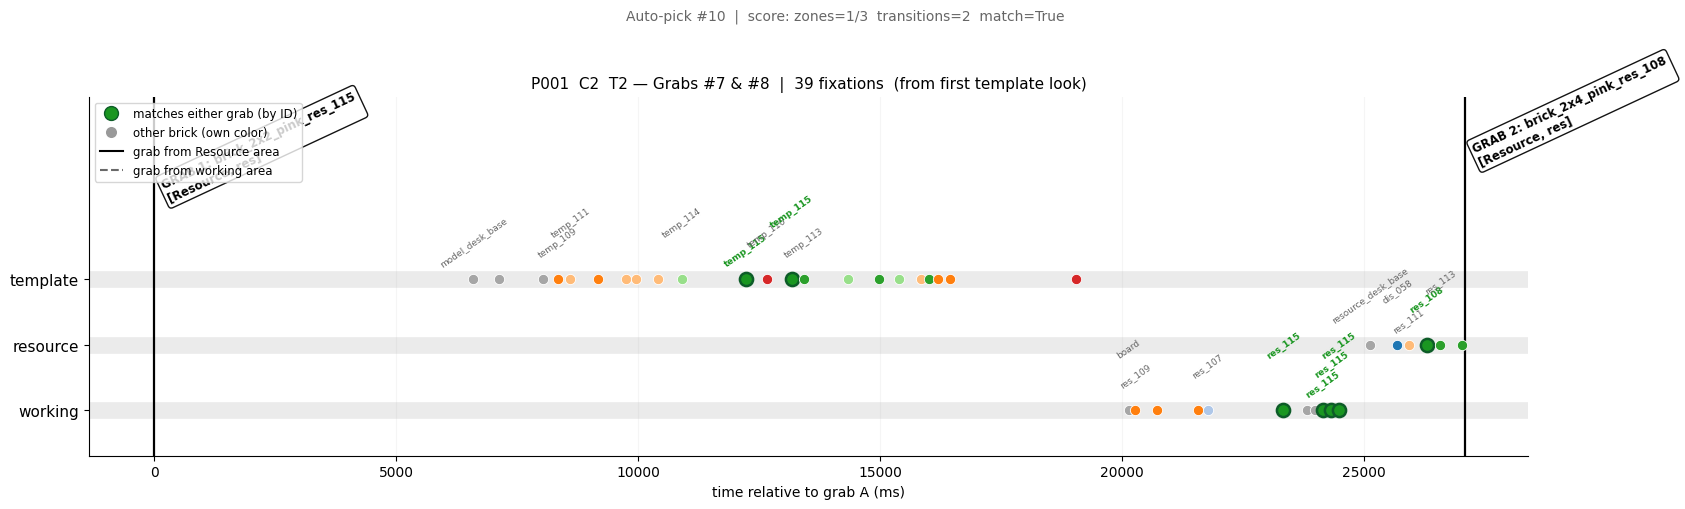

In [83]:
# ── Cell C2: auto-pick & plot pairs of CONSECUTIVE RESOURCE-AREA grabs ───────

N_PLOTS      = 10
WINDOW_MODE  = "template"
WINDOW_VALUE = 15000

import matplotlib.patches as mpatches

ZONE_LANES   = ["template", "resource", "working"]
ZONE_ALIAS   = {"model": "template", "resource": "resource", "working": "working"}
MATCH_COLOR  = "#1a9621"
MATCH_EDGE   = "#0d5c28"
palette      = plt.cm.tab20.colors

AREA_STYLE = {"Resource": ("black", "-"), "NonResource": ("dimgray", "--")}

def _short_id(s):
    if pd.isna(s): return None
    m = re.search(r"_(res|temp|dis)_(\d+)$", str(s)) or \
        re.match(r"^(res|temp|dis)_(\d+)$", str(s))
    return m.group(2) if m else None

def _gtype(name):
    if pd.isna(name): return None
    m = re.search(r"_(res|temp|dis)_\d+$", str(name))
    return m.group(1) if m else None

def get_window(trial_fix, gA, gB, mode, value):
    tA, tB = gA["grab_start_time_ms"], gB["grab_start_time_ms"]
    all_before = trial_fix[trial_fix["end_time_ms"] <= tB].sort_values("end_time_ms")
    if mode == "template":
        prevA      = gA["prev_grab_start_time_ms"]
        lo         = prevA if pd.notna(prevA) else -np.inf
        after_prev = all_before[all_before["end_time_ms"] > lo]
        temp_after = after_prev[after_prev["zone_lane"] == "template"]
        t_start    = temp_after.iloc[0]["start_time_ms"] if not temp_after.empty else lo
        win = trial_fix[(trial_fix["end_time_ms"] >= t_start) &
                        (trial_fix["end_time_ms"] <= tB)].sort_values("end_time_ms").reset_index(drop=True)
        desc = "from first template look"
    elif mode == "time":
        win  = all_before[all_before["end_time_ms"] >= tA - value].reset_index(drop=True)
        desc = f"last {value:,} ms"
    elif mode == "nfix":
        win  = all_before.tail(value).reset_index(drop=True)
        desc = f"last {value} fixations"
    return win, desc

def score_pair(win, match_ids):
    zones      = set(win["zone_lane"].dropna())
    n_zones    = len(zones & {"template","resource","working"})
    all_three  = int(n_zones == 3)
    lane_seq   = win["zone_lane"].dropna().tolist()
    transitions = sum(1 for a,b in zip(lane_seq, lane_seq[1:]) if a != b)
    has_match  = int(any(_short_id(x) in match_ids for x in win["dominant_group"]))
    return (all_three, transitions, has_match)

# ── scan consecutive pairs where BOTH grabs are from the resource area ──────
seg_grabs = grab_events_all.copy()

candidates = []
for (pid, cond, trial), tg in seg_grabs.groupby(["participant_id","condition_number","trial_number"]):
    tg = tg.sort_values("grab_start_time_ms").reset_index(drop=True)
    tf = all_fix_runs_z[
        (all_fix_runs_z["participant_id"]   == pid) &
        (all_fix_runs_z["condition_number"] == cond) &
        (all_fix_runs_z["trial_number"]     == trial)
    ].copy()
    tf["zone_lane"] = tf["fixation_area"].map(ZONE_ALIAS)

    for i in range(len(tg) - 1):
        gA_, gB_ = tg.iloc[i], tg.iloc[i+1]

        # only keep pairs where BOTH grabs are from the resource area
        if gA_["grab_start_area"] != "Resource" or gB_["grab_start_area"] != "Resource":
            continue

        idA_, idB_  = _short_id(gA_["grabbed_name"]), _short_id(gB_["grabbed_name"])
        mids        = {x for x in (idA_, idB_) if x}
        win_, _     = get_window(tf, gA_, gB_, WINDOW_MODE, WINDOW_VALUE)
        if len(win_) < 3: continue
        s = score_pair(win_, mids)
        candidates.append((s, pid, cond, trial, i, gA_, gB_, tf, win_))

candidates.sort(key=lambda x: x[0], reverse=True)
top = candidates[:N_PLOTS]

if not top:
    print("No valid pairs found — try loosening WINDOW_MODE or check all_fix_runs_z.")
else:
    print(f"Top {len(top)} pairs (all_three_zones, transitions, has_match):")
    for rank, (s, pid, cond, trial, pi, gA_, gB_, tf_, win_) in enumerate(top):
        print(f"  #{rank+1}  P{pid} C{int(cond)} T{int(trial)} "
              f"grabs {int(gA_['grab_idx_in_trial'])}&{int(gB_['grab_idx_in_trial'])}  "
              f"score={s}  fixations={len(win_)}  "
              f"[{gA_['grab_start_area']},{gA_['grabbed_type']}] -> "
              f"[{gB_['grab_start_area']},{gB_['grabbed_type']}]")

    for rank, (s, pid, cond, trial, pi, gA_, gB_, tf_, win_) in enumerate(top):
        tA, tB    = gA_["grab_start_time_ms"], gB_["grab_start_time_ms"]
        idA_, idB_= _short_id(gA_["grabbed_name"]), _short_id(gB_["grabbed_name"])
        match_ids = {x for x in (idA_, idB_) if x}
        win, desc = get_window(tf_, gA_, gB_, WINDOW_MODE, WINDOW_VALUE)

        nonmatch_ids = sorted({_short_id(x) for x in win["dominant_group"]
                               if _short_id(x) not in match_ids and _short_id(x) is not None})
        color_for    = {bid: palette[k % len(palette)] for k, bid in enumerate(nonmatch_ids)}

        def dot_color(fid):
            return MATCH_COLOR if fid in match_ids else color_for.get(fid, "0.65")

        tag = f"auto{rank+1}_P{pid}_C{int(cond)}_T{int(trial)}_g{int(gA_['grab_idx_in_trial'])}-{int(gB_['grab_idx_in_trial'])}_{WINDOW_MODE}"

        # ── Plot 1: timeline ─────────────────────────────────────────────────
        lane_y    = {z: i for i, z in enumerate(reversed(ZONE_LANES))}
        Y_OFFSETS = [8, 22, 36, 15, 29]
        labeled   = set()

        fig1, ax = plt.subplots(figsize=(17, 5))
        fig1.suptitle(f"Auto-pick #{rank+1}  |  score: zones={s[0]}/3  transitions={s[1]}  match={bool(s[2])}",
                      fontsize=10, color="0.4", y=1.01)

        for z in ZONE_LANES:
            ax.axhline(lane_y[z], color="0.92", linewidth=12, zorder=0)

        for i, (_, fx) in enumerate(win.iterrows()):
            zone = fx["zone_lane"]
            if zone not in lane_y: continue
            t_rel    = fx["end_time_ms"] - tA
            fid      = _short_id(fx["dominant_group"])
            color    = dot_color(fid)
            is_match = fid in match_ids

            ax.scatter(t_rel, lane_y[zone], color=color,
                       s=90 if is_match else 55, zorder=3,
                       edgecolor=MATCH_EDGE if is_match else "white",
                       linewidth=1.8 if is_match else 0.6)

            obj_key = (zone, str(fx["dominant_group"]))
            if is_match or obj_key not in labeled:
                labeled.add(obj_key)
                yoff = Y_OFFSETS[i % len(Y_OFFSETS)]
                ax.annotate(str(fx["dominant_group"]),
                            (t_rel, lane_y[zone]),
                            textcoords="offset points", xytext=(0, yoff),
                            ha="center", va="bottom", rotation=35, fontsize=6.5,
                            fontweight="bold" if is_match else "normal",
                            color=MATCH_COLOR if is_match else "0.4")

        # ── grab lines: styled by area, labeled with [area, type] ────────────
        for (g_, t_, lbl_num, ypos_) in [
                (gA_, tA, 1, len(ZONE_LANES) + 0.15),
                (gB_, tB, 2, len(ZONE_LANES) + 0.70)]:
            t_rel = t_ - tA
            color, ls = AREA_STYLE.get(g_["grab_start_area"], ("gray", ":"))
            lbl = f"GRAB {lbl_num}: {g_['grabbed_name']}\n[{g_['grab_start_area']}, {g_['grabbed_type']}]"
            ax.axvline(t_rel, color=color, linewidth=1.6, linestyle=ls, zorder=2)
            ax.text(t_rel + abs(tB - tA) * 0.004, ypos_, lbl,
                    ha="left", va="bottom", fontsize=8.5, fontweight="bold", rotation=25,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.92))

        ax.set_yticks([lane_y[z] for z in ZONE_LANES])
        ax.set_yticklabels(ZONE_LANES, fontsize=11)
        ax.set_ylim(-0.7, len(ZONE_LANES) + 1.8)
        ax.set_xlabel("time relative to grab A (ms)", fontsize=10)
        ax.set_title(f"P{pid}  C{int(cond)}  T{int(trial)} — "
                     f"Grabs #{int(gA_['grab_idx_in_trial'])} & #{int(gB_['grab_idx_in_trial'])}"
                     f"  |  {len(win)} fixations  ({desc})", fontsize=11)
        ax.spines[["top","right"]].set_visible(False)
        ax.grid(axis="x", alpha=0.12)
        ax.legend(handles=[
            plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=MATCH_COLOR,
                       markeredgecolor=MATCH_EDGE, markersize=10, label="matches either grab (by ID)"),
            plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="0.6",
                       markersize=9, label="other brick (own color)"),
            plt.Line2D([0],[0], color="black", linestyle="-", label="grab from Resource area"),
            plt.Line2D([0],[0], color="dimgray", linestyle="--", label="grab from working area"),
        ], loc="upper left", fontsize=8.5, frameon=True)
        plt.tight_layout()
        plt.savefig(f"plot1_timeline_{tag}.png", dpi=150, bbox_inches="tight")
        plt.show()

In [86]:
# ── detect ALL runs (fixation + saccade), with real durations and zones ─────

def detect_all_runs(df, dominance_threshold=0.50, min_duration_ms=0):
    """
    Like detect_fixation_runs, but keeps BOTH 'fixation' and 'saccade' runs,
    with their own start/end times, dominant hit-object group, and mean
    object_position (for zone classification).
    """
    block_cols = ["participant_id", "condition_number", "trial_number"]
    df = df.copy().sort_values(block_cols + ["gaze_capture_time"])

    df["run_id"] = (
        (df["velocity_category"] != df["velocity_category"].shift())
        | (df["participant_id"]   != df["participant_id"].shift())
        | (df["condition_number"] != df["condition_number"].shift())
        | (df["trial_number"]     != df["trial_number"].shift())
    ).cumsum()

    results = []
    for run_id, grp in df.groupby("run_id", sort=True):
        category = grp["velocity_category"].iloc[0]
        if category not in ("fixation", "saccade"):
            continue

        duration_ms = grp["time_ms"].max() - grp["time_ms"].min()
        if duration_ms < min_duration_ms:
            continue

        looked = grp["hit_obj_group"].dropna()
        if len(looked) == 0:
            dominant, dominance, n_unique = None, np.nan, 0
        else:
            counts    = looked.value_counts()
            dominant  = counts.index[0]
            dominance = counts.iloc[0] / len(looked)
            n_unique  = looked.nunique()

        stable = (category == "fixation") and (dominance >= dominance_threshold)

        results.append({
            "run_id":           run_id,
            "category":         category,
            "participant_id":   grp["participant_id"].iloc[0],
            "condition_number": grp["condition_number"].iloc[0],
            "trial_number":     grp["trial_number"].iloc[0],
            "start_time_ms":    grp["time_ms"].min(),
            "end_time_ms":      grp["time_ms"].max(),
            "duration_ms":      duration_ms,
            "n_samples":        len(grp),
            "dominant_group":   dominant,
            "dominance_ratio":  dominance,
            "n_unique_groups":  n_unique,
            "stable":           stable,
            "mean_pos_x":       grp["object_position_x"].mean(),
            "mean_pos_z":       grp["object_position_z"].mean(),
        })

    return pd.DataFrame(results)


all_runs = detect_all_runs(prepared, dominance_threshold=DOMINANCE_THRESHOLD, min_duration_ms=0)

# classify zone for every run (fixation AND saccade) using its own mean position
all_runs["fixation_area"] = [
    classify_zone(x, z, zone_bboxes) if pd.notna(x) else "unknown"
    for x, z in zip(all_runs["mean_pos_x"], all_runs["mean_pos_z"])
]
all_runs["zone_lane"] = all_runs["fixation_area"].map(ZONE_ALIAS)

print(all_runs["category"].value_counts())
print(all_runs.groupby("category")["duration_ms"].describe())

category
fixation    9915
saccade     9898
Name: count, dtype: int64
           count        mean         std  min     25%       50%       75%  \
category                                                                    
fixation  9915.0  122.870266  235.663530  0.0  5.0001  24.99610  155.0219   
saccade   9898.0   53.373915   74.318705  0.0  5.0013  35.00625   60.0090   

                max  
category             
fixation  3480.4478  
saccade    900.1110  


Top 10 pairs (all_three_zones, transitions, has_match):
  #1  P001 C1 T4 grabs 12&13  score=(1, 9, 1)  runs=146  [Resource,res] -> [Resource,res]
  #2  P001 C1 T4 grabs 13&14  score=(1, 9, 1)  runs=149  [Resource,res] -> [Resource,res]
  #3  P001 C1 T3 grabs 6&7  score=(1, 7, 1)  runs=233  [Resource,res] -> [Resource,dis]
  #4  P001 C1 T3 grabs 7&8  score=(1, 7, 1)  runs=190  [Resource,dis] -> [Resource,res]
  #5  P001 C1 T3 grabs 9&10  score=(1, 6, 1)  runs=92  [Resource,dis] -> [Resource,res]
  #6  P001 C2 T5 grabs 1&2  score=(1, 5, 1)  runs=463  [Resource,res] -> [Resource,res]
  #7  P001 C2 T5 grabs 18&19  score=(1, 4, 1)  runs=230  [Resource,res] -> [Resource,res]
  #8  P001 C3 T2 grabs 35&36  score=(1, 4, 1)  runs=181  [Resource,res] -> [Resource,res]
  #9  P001 C3 T4 grabs 9&10  score=(1, 4, 1)  runs=265  [Resource,res] -> [Resource,res]
  #10  P001 C1 T4 grabs 7&8  score=(1, 3, 1)  runs=110  [Resource,res] -> [Resource,res]


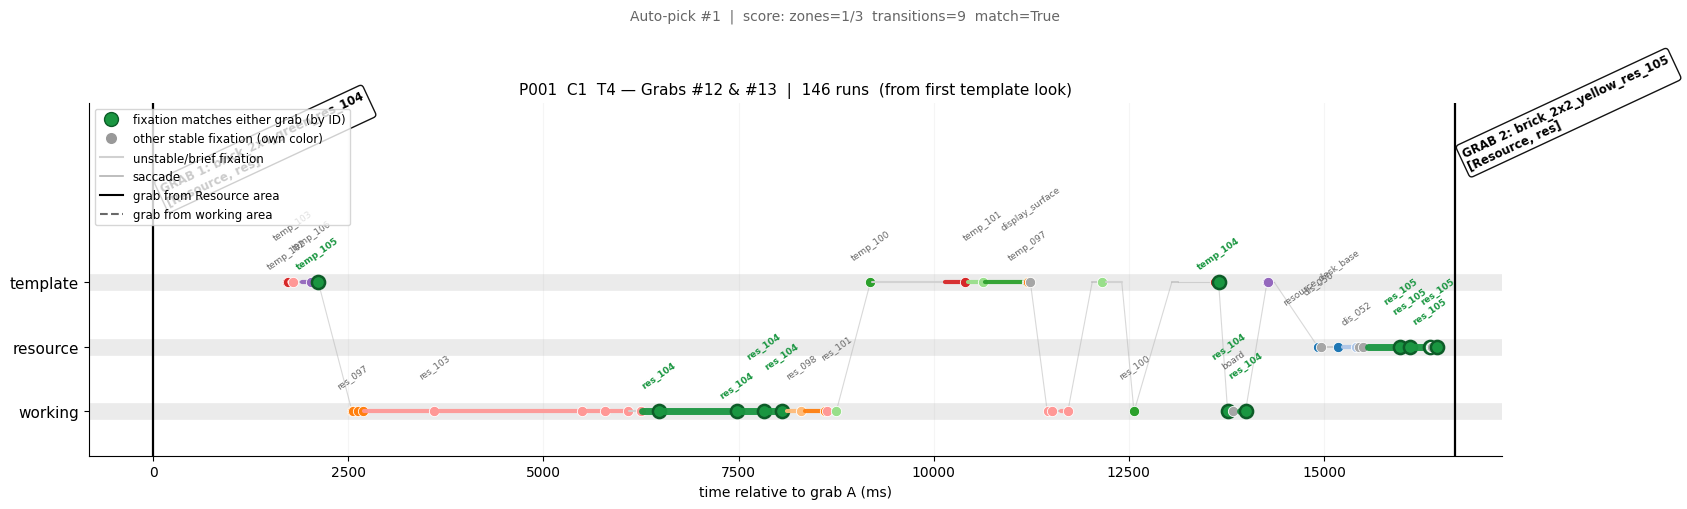

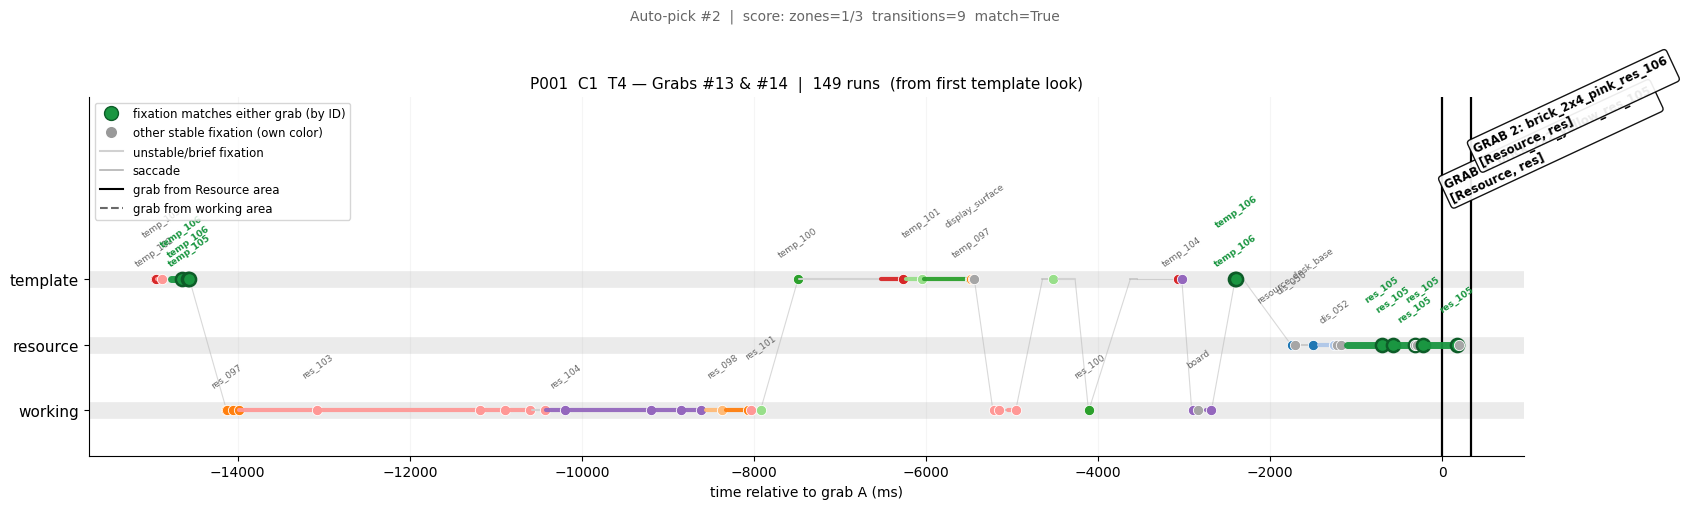

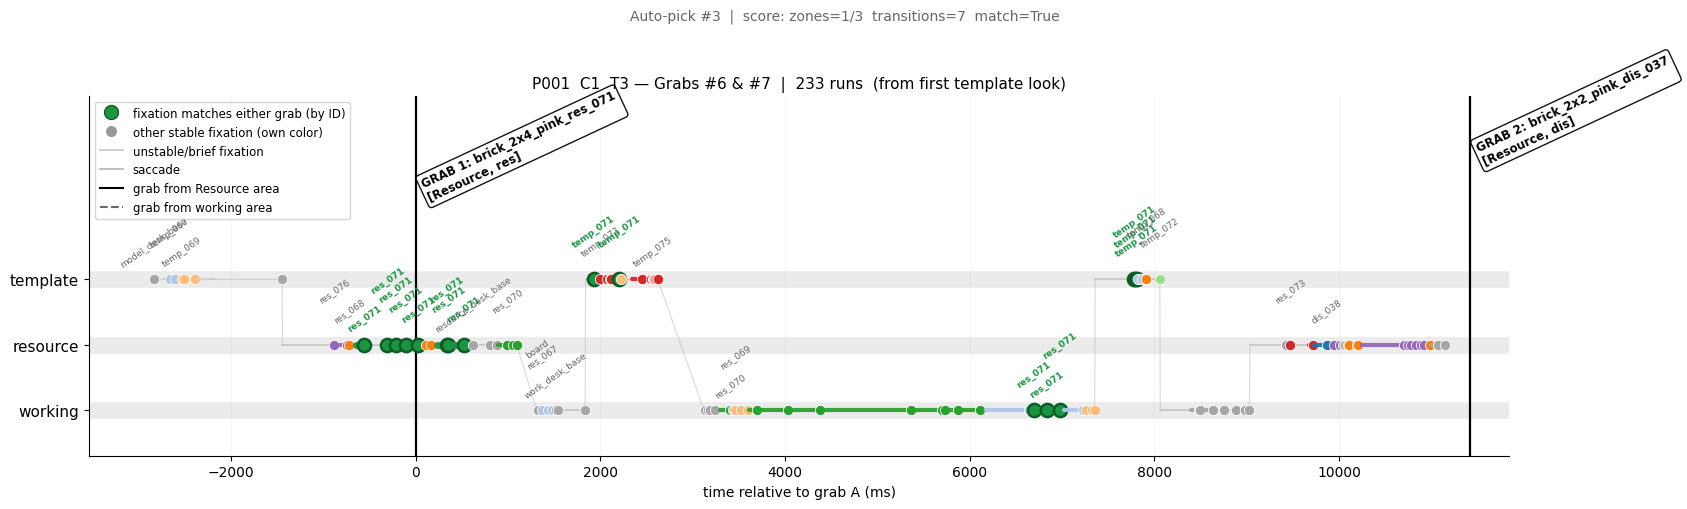

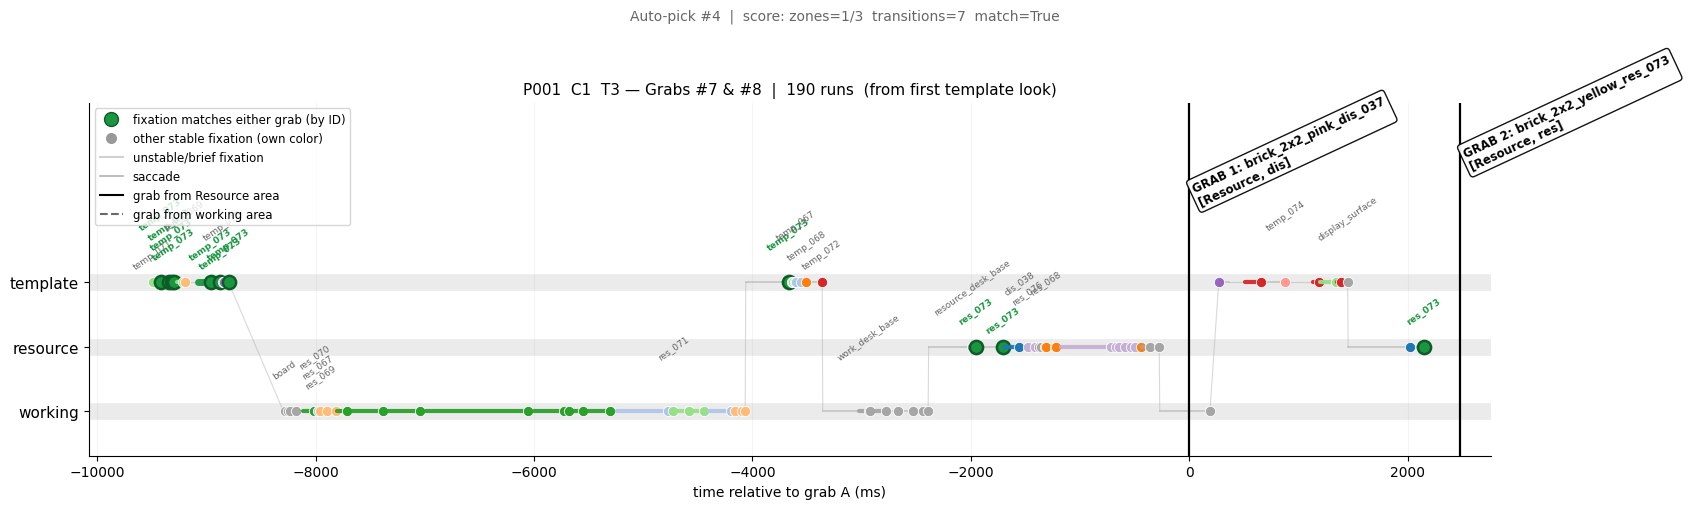

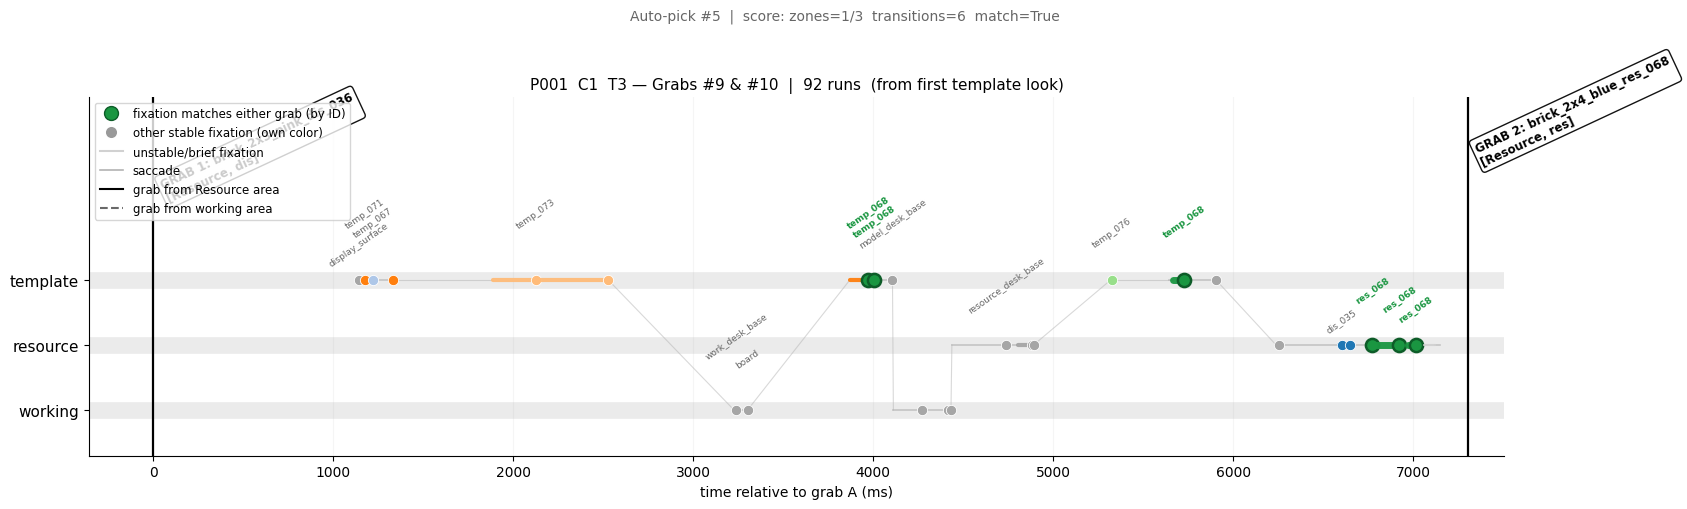

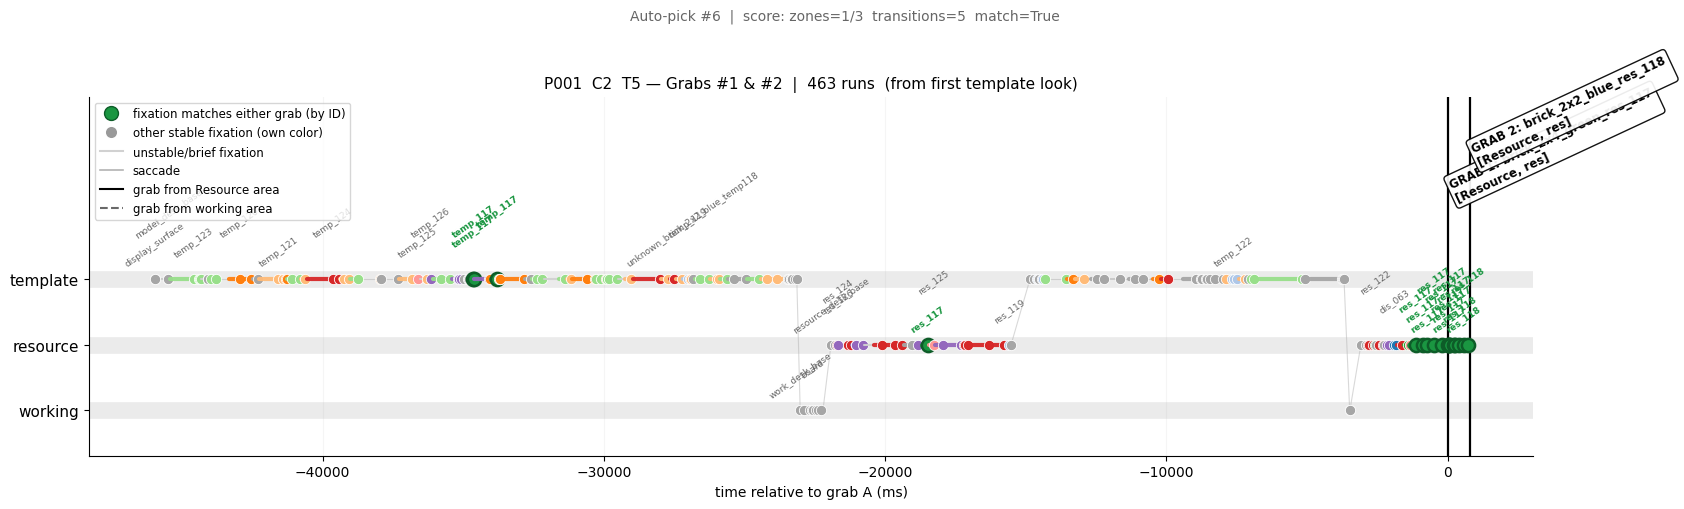

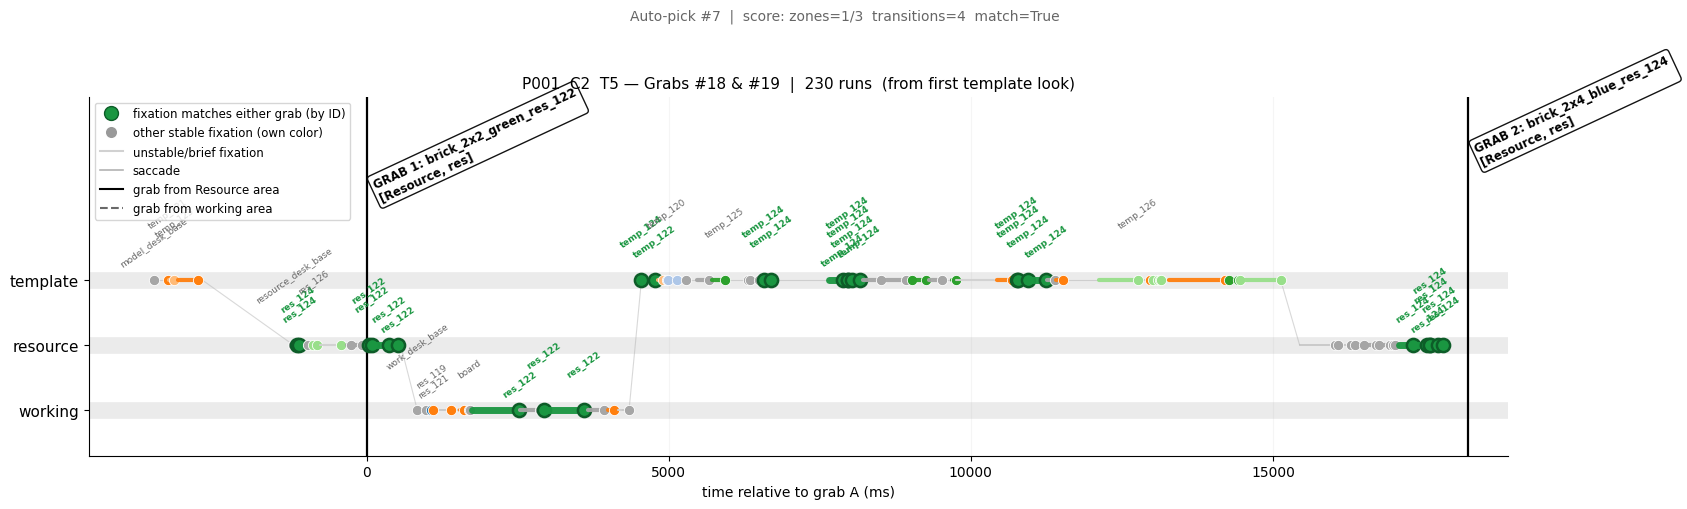

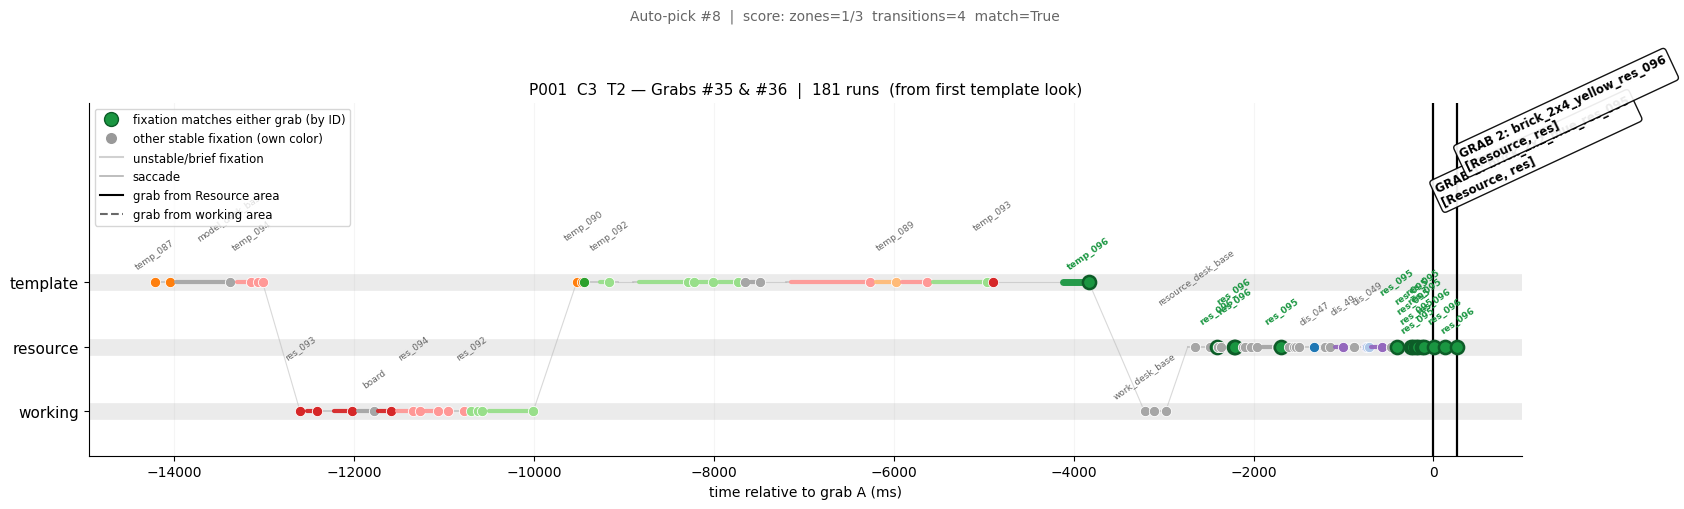

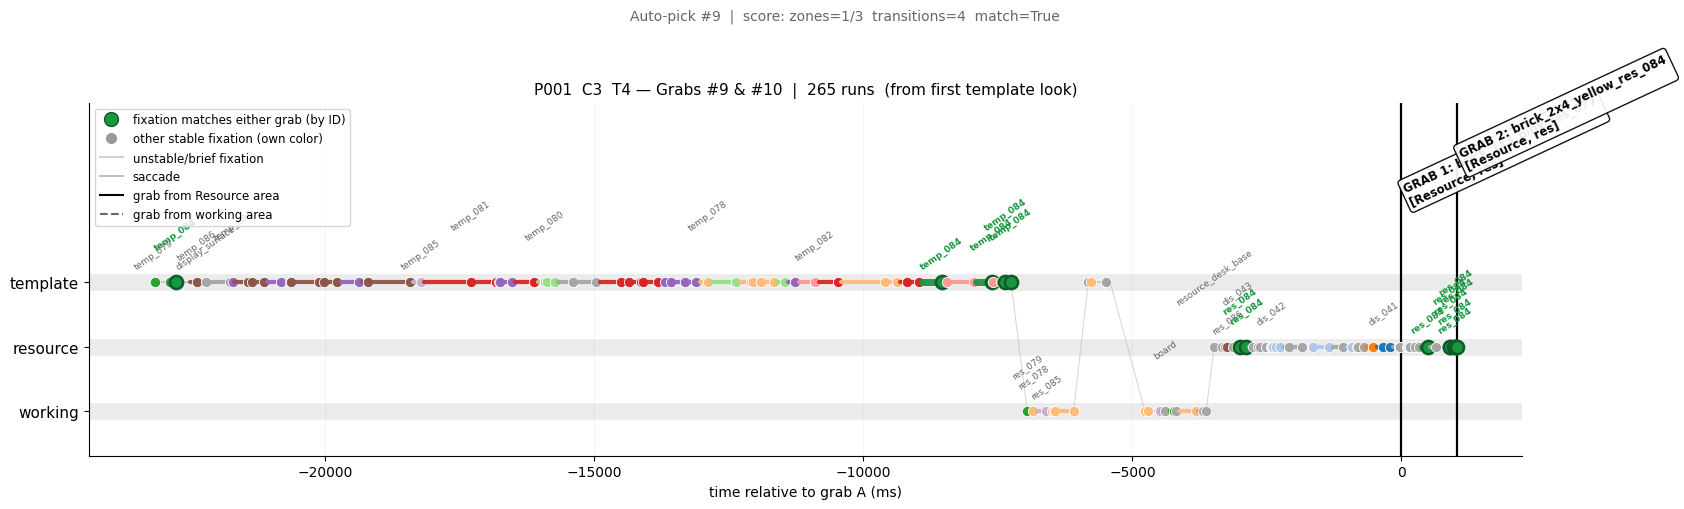

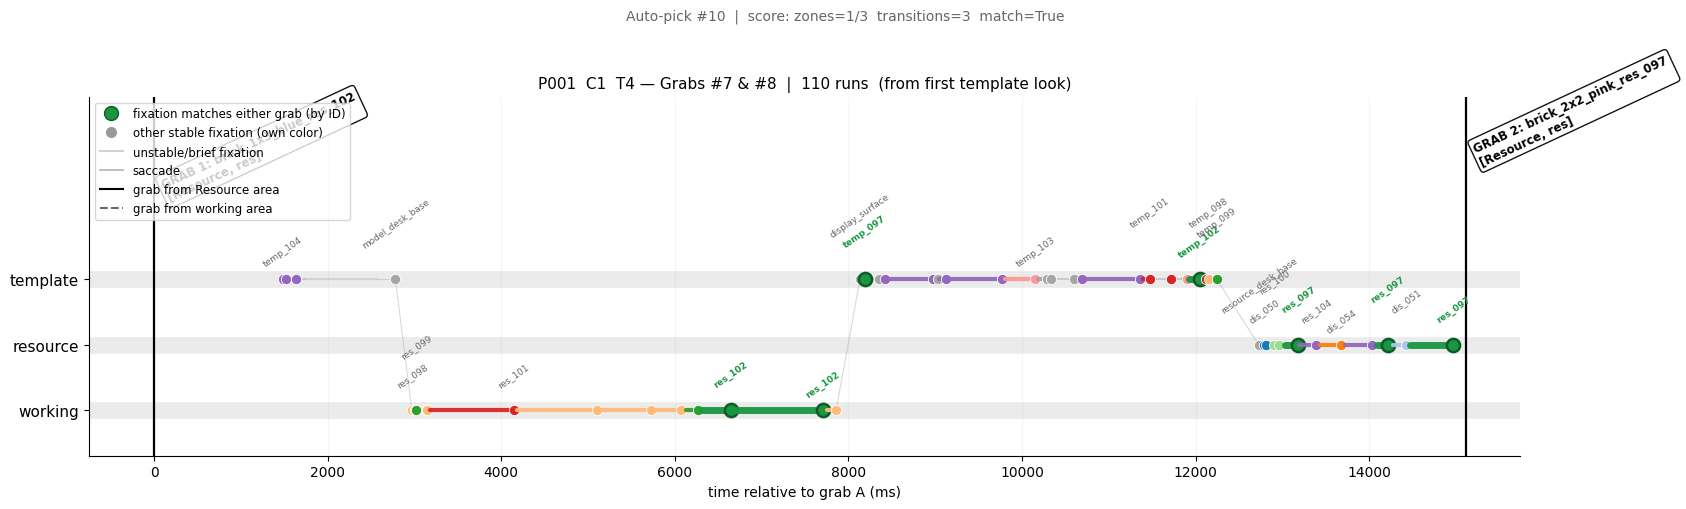

In [87]:
# ── Cell C2: auto-pick & plot pairs of CONSECUTIVE RESOURCE-AREA grabs ───────
# Shows real fixation runs (durations) AND real saccade runs (durations + their
# own gaze-position zone), plus grab events, on one timeline split into
# template/resource/working lanes.
#
# Requires `all_runs` (from detect_all_runs), which has columns:
#   category ("fixation"/"saccade"), start_time_ms, end_time_ms, duration_ms,
#   dominant_group, stable, zone_lane

N_PLOTS      = 10
WINDOW_MODE  = "template"
WINDOW_VALUE = 15000

import matplotlib.patches as mpatches

ZONE_LANES    = ["template", "resource", "working"]
ZONE_ALIAS    = {"model": "template", "resource": "resource", "working": "working"}
MATCH_COLOR   = "#1a9641"
MATCH_EDGE    = "#0d5c28"
SACCADE_COLOR = "0.7"
UNSTABLE_COLOR = "0.82"
palette       = plt.cm.tab20.colors

AREA_STYLE = {"Resource": ("black", "-"), "NonResource": ("dimgray", "--")}

def _short_id(s):
    if pd.isna(s): return None
    m = re.search(r"_(res|temp|dis)_(\d+)$", str(s)) or \
        re.match(r"^(res|temp|dis)_(\d+)$", str(s))
    return m.group(2) if m else None

def _gtype(name):
    if pd.isna(name): return None
    m = re.search(r"_(res|temp|dis)_\d+$", str(name))
    return m.group(1) if m else None

def get_window(trial_runs, gA, gB, mode, value):
    tA, tB = gA["grab_start_time_ms"], gB["grab_start_time_ms"]
    all_before = trial_runs[trial_runs["end_time_ms"] <= tB].sort_values("end_time_ms")
    if mode == "template":
        prevA      = gA["prev_grab_start_time_ms"]
        lo         = prevA if pd.notna(prevA) else -np.inf
        after_prev = all_before[all_before["end_time_ms"] > lo]
        temp_after = after_prev[(after_prev["zone_lane"] == "template") &
                                 (after_prev["category"] == "fixation")]
        t_start    = temp_after.iloc[0]["start_time_ms"] if not temp_after.empty else lo
        win = trial_runs[(trial_runs["end_time_ms"] >= t_start) &
                          (trial_runs["end_time_ms"] <= tB)].sort_values("end_time_ms").reset_index(drop=True)
        desc = "from first template look"
    elif mode == "time":
        win  = all_before[all_before["end_time_ms"] >= tA - value].reset_index(drop=True)
        desc = f"last {value:,} ms"
    elif mode == "nfix":
        fix_only = all_before[all_before["category"] == "fixation"].tail(value)
        if fix_only.empty:
            win = all_before.reset_index(drop=True)
        else:
            t_start = fix_only["start_time_ms"].min()
            win = all_before[all_before["start_time_ms"] >= t_start].reset_index(drop=True)
        desc = f"last {value} fixations"
    return win, desc

def score_pair(win, match_ids):
    fix_win    = win[win["category"] == "fixation"]
    zones      = set(fix_win["zone_lane"].dropna())
    n_zones    = len(zones & {"template","resource","working"})
    all_three  = int(n_zones == 3)
    lane_seq   = fix_win["zone_lane"].dropna().tolist()
    transitions = sum(1 for a,b in zip(lane_seq, lane_seq[1:]) if a != b)
    has_match  = int(any(_short_id(x) in match_ids for x in fix_win["dominant_group"]))
    return (all_three, transitions, has_match)

# ── scan consecutive pairs where BOTH grabs are from the resource area ──────
seg_grabs = grab_events_all.copy()

candidates = []
for (pid, cond, trial), tg in seg_grabs.groupby(["participant_id","condition_number","trial_number"]):
    tg = tg.sort_values("grab_start_time_ms").reset_index(drop=True)
    tf = all_runs[
        (all_runs["participant_id"]   == pid) &
        (all_runs["condition_number"] == cond) &
        (all_runs["trial_number"]     == trial)
    ].copy()

    for i in range(len(tg) - 1):
        gA_, gB_ = tg.iloc[i], tg.iloc[i+1]

        # only keep pairs where BOTH grabs are from the resource area
        if gA_["grab_start_area"] != "Resource" or gB_["grab_start_area"] != "Resource":
            continue

        idA_, idB_  = _short_id(gA_["grabbed_name"]), _short_id(gB_["grabbed_name"])
        mids        = {x for x in (idA_, idB_) if x}
        win_, _     = get_window(tf, gA_, gB_, WINDOW_MODE, WINDOW_VALUE)
        if len(win_) < 3: continue
        s = score_pair(win_, mids)
        candidates.append((s, pid, cond, trial, i, gA_, gB_, tf, win_))

candidates.sort(key=lambda x: x[0], reverse=True)
top = candidates[:N_PLOTS]

if not top:
    print("No valid pairs found — try loosening WINDOW_MODE or check all_runs.")
else:
    print(f"Top {len(top)} pairs (all_three_zones, transitions, has_match):")
    for rank, (s, pid, cond, trial, pi, gA_, gB_, tf_, win_) in enumerate(top):
        print(f"  #{rank+1}  P{pid} C{int(cond)} T{int(trial)} "
              f"grabs {int(gA_['grab_idx_in_trial'])}&{int(gB_['grab_idx_in_trial'])}  "
              f"score={s}  runs={len(win_)}  "
              f"[{gA_['grab_start_area']},{gA_['grabbed_type']}] -> "
              f"[{gB_['grab_start_area']},{gB_['grabbed_type']}]")

    for rank, (s, pid, cond, trial, pi, gA_, gB_, tf_, win_) in enumerate(top):
        tA, tB    = gA_["grab_start_time_ms"], gB_["grab_start_time_ms"]
        idA_, idB_= _short_id(gA_["grabbed_name"]), _short_id(gB_["grabbed_name"])
        match_ids = {x for x in (idA_, idB_) if x}
        win, desc = get_window(tf_, gA_, gB_, WINDOW_MODE, WINDOW_VALUE)

        fix_win = win[win["category"] == "fixation"]
        nonmatch_ids = sorted({_short_id(x) for x in fix_win["dominant_group"]
                               if _short_id(x) not in match_ids and _short_id(x) is not None})
        color_for    = {bid: palette[k % len(palette)] for k, bid in enumerate(nonmatch_ids)}

        def dot_color(fid):
            return MATCH_COLOR if fid in match_ids else color_for.get(fid, "0.65")

        tag = f"auto{rank+1}_P{pid}_C{int(cond)}_T{int(trial)}_g{int(gA_['grab_idx_in_trial'])}-{int(gB_['grab_idx_in_trial'])}_{WINDOW_MODE}"

        # ── Plot 1: timeline (real fixation + saccade runs + grabs) ─────────
        lane_y    = {z: i for i, z in enumerate(reversed(ZONE_LANES))}
        Y_OFFSETS = [8, 22, 36, 15, 29]
        labeled   = set()

        fig1, ax = plt.subplots(figsize=(17, 5))
        fig1.suptitle(f"Auto-pick #{rank+1}  |  score: zones={s[0]}/3  transitions={s[1]}  match={bool(s[2])}",
                      fontsize=10, color="0.4", y=1.01)

        for z in ZONE_LANES:
            ax.axhline(lane_y[z], color="0.92", linewidth=12, zorder=0)

        prev_point = None  # (t_rel_end, lane_y) of the previous plotted run

        for i, (_, fx) in enumerate(win.iterrows()):
            zone = fx["zone_lane"]
            if zone not in lane_y: continue
            t_start = fx["start_time_ms"] - tA
            t_end   = fx["end_time_ms"] - tA

            if fx["category"] == "saccade":
                # real saccade run: thin grey segment, at its own gaze-position zone
                if prev_point is not None:
                    ax.plot([prev_point[0], t_start], [prev_point[1], lane_y[zone]],
                            color=SACCADE_COLOR, linewidth=0.8, alpha=0.5, zorder=1)
                ax.plot([t_start, t_end], [lane_y[zone], lane_y[zone]],
                        color=SACCADE_COLOR, linewidth=1.2, alpha=0.7, zorder=1)
                prev_point = (t_end, lane_y[zone])
                continue

            # fixation run (stable or not)
            fid      = _short_id(fx["dominant_group"])
            stable   = bool(fx["stable"])
            color    = dot_color(fid) if stable else UNSTABLE_COLOR
            is_match = stable and (fid in match_ids)

            if prev_point is not None:
                ax.plot([prev_point[0], t_start], [prev_point[1], lane_y[zone]],
                        color=SACCADE_COLOR, linewidth=0.8, alpha=0.5, zorder=1)

            ax.plot([t_start, t_end], [lane_y[zone], lane_y[zone]],
                    color=color, linewidth=5 if is_match else (3 if stable else 1.5),
                    solid_capstyle="round", alpha=0.95, zorder=3)

            if stable:
                ax.scatter(t_end, lane_y[zone], color=color,
                           s=90 if is_match else 55, zorder=3,
                           edgecolor=MATCH_EDGE if is_match else "white",
                           linewidth=1.8 if is_match else 0.6)

            prev_point = (t_end, lane_y[zone])

            if stable:
                obj_key = (zone, str(fx["dominant_group"]))
                if is_match or obj_key not in labeled:
                    labeled.add(obj_key)
                    yoff = Y_OFFSETS[i % len(Y_OFFSETS)]
                    ax.annotate(str(fx["dominant_group"]),
                                (t_end, lane_y[zone]),
                                textcoords="offset points", xytext=(0, yoff),
                                ha="center", va="bottom", rotation=35, fontsize=6.5,
                                fontweight="bold" if is_match else "normal",
                                color=MATCH_COLOR if is_match else "0.4")

        # ── grab lines: styled by area, labeled with [area, type] ────────────
        for (g_, t_, lbl_num, ypos_) in [
                (gA_, tA, 1, len(ZONE_LANES) + 0.15),
                (gB_, tB, 2, len(ZONE_LANES) + 0.70)]:
            t_rel = t_ - tA
            color, ls = AREA_STYLE.get(g_["grab_start_area"], ("gray", ":"))
            lbl = f"GRAB {lbl_num}: {g_['grabbed_name']}\n[{g_['grab_start_area']}, {g_['grabbed_type']}]"
            ax.axvline(t_rel, color=color, linewidth=1.6, linestyle=ls, zorder=2)
            ax.text(t_rel + abs(tB - tA) * 0.004, ypos_, lbl,
                    ha="left", va="bottom", fontsize=8.5, fontweight="bold", rotation=25,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.92))

        ax.set_yticks([lane_y[z] for z in ZONE_LANES])
        ax.set_yticklabels(ZONE_LANES, fontsize=11)
        ax.set_ylim(-0.7, len(ZONE_LANES) + 1.8)
        ax.set_xlabel("time relative to grab A (ms)", fontsize=10)
        ax.set_title(f"P{pid}  C{int(cond)}  T{int(trial)} — "
                     f"Grabs #{int(gA_['grab_idx_in_trial'])} & #{int(gB_['grab_idx_in_trial'])}"
                     f"  |  {len(win)} runs  ({desc})", fontsize=11)
        ax.spines[["top","right"]].set_visible(False)
        ax.grid(axis="x", alpha=0.12)
        ax.legend(handles=[
            plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=MATCH_COLOR,
                       markeredgecolor=MATCH_EDGE, markersize=10, label="fixation matches either grab (by ID)"),
            plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="0.6",
                       markersize=9, label="other stable fixation (own color)"),
            plt.Line2D([0],[0], color=UNSTABLE_COLOR, linewidth=1.5, label="unstable/brief fixation"),
            plt.Line2D([0],[0], color=SACCADE_COLOR, linewidth=1.2, label="saccade"),
            plt.Line2D([0],[0], color="black", linestyle="-", label="grab from Resource area"),
            plt.Line2D([0],[0], color="dimgray", linestyle="--", label="grab from working area"),
        ], loc="upper left", fontsize=8.5, frameon=True)
        plt.tight_layout()
        plt.savefig(f"plot1_timeline_{tag}.png", dpi=150, bbox_inches="tight")
        plt.show()

Top 10 pairs (all_three_zones, transitions, has_match):
  #1  P001 C1 T4 grabs 12&13  score=(1, 9, 1)  runs=146  [Resource,res] -> [Resource,res]
  #2  P001 C1 T4 grabs 13&14  score=(1, 9, 1)  runs=149  [Resource,res] -> [Resource,res]
  #3  P001 C1 T3 grabs 6&7  score=(1, 7, 1)  runs=233  [Resource,res] -> [Resource,dis]
  #4  P001 C1 T3 grabs 7&8  score=(1, 7, 1)  runs=190  [Resource,dis] -> [Resource,res]
  #5  P001 C1 T3 grabs 9&10  score=(1, 6, 1)  runs=92  [Resource,dis] -> [Resource,res]
  #6  P001 C2 T5 grabs 1&2  score=(1, 5, 1)  runs=463  [Resource,res] -> [Resource,res]
  #7  P001 C2 T5 grabs 18&19  score=(1, 4, 1)  runs=230  [Resource,res] -> [Resource,res]
  #8  P001 C3 T2 grabs 35&36  score=(1, 4, 1)  runs=181  [Resource,res] -> [Resource,res]
  #9  P001 C3 T4 grabs 9&10  score=(1, 4, 1)  runs=265  [Resource,res] -> [Resource,res]
  #10  P001 C1 T4 grabs 7&8  score=(1, 3, 1)  runs=110  [Resource,res] -> [Resource,res]


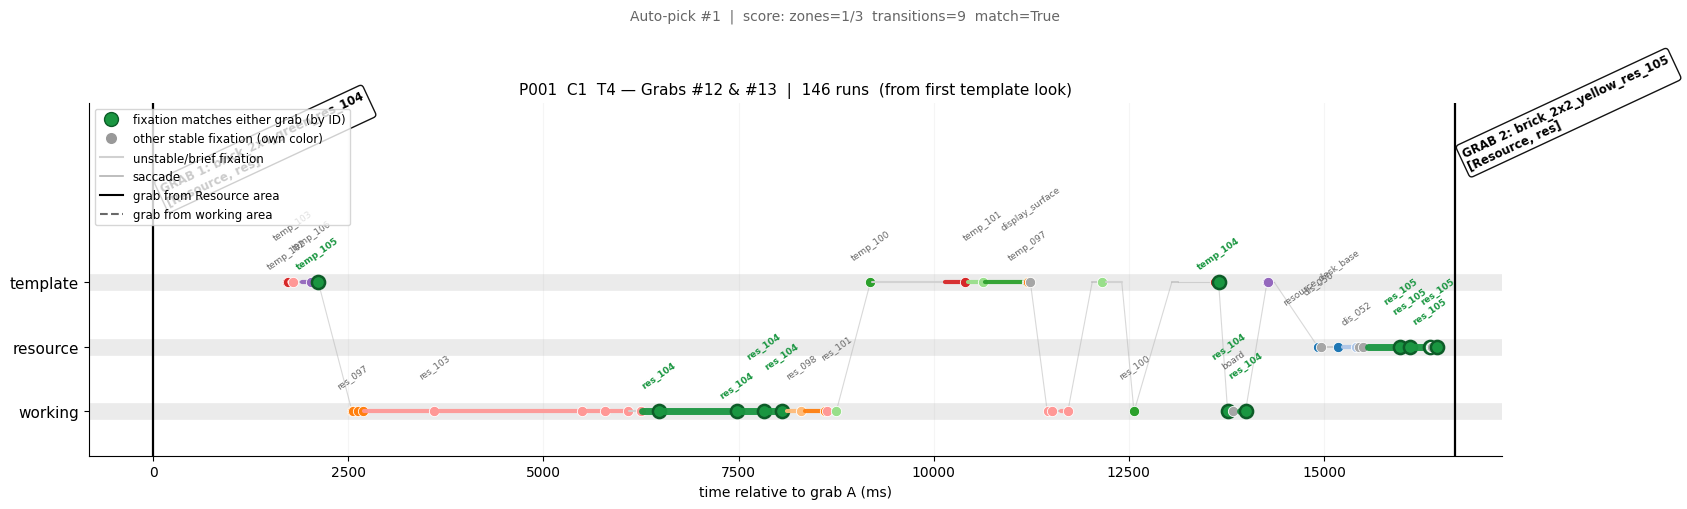

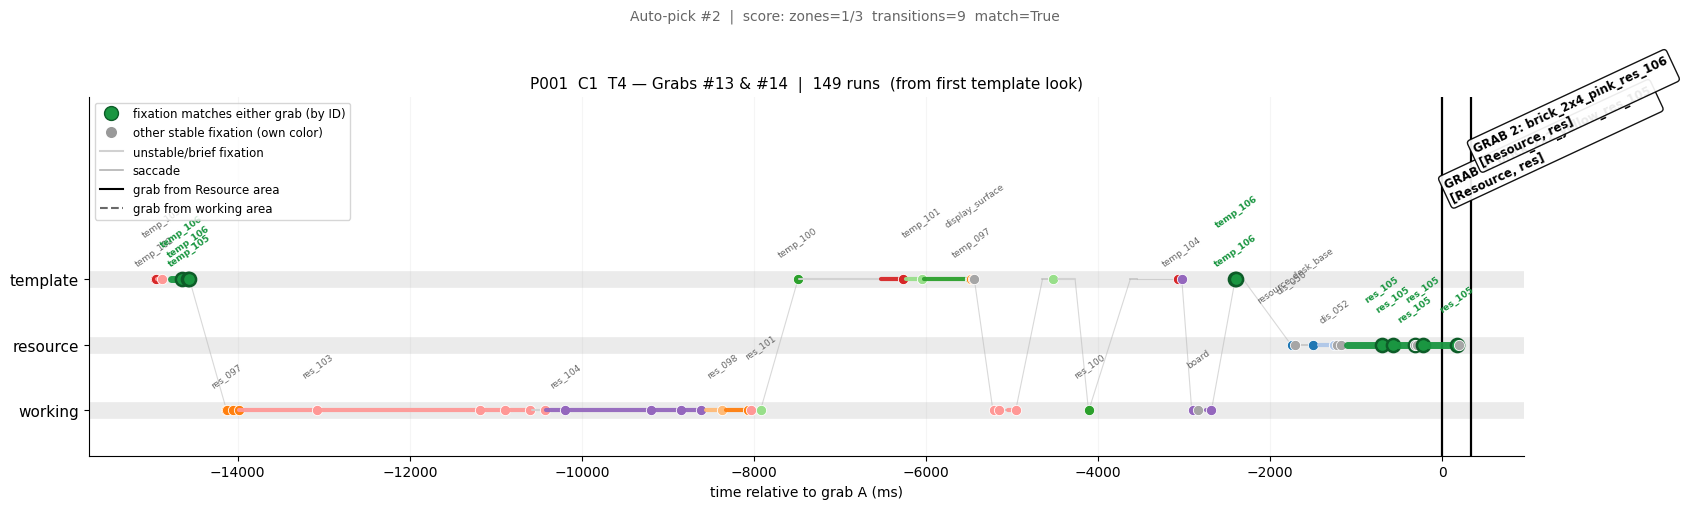

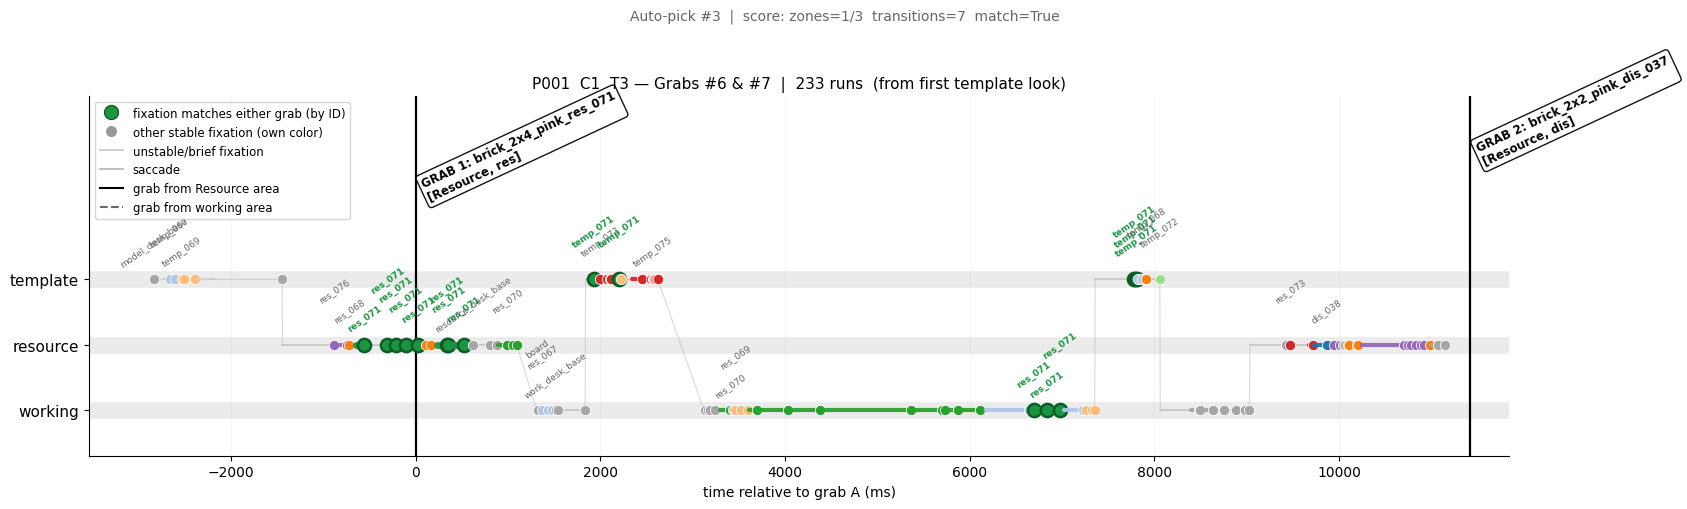

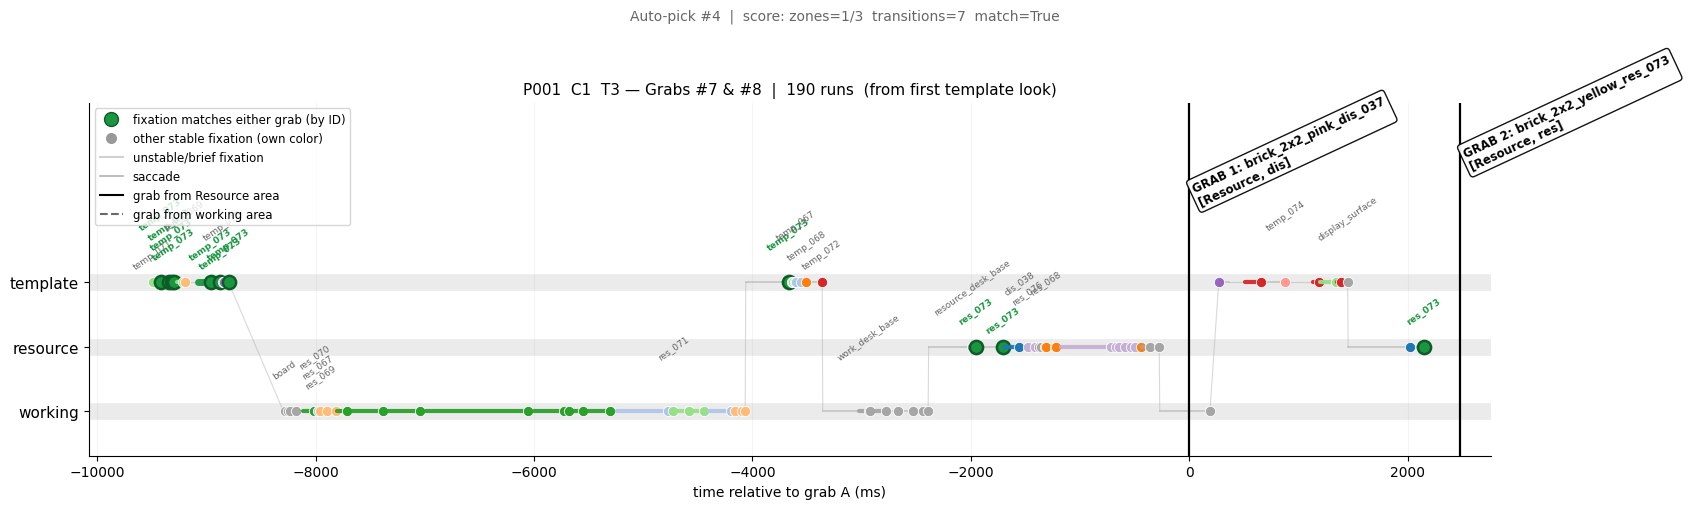

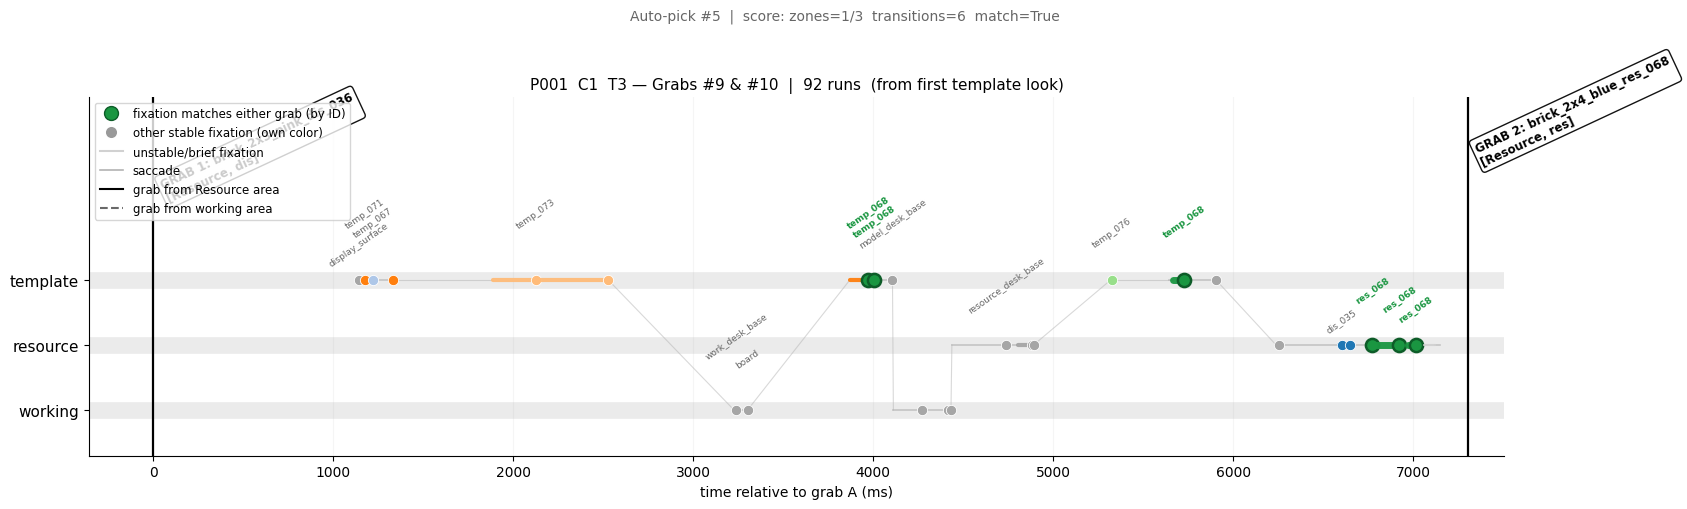

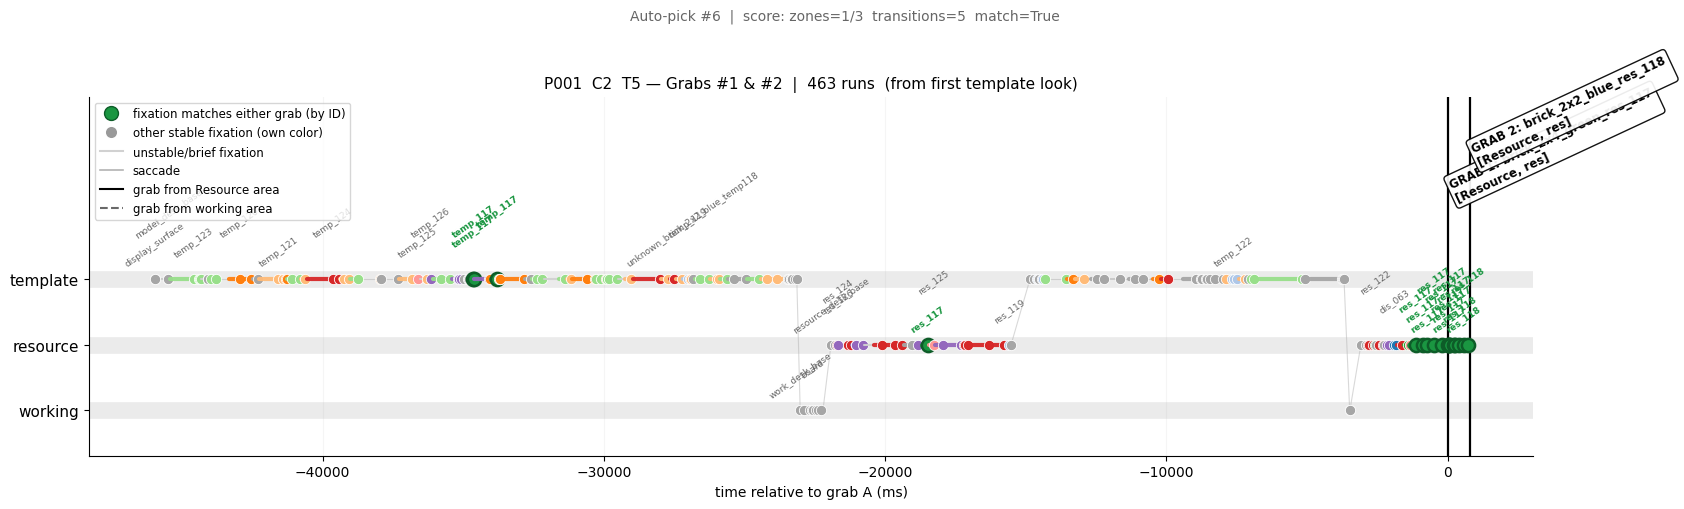

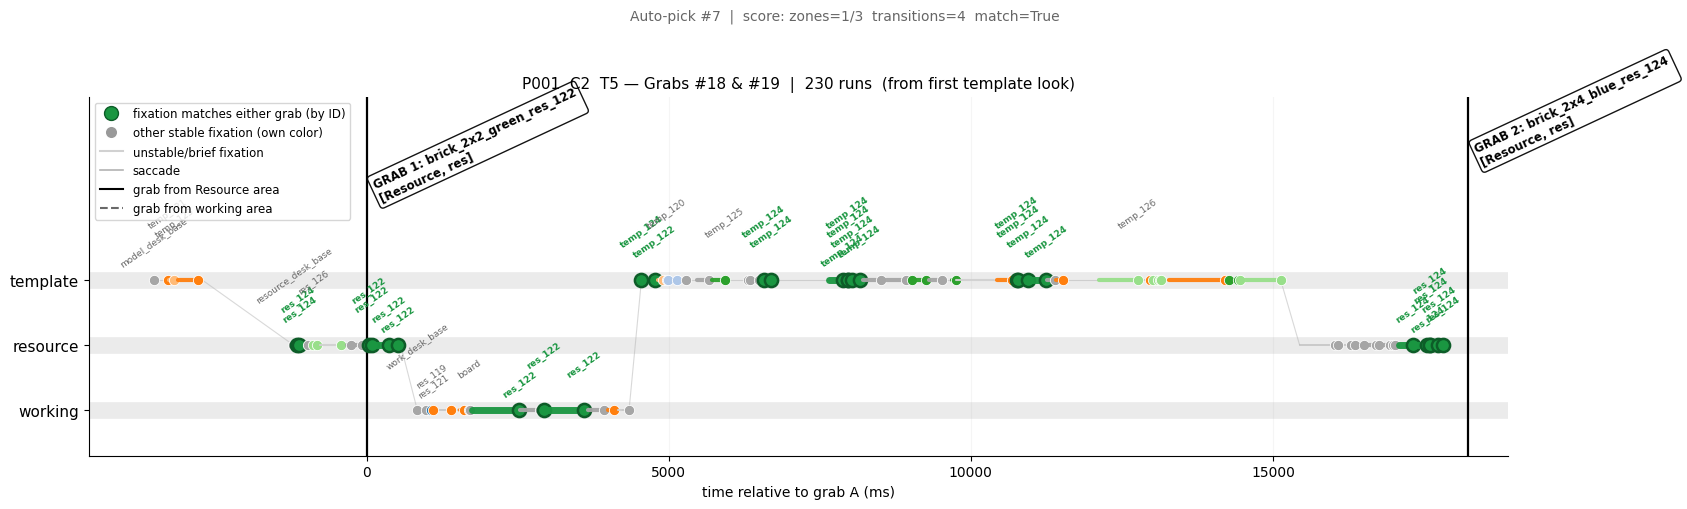

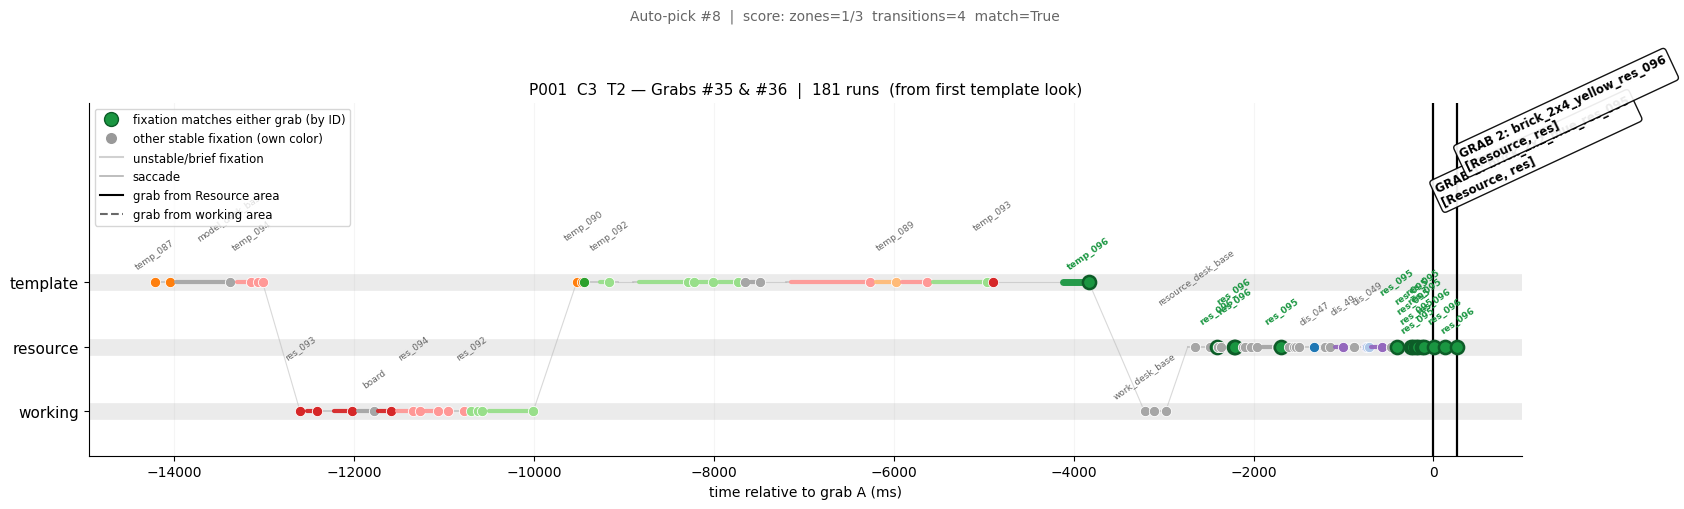

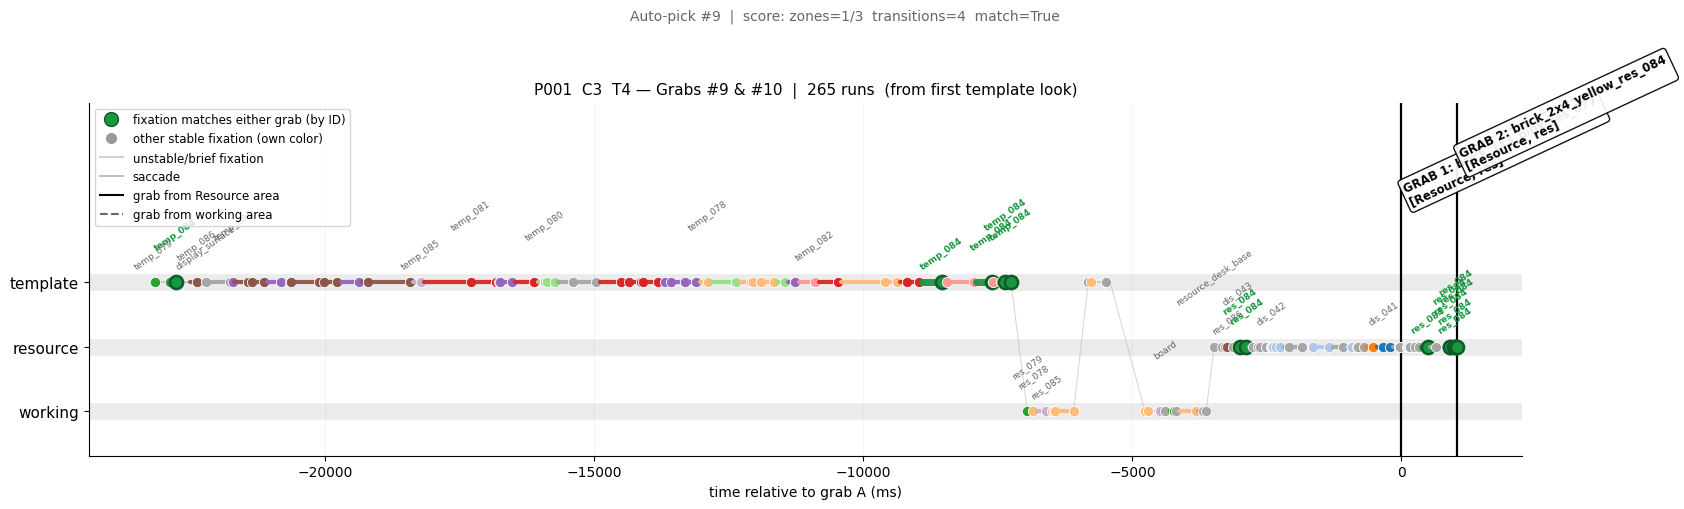

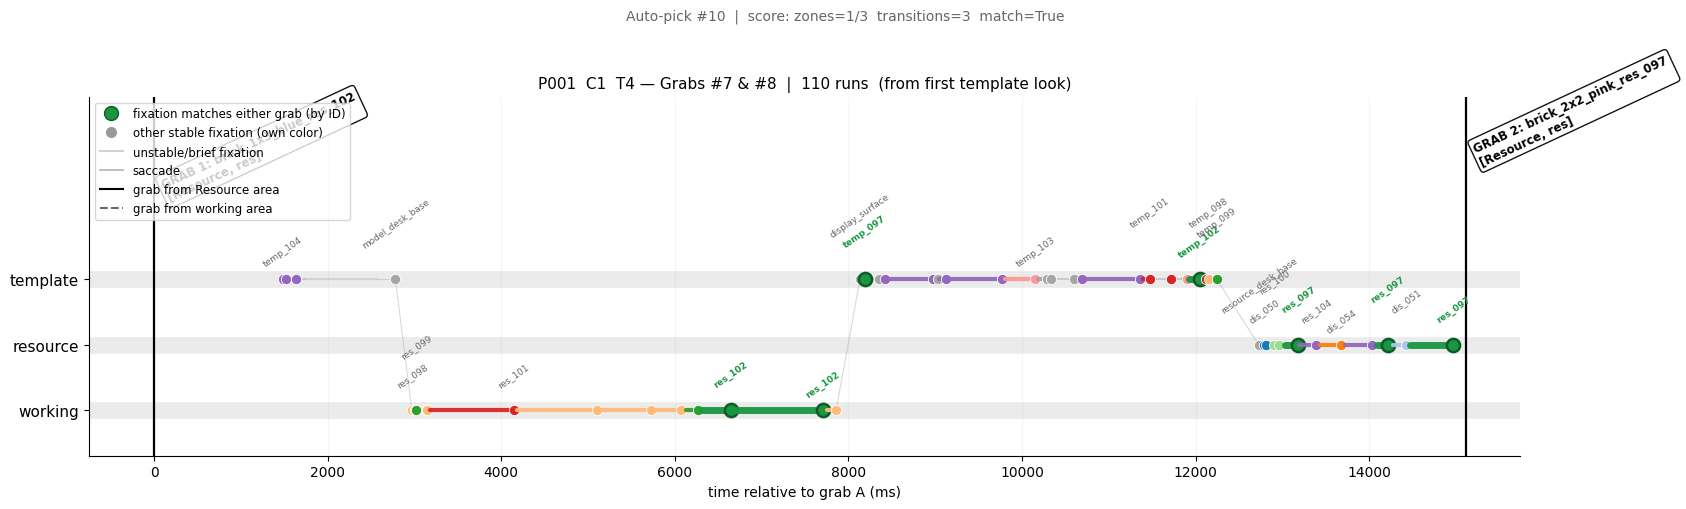

In [91]:
# ── Cell C2: auto-pick & plot pairs of CONSECUTIVE RESOURCE-AREA grabs ───────
# Shows real fixation runs (durations) AND real saccade runs (durations + their
# own gaze-position zone), plus grab events, on one timeline split into
# template/resource/working lanes.
#
# Requires `all_runs` (from detect_all_runs), which has columns:
#   category ("fixation"/"saccade"), start_time_ms, end_time_ms, duration_ms,
#   dominant_group, stable, zone_lane

N_PLOTS      = 10
WINDOW_MODE  = "template"
WINDOW_VALUE = 8000

import matplotlib.patches as mpatches

ZONE_LANES    = ["template", "resource", "working"]
ZONE_ALIAS    = {"model": "template", "resource": "resource", "working": "working"}
MATCH_COLOR   = "#1a9641"
MATCH_EDGE    = "#0d5c28"
SACCADE_COLOR = "0.7"
UNSTABLE_COLOR = "0.82"
palette       = plt.cm.tab20.colors

AREA_STYLE = {"Resource": ("black", "-"), "NonResource": ("dimgray", "--")}

def _short_id(s):
    if pd.isna(s): return None
    m = re.search(r"_(res|temp|dis)_(\d+)$", str(s)) or \
        re.match(r"^(res|temp|dis)_(\d+)$", str(s))
    return m.group(2) if m else None

def _gtype(name):
    if pd.isna(name): return None
    m = re.search(r"_(res|temp|dis)_\d+$", str(name))
    return m.group(1) if m else None

def get_window(trial_runs, gA, gB, mode, value):
    tA, tB = gA["grab_start_time_ms"], gB["grab_start_time_ms"]
    all_before = trial_runs[trial_runs["end_time_ms"] <= tB].sort_values("end_time_ms")
    if mode == "template":
        prevA      = gA["prev_grab_start_time_ms"]
        lo         = prevA if pd.notna(prevA) else -np.inf
        after_prev = all_before[all_before["end_time_ms"] > lo]
        temp_after = after_prev[(after_prev["zone_lane"] == "template") &
                                 (after_prev["category"] == "fixation")]
        t_start    = temp_after.iloc[0]["start_time_ms"] if not temp_after.empty else lo
        win = trial_runs[(trial_runs["end_time_ms"] >= t_start) &
                          (trial_runs["end_time_ms"] <= tB)].sort_values("end_time_ms").reset_index(drop=True)
        desc = "from first template look"
    elif mode == "time":
        win  = all_before[all_before["end_time_ms"] >= tA - value].reset_index(drop=True)
        desc = f"last {value:,} ms"
    elif mode == "nfix":
        fix_only = all_before[all_before["category"] == "fixation"].tail(value)
        if fix_only.empty:
            win = all_before.reset_index(drop=True)
        else:
            t_start = fix_only["start_time_ms"].min()
            win = all_before[all_before["start_time_ms"] >= t_start].reset_index(drop=True)
        desc = f"last {value} fixations"
    return win, desc

def score_pair(win, match_ids):
    fix_win    = win[win["category"] == "fixation"]
    zones      = set(fix_win["zone_lane"].dropna())
    n_zones    = len(zones & {"template","resource","working"})
    all_three  = int(n_zones == 3)
    lane_seq   = fix_win["zone_lane"].dropna().tolist()
    transitions = sum(1 for a,b in zip(lane_seq, lane_seq[1:]) if a != b)
    has_match  = int(any(_short_id(x) in match_ids for x in fix_win["dominant_group"]))
    return (all_three, transitions, has_match)

# ── scan consecutive pairs where BOTH grabs are from the resource area ──────
seg_grabs = grab_events_all.copy()

candidates = []
for (pid, cond, trial), tg in seg_grabs.groupby(["participant_id","condition_number","trial_number"]):
    tg = tg.sort_values("grab_start_time_ms").reset_index(drop=True)
    tf = all_runs[
        (all_runs["participant_id"]   == pid) &
        (all_runs["condition_number"] == cond) &
        (all_runs["trial_number"]     == trial)
    ].copy()

    for i in range(len(tg) - 1):
        gA_, gB_ = tg.iloc[i], tg.iloc[i+1]

        # only keep pairs where BOTH grabs are from the resource area
        if gA_["grab_start_area"] != "Resource" or gB_["grab_start_area"] != "Resource":
            continue

        idA_, idB_  = _short_id(gA_["grabbed_name"]), _short_id(gB_["grabbed_name"])
        mids        = {x for x in (idA_, idB_) if x}
        win_, _     = get_window(tf, gA_, gB_, WINDOW_MODE, WINDOW_VALUE)
        if len(win_) < 3: continue
        s = score_pair(win_, mids)
        candidates.append((s, pid, cond, trial, i, gA_, gB_, tf, win_))

candidates.sort(key=lambda x: x[0], reverse=True)
top = candidates[:N_PLOTS]

if not top:
    print("No valid pairs found — try loosening WINDOW_MODE or check all_runs.")
else:
    print(f"Top {len(top)} pairs (all_three_zones, transitions, has_match):")
    for rank, (s, pid, cond, trial, pi, gA_, gB_, tf_, win_) in enumerate(top):
        print(f"  #{rank+1}  P{pid} C{int(cond)} T{int(trial)} "
              f"grabs {int(gA_['grab_idx_in_trial'])}&{int(gB_['grab_idx_in_trial'])}  "
              f"score={s}  runs={len(win_)}  "
              f"[{gA_['grab_start_area']},{gA_['grabbed_type']}] -> "
              f"[{gB_['grab_start_area']},{gB_['grabbed_type']}]")

    for rank, (s, pid, cond, trial, pi, gA_, gB_, tf_, win_) in enumerate(top):
        tA, tB    = gA_["grab_start_time_ms"], gB_["grab_start_time_ms"]
        idA_, idB_= _short_id(gA_["grabbed_name"]), _short_id(gB_["grabbed_name"])
        match_ids = {x for x in (idA_, idB_) if x}
        win, desc = get_window(tf_, gA_, gB_, WINDOW_MODE, WINDOW_VALUE)

        fix_win = win[win["category"] == "fixation"]
        nonmatch_ids = sorted({_short_id(x) for x in fix_win["dominant_group"]
                               if _short_id(x) not in match_ids and _short_id(x) is not None})
        color_for    = {bid: palette[k % len(palette)] for k, bid in enumerate(nonmatch_ids)}

        def dot_color(fid):
            return MATCH_COLOR if fid in match_ids else color_for.get(fid, "0.65")

        tag = f"auto{rank+1}_P{pid}_C{int(cond)}_T{int(trial)}_g{int(gA_['grab_idx_in_trial'])}-{int(gB_['grab_idx_in_trial'])}_{WINDOW_MODE}"

        # ── Plot 1: timeline (real fixation + saccade runs + grabs) ─────────
        lane_y    = {z: i for i, z in enumerate(reversed(ZONE_LANES))}
        Y_OFFSETS = [8, 22, 36, 15, 29]
        labeled   = set()

        fig1, ax = plt.subplots(figsize=(17, 5))
        fig1.suptitle(f"Auto-pick #{rank+1}  |  score: zones={s[0]}/3  transitions={s[1]}  match={bool(s[2])}",
                      fontsize=10, color="0.4", y=1.01)

        for z in ZONE_LANES:
            ax.axhline(lane_y[z], color="0.92", linewidth=12, zorder=0)

        prev_point = None  # (t_rel_end, lane_y) of the previous plotted run

        for i, (_, fx) in enumerate(win.iterrows()):
            zone = fx["zone_lane"]
            if zone not in lane_y: continue
            t_start = fx["start_time_ms"] - tA
            t_end   = fx["end_time_ms"] - tA

            if fx["category"] == "saccade":
                # real saccade run: thin grey segment, at its own gaze-position zone
                if prev_point is not None:
                    ax.plot([prev_point[0], t_start], [prev_point[1], lane_y[zone]],
                            color=SACCADE_COLOR, linewidth=0.8, alpha=0.5, zorder=1)
                ax.plot([t_start, t_end], [lane_y[zone], lane_y[zone]],
                        color=SACCADE_COLOR, linewidth=1.2, alpha=0.7, zorder=1)
                prev_point = (t_end, lane_y[zone])
                continue

            # fixation run (stable or not)
            fid      = _short_id(fx["dominant_group"])
            stable   = bool(fx["stable"])
            color    = dot_color(fid) if stable else UNSTABLE_COLOR
            is_match = stable and (fid in match_ids)

            if prev_point is not None:
                ax.plot([prev_point[0], t_start], [prev_point[1], lane_y[zone]],
                        color=SACCADE_COLOR, linewidth=0.8, alpha=0.5, zorder=1)

            ax.plot([t_start, t_end], [lane_y[zone], lane_y[zone]],
                    color=color, linewidth=5 if is_match else (3 if stable else 1.5),
                    solid_capstyle="round", alpha=0.95, zorder=3)

            if stable:
                ax.scatter(t_end, lane_y[zone], color=color,
                           s=90 if is_match else 55, zorder=3,
                           edgecolor=MATCH_EDGE if is_match else "white",
                           linewidth=1.8 if is_match else 0.6)

            prev_point = (t_end, lane_y[zone])

            if stable:
                obj_key = (zone, str(fx["dominant_group"]))
                if is_match or obj_key not in labeled:
                    labeled.add(obj_key)
                    yoff = Y_OFFSETS[i % len(Y_OFFSETS)]
                    ax.annotate(str(fx["dominant_group"]),
                                (t_end, lane_y[zone]),
                                textcoords="offset points", xytext=(0, yoff),
                                ha="center", va="bottom", rotation=35, fontsize=6.5,
                                fontweight="bold" if is_match else "normal",
                                color=MATCH_COLOR if is_match else "0.4")

        # ── grab lines: styled by area, labeled with [area, type] ────────────
        for (g_, t_, lbl_num, ypos_) in [
                (gA_, tA, 1, len(ZONE_LANES) + 0.15),
                (gB_, tB, 2, len(ZONE_LANES) + 0.70)]:
            t_rel = t_ - tA
            color, ls = AREA_STYLE.get(g_["grab_start_area"], ("gray", ":"))
            lbl = f"GRAB {lbl_num}: {g_['grabbed_name']}\n[{g_['grab_start_area']}, {g_['grabbed_type']}]"
            ax.axvline(t_rel, color=color, linewidth=1.6, linestyle=ls, zorder=2)
            ax.text(t_rel + abs(tB - tA) * 0.004, ypos_, lbl,
                    ha="left", va="bottom", fontsize=8.5, fontweight="bold", rotation=25,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.92))

        ax.set_yticks([lane_y[z] for z in ZONE_LANES])
        ax.set_yticklabels(ZONE_LANES, fontsize=11)
        ax.set_ylim(-0.7, len(ZONE_LANES) + 1.8)
        ax.set_xlabel("time relative to grab A (ms)", fontsize=10)
        ax.set_title(f"P{pid}  C{int(cond)}  T{int(trial)} — "
                     f"Grabs #{int(gA_['grab_idx_in_trial'])} & #{int(gB_['grab_idx_in_trial'])}"
                     f"  |  {len(win)} runs  ({desc})", fontsize=11)
        ax.spines[["top","right"]].set_visible(False)
        ax.grid(axis="x", alpha=0.12)
        ax.legend(handles=[
            plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=MATCH_COLOR,
                       markeredgecolor=MATCH_EDGE, markersize=10, label="fixation matches either grab (by ID)"),
            plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="0.6",
                       markersize=9, label="other stable fixation (own color)"),
            plt.Line2D([0],[0], color=UNSTABLE_COLOR, linewidth=1.5, label="unstable/brief fixation"),
            plt.Line2D([0],[0], color=SACCADE_COLOR, linewidth=1.2, label="saccade"),
            plt.Line2D([0],[0], color="black", linestyle="-", label="grab from Resource area"),
            plt.Line2D([0],[0], color="dimgray", linestyle="--", label="grab from working area"),
        ], loc="upper left", fontsize=8.5, frameon=True)
        plt.tight_layout()
        plt.savefig(f"plot1_timeline_{tag}.png", dpi=150, bbox_inches="tight")
        plt.show()

In [89]:
# find the specific candidate: P001 C1 T4, grabs 13 & 14
target = next(
    c for c in candidates
    if c[1] == "001" and c[2] == 1 and c[3] == 4
    and int(c[5]["grab_idx_in_trial"]) == 13
    and int(c[6]["grab_idx_in_trial"]) == 14
)

s, pid, cond, trial, pi, gA_, gB_, tf_, win_ = target
win, desc = get_window(tf_, gA_, gB_, WINDOW_MODE, WINDOW_VALUE)

win_start_ms = win["start_time_ms"].min()
win_end_ms   = win["end_time_ms"].max()
grabA_ms     = gA_["grab_start_time_ms"]
grabB_ms     = gB_["grab_start_time_ms"]

print(f"Window:  {win_start_ms:.0f} ms  ->  {win_end_ms:.0f} ms  "
      f"(duration {(win_end_ms - win_start_ms)/1000:.2f} s)")
print(f"Grab A:  {grabA_ms:.0f} ms   |  Grab B: {grabB_ms:.0f} ms")

Window:  91561 ms  ->  106727 ms  (duration 15.17 s)
Grab A:  106532 ms   |  Grab B: 106867 ms


In [90]:
# T0 for this trial (already computed)
T0_trial = trial_data.iloc[0]["raw_timestamp"]

# T0 for the start of the whole condition (trial 1, time_ms == 0)
cond_start_data = prepared[
    (prepared["participant_id"]   == pid) &
    (prepared["condition_number"] == cond)
].sort_values(["trial_number", "time_ms"])

T0_condition = cond_start_data.iloc[0]["raw_timestamp"]

# elapsed time from condition start to the window edges
elapsed_start_ms = (T0_trial + win_start_ms) - T0_condition
elapsed_end_ms   = (T0_trial + win_end_ms)   - T0_condition
elapsed_grabA_ms = (T0_trial + grabA_ms)     - T0_condition
elapsed_grabB_ms = (T0_trial + grabB_ms)     - T0_condition

print(f"Window start: {elapsed_start_ms/1000:.2f} s  ({elapsed_start_ms:.0f} ms) from condition start")
print(f"Window end:   {elapsed_end_ms/1000:.2f} s  ({elapsed_end_ms:.0f} ms) from condition start")
print(f"Grab A:       {elapsed_grabA_ms/1000:.2f} s")
print(f"Grab B:       {elapsed_grabB_ms/1000:.2f} s")
print(f"Duration:     {(elapsed_end_ms - elapsed_start_ms)/1000:.2f} s")

Window start: 91.56 s  (91561 ms) from condition start
Window end:   106.73 s  (106727 ms) from condition start
Grab A:       106.53 s
Grab B:       106.87 s
Duration:     15.17 s


Window: 86154 -> 106727 ms (20.57 s), 201 runs


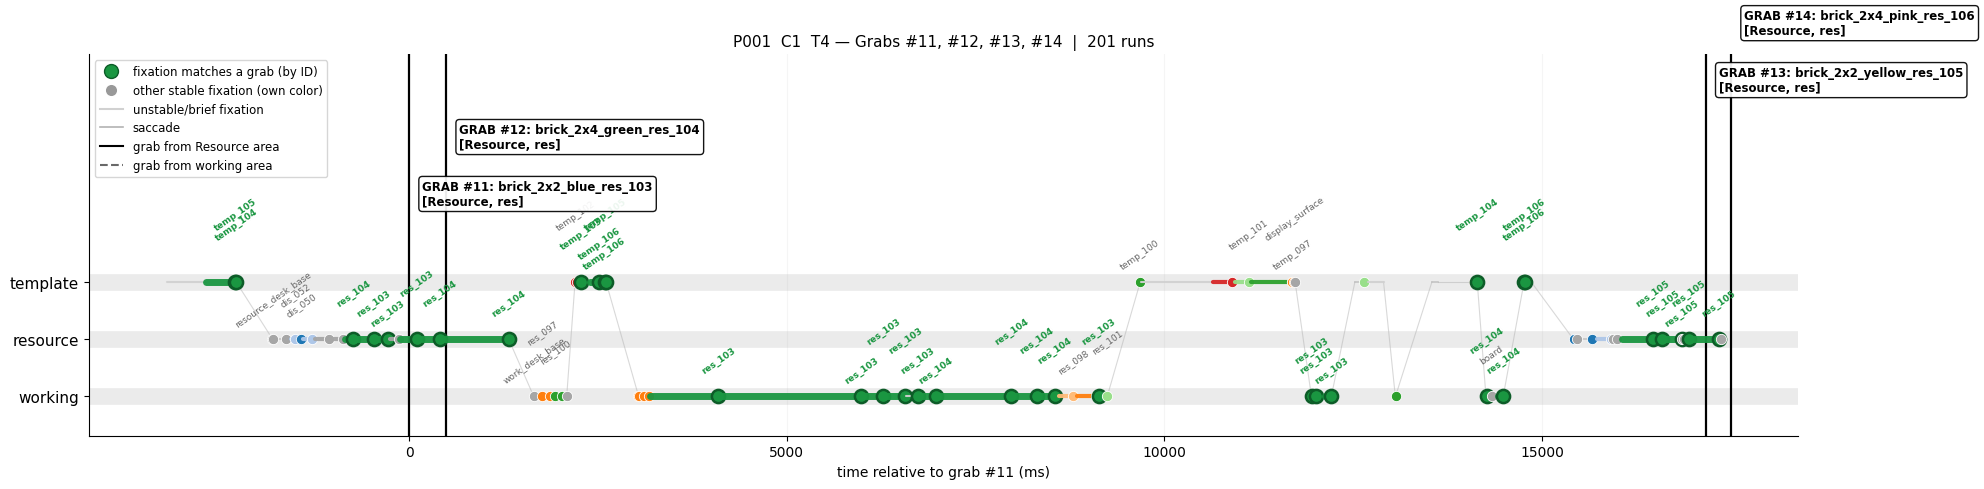

In [93]:
# ── Custom plot: P001 C1 T4 — grabs #11, #12, #13, #14 in one timeline ──────

pid, cond, trial = "001", 1, 4
grab_indices = [11, 12, 13, 14]

# pull these specific grabs
tg = grab_events_all[
    (grab_events_all["participant_id"]   == pid) &
    (grab_events_all["condition_number"] == cond) &
    (grab_events_all["trial_number"]     == trial) &
    (grab_events_all["grab_idx_in_trial"].isin(grab_indices))
].sort_values("grab_start_time_ms").reset_index(drop=True)

assert len(tg) == 4, f"expected 4 grabs, found {len(tg)}"

g11, g12, g13, g14 = [tg.iloc[i] for i in range(4)]
tA = g11["grab_start_time_ms"]   # reference time = grab #11
tD = g14["grab_start_time_ms"]

# match IDs for all 4 grabs
match_ids = {x for x in (_short_id(g["grabbed_name"]) for g in [g11, g12, g13, g14]) if x}

# all runs for this trial
tf = all_runs[
    (all_runs["participant_id"]   == pid) &
    (all_runs["condition_number"] == cond) &
    (all_runs["trial_number"]     == trial)
].copy()

# window: from first template-fixation after grab #10 (prev to #11) through grab #14
prevA = g11["prev_grab_start_time_ms"]
lo    = prevA if pd.notna(prevA) else -np.inf
all_before = tf[tf["end_time_ms"] <= tD].sort_values("end_time_ms")
after_prev = all_before[all_before["end_time_ms"] > lo]
temp_after = after_prev[(after_prev["zone_lane"] == "template") &
                         (after_prev["category"] == "fixation")]
t_start = temp_after.iloc[0]["start_time_ms"] if not temp_after.empty else lo

win = tf[(tf["end_time_ms"] >= t_start) &
         (tf["end_time_ms"] <= tD)].sort_values("end_time_ms").reset_index(drop=True)

print(f"Window: {win['start_time_ms'].min():.0f} -> {win['end_time_ms'].max():.0f} ms "
      f"({(win['end_time_ms'].max()-win['start_time_ms'].min())/1000:.2f} s), {len(win)} runs")

fix_win = win[win["category"] == "fixation"]
nonmatch_ids = sorted({_short_id(x) for x in fix_win["dominant_group"]
                       if _short_id(x) not in match_ids and _short_id(x) is not None})
color_for = {bid: palette[k % len(palette)] for k, bid in enumerate(nonmatch_ids)}

def dot_color(fid):
    return MATCH_COLOR if fid in match_ids else color_for.get(fid, "0.65")

# ── plot ──────────────────────────────────────────────────────────────────
lane_y    = {z: i for i, z in enumerate(reversed(ZONE_LANES))}
Y_OFFSETS = [8, 22, 36, 15, 29]
labeled   = set()

fig, ax = plt.subplots(figsize=(20, 5))

for z in ZONE_LANES:
    ax.axhline(lane_y[z], color="0.92", linewidth=12, zorder=0)

prev_point = None

for i, (_, fx) in enumerate(win.iterrows()):
    zone = fx["zone_lane"]
    if zone not in lane_y: continue
    t_start_r = fx["start_time_ms"] - tA
    t_end_r   = fx["end_time_ms"] - tA

    if fx["category"] == "saccade":
        if prev_point is not None:
            ax.plot([prev_point[0], t_start_r], [prev_point[1], lane_y[zone]],
                    color=SACCADE_COLOR, linewidth=0.8, alpha=0.5, zorder=1)
        ax.plot([t_start_r, t_end_r], [lane_y[zone], lane_y[zone]],
                color=SACCADE_COLOR, linewidth=1.2, alpha=0.7, zorder=1)
        prev_point = (t_end_r, lane_y[zone])
        continue

    fid      = _short_id(fx["dominant_group"])
    stable   = bool(fx["stable"])
    color    = dot_color(fid) if stable else UNSTABLE_COLOR
    is_match = stable and (fid in match_ids)

    if prev_point is not None:
        ax.plot([prev_point[0], t_start_r], [prev_point[1], lane_y[zone]],
                color=SACCADE_COLOR, linewidth=0.8, alpha=0.5, zorder=1)

    ax.plot([t_start_r, t_end_r], [lane_y[zone], lane_y[zone]],
            color=color, linewidth=5 if is_match else (3 if stable else 1.5),
            solid_capstyle="round", alpha=0.95, zorder=3)

    if stable:
        ax.scatter(t_end_r, lane_y[zone], color=color,
                   s=90 if is_match else 55, zorder=3,
                   edgecolor=MATCH_EDGE if is_match else "white",
                   linewidth=1.8 if is_match else 0.6)

    prev_point = (t_end_r, lane_y[zone])

    if stable:
        obj_key = (zone, str(fx["dominant_group"]))
        if is_match or obj_key not in labeled:
            labeled.add(obj_key)
            yoff = Y_OFFSETS[i % len(Y_OFFSETS)]
            ax.annotate(str(fx["dominant_group"]),
                        (t_end_r, lane_y[zone]),
                        textcoords="offset points", xytext=(0, yoff),
                        ha="center", va="bottom", rotation=35, fontsize=6.5,
                        fontweight="bold" if is_match else "normal",
                        color=MATCH_COLOR if is_match else "0.4")

# ── grab lines: 4 grabs, staggered label heights ────────────────────────────
grab_label_ypos = [len(ZONE_LANES)+0.15, len(ZONE_LANES)+0.70,
                   len(ZONE_LANES)+1.25, len(ZONE_LANES)+1.80]

# ── grab lines: 4 grabs, staggered label heights + x-offsets ───────────────
grab_label_ypos = [len(ZONE_LANES)+0.3, len(ZONE_LANES)+1.3,
                   len(ZONE_LANES)+2.3, len(ZONE_LANES)+3.3]

x_span = tD - tA

for idx, (g_, ypos_) in enumerate(zip([g11, g12, g13, g14], grab_label_ypos)):
    t_rel = g_["grab_start_time_ms"] - tA
    color, ls = AREA_STYLE.get(g_["grab_start_area"], ("gray", ":"))
    lbl = (f"GRAB #{int(g_['grab_idx_in_trial'])}: {g_['grabbed_name']}\n"
           f"[{g_['grab_start_area']}, {g_['grabbed_type']}]")
    ax.axvline(t_rel, color=color, linewidth=1.6, linestyle=ls, zorder=2)
    ax.text(t_rel + x_span * 0.01, ypos_, lbl,
            ha="left", va="bottom", fontsize=8.5, fontweight="bold", rotation=0,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.92))

ax.set_ylim(-0.7, len(ZONE_LANES) + 4.3)

ax.set_yticks([lane_y[z] for z in ZONE_LANES])
ax.set_yticklabels(ZONE_LANES, fontsize=11)
ax.set_ylim(-0.7, len(ZONE_LANES) + 3.0)
ax.set_xlabel("time relative to grab #11 (ms)", fontsize=10)
ax.set_title(f"P{pid}  C{cond}  T{trial} — Grabs #11, #12, #13, #14  |  {len(win)} runs", fontsize=11)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="x", alpha=0.12)
ax.legend(handles=[
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=MATCH_COLOR,
               markeredgecolor=MATCH_EDGE, markersize=10, label="fixation matches a grab (by ID)"),
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="0.6",
               markersize=9, label="other stable fixation (own color)"),
    plt.Line2D([0],[0], color=UNSTABLE_COLOR, linewidth=1.5, label="unstable/brief fixation"),
    plt.Line2D([0],[0], color=SACCADE_COLOR, linewidth=1.2, label="saccade"),
    plt.Line2D([0],[0], color="black", linestyle="-", label="grab from Resource area"),
    plt.Line2D([0],[0], color="dimgray", linestyle="--", label="grab from working area"),
], loc="upper left", fontsize=8.5, frameon=True)

plt.tight_layout()
plt.savefig(f"plot1_timeline_P{pid}_C{cond}_T{trial}_g11-14.png", dpi=150, bbox_inches="tight")
plt.show()